In [186]:
%load_ext autoreload
%autoreload 2


from paper_utils import *


def get_arg_df(configs):
    # now add the config args to both dfs
    arg_df = []
    for wandbid, config in configs.items():
        try:
            arg_df.append([wandbid] + [config[arg.replace('.', '_')] for arg in args])
        except:
            arg_df.append([wandbid] + [config[arg] for arg in args])
        
    arg_df = pd.DataFrame(arg_df, columns=['wandbid'] + ['c.' + arg for arg in args])

    unique_cols = []
    for column in arg_df.columns[1:]:
        if column in ['name', 'c.slurmid', 'c.state']:
            continue
        if len(arg_df[column].unique()) > 1:
            unique_cols += [column]
    uniq_name = 'UNIQ-' + '-'.join(unique_cols)
    arg_df[uniq_name] = arg_df.apply(
        lambda x: '-'.join([str(x[col]) for col in unique_cols]),
        axis=1)


    return arg_df, uniq_name, unique_cols

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [145]:

import wandb

api = wandb.Api()
api_runs = api.runs('goatml/semantic_uncertainty')


In [148]:
args = ['dataset', 'model_name', 'metric', 'entailment_model']


configs = {}

# for run in ['av4gzkg7', 'fr076c4r', 'n0o0k1fj', 'yklbn06w', 'lmu9rk2f', 'yxp1vsb6', 'd2vg99sd', '3hel8mhl', 'wragy6xx', 'gm0va3z5', 'zmzjxzie', 'q7jzuock', 'ps6tsy1w', 'wkoco87o', 'i5pm39lm', 'rtkaljty', '0pw5tnye', '7j2rbwa7', 'tm87ugfd', 'srf6863m', 'p1g0at90', '6eep0pm4', 'rlgiuwt5', 'dn6r1584']:
    # run = api.run(f'goatml/semantic_uncertainty/{run}')

for run in api_runs[:600]:
    finished = run.state == 'finished'
    lot = 'run_25_nov' in run.description
    if lot and finished:
        configs[run.id] = run.config

configs.keys()

dict_keys(['skcko2ys', 'bwpy9lgb', 'h7ir5os3', 'snyr8t3p', 'zqgza0k0', '5nceiywi', 'nxq2yjca', 'tli0a5p2', 'culjxwk1', 'yn383jq2', 'jc71ca6k', '8673mpb6', 'xu7zvwqx', 'aser8uic', 'xvbbio8v', 'wftbkcst', 'mieyz158', '3gejnmch', '8ut71lsv', 'xps6i5qz', 'j1c2w3a7', 'u5zvc9lp', 'jy7dqwt2', 'u7nx517u', 'm1nyxyf7', 'dmtlgtz2', '11xq7awt', '4grmrijb', '9mx3awmy', '4bjp4cjr', '9hj603if', '54wdcfvc', '0wscthty', '97sneo1i', 'l9mjl7mw', 'jiw1vt5l', 'c88nsm5l', 'bb40bq1s', 'wgxnzui8', 'vza5z17j', 'kjw8m99l', 'i92xnacs', 'av4gzkg7', 'n0o0k1fj', 'fr076c4r', 'yklbn06w', 'lmu9rk2f', 'yxp1vsb6', 'd2vg99sd', '3hel8mhl', 'wragy6xx', 'gm0va3z5', 'zmzjxzie', 'q7jzuock', 'ps6tsy1w', 'wkoco87o', 'i5pm39lm', 'rtkaljty', '0pw5tnye', '7j2rbwa7', 'tm87ugfd', 'srf6863m', 'p1g0at90', '6eep0pm4', 'rlgiuwt5', 'dn6r1584'])

Sweep over models and datasets.

* For large llama, have ablation over entailment model and metric.
* Some falcon runs failed due to rare error

In [149]:
# before adding mistral, svamp, nq
old_runs = ['av4gzkg7', 'fr076c4r', 'n0o0k1fj', 'yklbn06w', 'lmu9rk2f', 'yxp1vsb6', 'd2vg99sd', '3hel8mhl', 'wragy6xx', 'gm0va3z5', 'zmzjxzie', 'q7jzuock', 'ps6tsy1w', 'wkoco87o', 'i5pm39lm', 'rtkaljty', '0pw5tnye', '7j2rbwa7', 'tm87ugfd', 'srf6863m', 'p1g0at90', '6eep0pm4', 'rlgiuwt5', 'dn6r1584']

set(old_runs) - set(list(configs.keys())), set(list(configs.keys())) - set(old_runs)

(set(),
 {'0wscthty',
  '11xq7awt',
  '3gejnmch',
  '4bjp4cjr',
  '4grmrijb',
  '54wdcfvc',
  '5nceiywi',
  '8673mpb6',
  '8ut71lsv',
  '97sneo1i',
  '9hj603if',
  '9mx3awmy',
  'aser8uic',
  'bb40bq1s',
  'bwpy9lgb',
  'c88nsm5l',
  'culjxwk1',
  'dmtlgtz2',
  'h7ir5os3',
  'i92xnacs',
  'j1c2w3a7',
  'jc71ca6k',
  'jiw1vt5l',
  'jy7dqwt2',
  'kjw8m99l',
  'l9mjl7mw',
  'm1nyxyf7',
  'mieyz158',
  'nxq2yjca',
  'skcko2ys',
  'snyr8t3p',
  'tli0a5p2',
  'u5zvc9lp',
  'u7nx517u',
  'vza5z17j',
  'wftbkcst',
  'wgxnzui8',
  'xps6i5qz',
  'xu7zvwqx',
  'xvbbio8v',
  'yn383jq2',
  'zqgza0k0'})

In [150]:
arg_df, uniq_name, unique_cols = get_arg_df()
arg_df['c.model_name'] = arg_df['c.model_name'].map(lambda x: x if not x.endswith('-8bit') else x[:-len('-8bit')])
arg_df

,wandbid,c.dataset,c.model_name,c.metric,c.entailment_model,UNIQ-c.dataset-c.model_name-c.metric-c.entailment_model
0,skcko2ys,svamp,Llama-2-13b-chat,squad,deberta,svamp-Llama-2-13b-chat-squad-deberta
1,bwpy9lgb,nq,Llama-2-13b-chat,squad,deberta,nq-Llama-2-13b-chat-squad-deberta
2,h7ir5os3,squad,Llama-2-13b-chat,squad,deberta,squad-Llama-2-13b-chat-squad-deberta
3,snyr8t3p,trivia_qa,Llama-2-13b-chat,squad,deberta,trivia_qa-Llama-2-13b-chat-squad-deberta
4,zqgza0k0,bioasq,Llama-2-13b-chat,squad,deberta,bioasq-Llama-2-13b-chat-squad-deberta
...,...,...,...,...,...,...
61,srf6863m,squad,Llama-2-7b-chat,squad,deberta,squad-Llama-2-7b-chat-squad-deberta
62,p1g0at90,trivia_qa,Llama-2-7b-chat,squad,deberta,trivia_qa-Llama-2-7b-chat-squad-deberta
63,6eep0pm4,bioasq,Llama-2-7b-chat,squad,deberta,bioasq-Llama-2-7b-chat-squad-deberta
64,rlgiuwt5,bioasq,Llama-2-70b,squad,deberta,bioasq-Llama-2-70b-squad-deberta


In [151]:
arg_df.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad'].pivot(index='c.dataset', columns='c.model_name', values='wandbid')

c.model_name,Llama-2-13b,Llama-2-13b-chat,Llama-2-70b,Llama-2-70b-chat,Llama-2-7b,Llama-2-7b-chat,Mistral-7B-Instruct-v0.1,Mistral-7B-v0.1,falcon-40b,falcon-40b-instruct,falcon-7b,falcon-7b-instruct
c.dataset,,,,,,,,,,,,
bioasq,5nceiywi,zqgza0k0,rlgiuwt5,dn6r1584,0pw5tnye,6eep0pm4,wgxnzui8,i92xnacs,n0o0k1fj,av4gzkg7,xps6i5qz,xvbbio8v
nq,aser8uic,bwpy9lgb,m1nyxyf7,u7nx517u,54wdcfvc,9hj603if,4grmrijb,dmtlgtz2,jy7dqwt2,u5zvc9lp,yn383jq2,culjxwk1
squad,jc71ca6k,h7ir5os3,i5pm39lm,rtkaljty,ps6tsy1w,srf6863m,bb40bq1s,vza5z17j,fr076c4r,3hel8mhl,wftbkcst,8ut71lsv
svamp,mieyz158,skcko2ys,l9mjl7mw,4bjp4cjr,97sneo1i,0wscthty,c88nsm5l,jiw1vt5l,11xq7awt,9mx3awmy,3gejnmch,xu7zvwqx
trivia_qa,tli0a5p2,snyr8t3p,7j2rbwa7,tm87ugfd,wkoco87o,p1g0at90,j1c2w3a7,kjw8m99l,wragy6xx,gm0va3z5,8673mpb6,nxq2yjca


In [152]:
# expected to be > 1 for the llama runs where I have the entailment/accuracy ablations
for name, gdf in arg_df.groupby(['c.dataset', 'c.model_name']):
    if len(gdf) > 1:
        print(name)
        display(gdf)

('bioasq', 'Llama-2-70b-chat')


,wandbid,c.dataset,c.model_name,c.metric,c.entailment_model,UNIQ-c.dataset-c.model_name-c.metric-c.entailment_model
52,zmzjxzie,bioasq,Llama-2-70b-chat,llm,deberta,bioasq-Llama-2-70b-chat-llm-deberta
53,q7jzuock,bioasq,Llama-2-70b-chat,squad,Llama-2-70b-chat,bioasq-Llama-2-70b-chat-squad-Llama-2-70b-chat
65,dn6r1584,bioasq,Llama-2-70b-chat,squad,deberta,bioasq-Llama-2-70b-chat-squad-deberta


('squad', 'Llama-2-70b-chat')


,wandbid,c.dataset,c.model_name,c.metric,c.entailment_model,UNIQ-c.dataset-c.model_name-c.metric-c.entailment_model
45,yklbn06w,squad,Llama-2-70b-chat,llm,deberta,squad-Llama-2-70b-chat-llm-deberta
46,lmu9rk2f,squad,Llama-2-70b-chat,squad,Llama-2-70b-chat,squad-Llama-2-70b-chat-squad-Llama-2-70b-chat
57,rtkaljty,squad,Llama-2-70b-chat,squad,deberta,squad-Llama-2-70b-chat-squad-deberta


('trivia_qa', 'Llama-2-70b-chat')


,wandbid,c.dataset,c.model_name,c.metric,c.entailment_model,UNIQ-c.dataset-c.model_name-c.metric-c.entailment_model
47,yxp1vsb6,trivia_qa,Llama-2-70b-chat,llm,deberta,trivia_qa-Llama-2-70b-chat-llm-deberta
48,d2vg99sd,trivia_qa,Llama-2-70b-chat,squad,Llama-2-70b-chat,trivia_qa-Llama-2-70b-chat-squad-Llama-2-70b-chat
60,tm87ugfd,trivia_qa,Llama-2-70b-chat,squad,deberta,trivia_qa-Llama-2-70b-chat-squad-deberta


In [153]:
# all_results = {}
for wandb_id in configs:
    if wandb_id not in all_results:
        all_results[wandb_id], _ = restore_file(wandb_id)

In [154]:
runs = {k: arg_df.set_index('wandbid').loc[k][uniq_name] for k in configs}
runs

{'skcko2ys': 'svamp-Llama-2-13b-chat-squad-deberta',
 'bwpy9lgb': 'nq-Llama-2-13b-chat-squad-deberta',
 'h7ir5os3': 'squad-Llama-2-13b-chat-squad-deberta',
 'snyr8t3p': 'trivia_qa-Llama-2-13b-chat-squad-deberta',
 'zqgza0k0': 'bioasq-Llama-2-13b-chat-squad-deberta',
 '5nceiywi': 'bioasq-Llama-2-13b-squad-deberta',
 'nxq2yjca': 'trivia_qa-falcon-7b-instruct-squad-deberta',
 'tli0a5p2': 'trivia_qa-Llama-2-13b-squad-deberta',
 'culjxwk1': 'nq-falcon-7b-instruct-squad-deberta',
 'yn383jq2': 'nq-falcon-7b-squad-deberta',
 'jc71ca6k': 'squad-Llama-2-13b-squad-deberta',
 '8673mpb6': 'trivia_qa-falcon-7b-squad-deberta',
 'xu7zvwqx': 'svamp-falcon-7b-instruct-squad-deberta',
 'aser8uic': 'nq-Llama-2-13b-squad-deberta',
 'xvbbio8v': 'bioasq-falcon-7b-instruct-squad-deberta',
 'wftbkcst': 'squad-falcon-7b-squad-deberta',
 'mieyz158': 'svamp-Llama-2-13b-squad-deberta',
 '3gejnmch': 'svamp-falcon-7b-squad-deberta',
 '8ut71lsv': 'squad-falcon-7b-instruct-squad-deberta',
 'xps6i5qz': 'bioasq-falcon-7

In [64]:
# {'skcko2ys': 'svamp-Llama-2-13b-chat-squad-deberta',
#  'bwpy9lgb': 'nq-Llama-2-13b-chat-squad-deberta',
#  'h7ir5os3': 'squad-Llama-2-13b-chat-squad-deberta',
#  'snyr8t3p': 'trivia_qa-Llama-2-13b-chat-squad-deberta',
#  'zqgza0k0': 'bioasq-Llama-2-13b-chat-squad-deberta',
#  '5nceiywi': 'bioasq-Llama-2-13b-squad-deberta',
#  'nxq2yjca': 'trivia_qa-falcon-7b-instruct-squad-deberta',
#  'tli0a5p2': 'trivia_qa-Llama-2-13b-squad-deberta',
#  'culjxwk1': 'nq-falcon-7b-instruct-squad-deberta',
#  'yn383jq2': 'nq-falcon-7b-squad-deberta',
#  'jc71ca6k': 'squad-Llama-2-13b-squad-deberta',
#  '8673mpb6': 'trivia_qa-falcon-7b-squad-deberta',
#  'xu7zvwqx': 'svamp-falcon-7b-instruct-squad-deberta',
#  'aser8uic': 'nq-Llama-2-13b-squad-deberta',
#  'xvbbio8v': 'bioasq-falcon-7b-instruct-squad-deberta',
#  'wftbkcst': 'squad-falcon-7b-squad-deberta',
#  'mieyz158': 'svamp-Llama-2-13b-squad-deberta',
#  '3gejnmch': 'svamp-falcon-7b-squad-deberta',
#  '8ut71lsv': 'squad-falcon-7b-instruct-squad-deberta',
#  'xps6i5qz': 'bioasq-falcon-7b-squad-deberta',
#  'j1c2w3a7': 'trivia_qa-Mistral-7B-Instruct-v0.1-squad-deberta',
#  'u5zvc9lp': 'nq-falcon-40b-instruct-squad-deberta',
#  'jy7dqwt2': 'nq-falcon-40b-squad-deberta',
#  'u7nx517u': 'nq-Llama-2-70b-chat-8bit-squad-deberta',
#  'm1nyxyf7': 'nq-Llama-2-70b-8bit-squad-deberta',
#  'dmtlgtz2': 'nq-Mistral-7B-v0.1-squad-deberta',
#  '11xq7awt': 'svamp-falcon-40b-squad-deberta',
#  '4grmrijb': 'nq-Mistral-7B-Instruct-v0.1-squad-deberta',
#  '9mx3awmy': 'svamp-falcon-40b-instruct-squad-deberta',
#  '4bjp4cjr': 'svamp-Llama-2-70b-chat-8bit-squad-deberta',
#  '9hj603if': 'nq-Llama-2-7b-chat-8bit-squad-deberta',
#  '54wdcfvc': 'nq-Llama-2-7b-8bit-squad-deberta',
#  '0wscthty': 'svamp-Llama-2-7b-chat-8bit-squad-deberta',
#  '97sneo1i': 'svamp-Llama-2-7b-8bit-squad-deberta',
#  'l9mjl7mw': 'svamp-Llama-2-70b-8bit-squad-deberta',
#  'jiw1vt5l': 'svamp-Mistral-7B-v0.1-squad-deberta',
#  'c88nsm5l': 'svamp-Mistral-7B-Instruct-v0.1-squad-deberta',
#  'bb40bq1s': 'squad-Mistral-7B-Instruct-v0.1-squad-deberta',
#  'wgxnzui8': 'bioasq-Mistral-7B-Instruct-v0.1-squad-deberta',
#  'vza5z17j': 'squad-Mistral-7B-v0.1-squad-deberta',
#  'kjw8m99l': 'trivia_qa-Mistral-7B-v0.1-squad-deberta',
#  'i92xnacs': 'bioasq-Mistral-7B-v0.1-squad-deberta',
#  'av4gzkg7': 'bioasq-falcon-40b-instruct-squad-deberta',
#  'n0o0k1fj': 'bioasq-falcon-40b-squad-deberta',
#  'fr076c4r': 'squad-falcon-40b-squad-deberta',
#  'yklbn06w': 'squad-Llama-2-70b-chat-llm-deberta',
#  'lmu9rk2f': 'squad-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#  'yxp1vsb6': 'trivia_qa-Llama-2-70b-chat-llm-deberta',
#  'd2vg99sd': 'trivia_qa-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#  '3hel8mhl': 'squad-falcon-40b-instruct-squad-deberta',
#  'wragy6xx': 'trivia_qa-falcon-40b-squad-deberta',
#  'gm0va3z5': 'trivia_qa-falcon-40b-instruct-squad-deberta',
#  'zmzjxzie': 'bioasq-Llama-2-70b-chat-llm-deberta',
#  'q7jzuock': 'bioasq-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#  'ps6tsy1w': 'squad-Llama-2-7b-squad-deberta',
#  'wkoco87o': 'trivia_qa-Llama-2-7b-squad-deberta',
#  'i5pm39lm': 'squad-Llama-2-70b-squad-deberta',
#  'rtkaljty': 'squad-Llama-2-70b-chat-squad-deberta',
#  '0pw5tnye': 'bioasq-Llama-2-7b-squad-deberta',
#  '7j2rbwa7': 'trivia_qa-Llama-2-70b-squad-deberta',
#  'tm87ugfd': 'trivia_qa-Llama-2-70b-chat-squad-deberta',
#  'srf6863m': 'squad-Llama-2-7b-chat-squad-deberta',
#  'p1g0at90': 'trivia_qa-Llama-2-7b-chat-squad-deberta',
#  '6eep0pm4': 'bioasq-Llama-2-7b-chat-squad-deberta',
#  'rlgiuwt5': 'bioasq-Llama-2-70b-squad-deberta',
#  'dn6r1584': 'bioasq-Llama-2-70b-chat-squad-deberta'}


# {'jiw1vt5l': 'svamp-Mistral-7B-v0.1-squad-deberta',
#  'c88nsm5l': 'svamp-Mistral-7B-Instruct-v0.1-squad-deberta',
#  'bb40bq1s': 'squad-Mistral-7B-Instruct-v0.1-squad-deberta',
#  'wgxnzui8': 'bioasq-Mistral-7B-Instruct-v0.1-squad-deberta',
#  'vza5z17j': 'squad-Mistral-7B-v0.1-squad-deberta',
#  'kjw8m99l': 'trivia_qa-Mistral-7B-v0.1-squad-deberta',
#  'i92xnacs': 'bioasq-Mistral-7B-v0.1-squad-deberta',
#  'av4gzkg7': 'bioasq-falcon-40b-instruct-squad-deberta',
#  'fr076c4r': 'squad-falcon-40b-squad-deberta',
#  'n0o0k1fj': 'bioasq-falcon-40b-squad-deberta',
#  'yklbn06w': 'squad-Llama-2-70b-chat-llm-deberta',
#  'lmu9rk2f': 'squad-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#  'yxp1vsb6': 'trivia_qa-Llama-2-70b-chat-llm-deberta',
#  'd2vg99sd': 'trivia_qa-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#  '3hel8mhl': 'squad-falcon-40b-instruct-squad-deberta',
#  'wragy6xx': 'trivia_qa-falcon-40b-squad-deberta',
#  'gm0va3z5': 'trivia_qa-falcon-40b-instruct-squad-deberta',
#  'zmzjxzie': 'bioasq-Llama-2-70b-chat-llm-deberta',
#  'q7jzuock': 'bioasq-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#  'ps6tsy1w': 'squad-Llama-2-7b-squad-deberta',
#  'wkoco87o': 'trivia_qa-Llama-2-7b-squad-deberta',
#  'i5pm39lm': 'squad-Llama-2-70b-squad-deberta',
#  'rtkaljty': 'squad-Llama-2-70b-chat-squad-deberta',
#  '0pw5tnye': 'bioasq-Llama-2-7b-squad-deberta',
#  '7j2rbwa7': 'trivia_qa-Llama-2-70b-squad-deberta',
#  'tm87ugfd': 'trivia_qa-Llama-2-70b-chat-squad-deberta',
#  'srf6863m': 'squad-Llama-2-7b-chat-squad-deberta',
#  'p1g0at90': 'trivia_qa-Llama-2-7b-chat-squad-deberta',
#  '6eep0pm4': 'bioasq-Llama-2-7b-chat-squad-deberta',
#  'rlgiuwt5': 'bioasq-Llama-2-70b-squad-deberta',
#  'dn6r1584': 'bioasq-Llama-2-70b-chat-squad-deberta'}


# Re-Run (possible rare bug in token for some hidden states (~1/100))

# runs = {
#     'av4gzkg7': 'bioasq-falcon-40b-instruct-squad-deberta',
#     'fr076c4r': 'squad-falcon-40b-squad-deberta',
#     'n0o0k1fj': 'bioasq-falcon-40b-squad-deberta',
#     'yklbn06w': 'squad-Llama-2-70b-chat-llm-deberta',
#     'lmu9rk2f': 'squad-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#     'yxp1vsb6': 'trivia_qa-Llama-2-70b-chat-llm-deberta',
#     'd2vg99sd': 'trivia_qa-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#     '3hel8mhl': 'squad-falcon-40b-instruct-squad-deberta',
#     'wragy6xx': 'trivia_qa-falcon-40b-squad-deberta',
#     'gm0va3z5': 'trivia_qa-falcon-40b-instruct-squad-deberta',
#     'zmzjxzie': 'bioasq-Llama-2-70b-chat-llm-deberta',
#     'q7jzuock': 'bioasq-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#     'ps6tsy1w': 'squad-Llama-2-7b-squad-deberta',
#     'wkoco87o': 'trivia_qa-Llama-2-7b-squad-deberta',
#     'i5pm39lm': 'squad-Llama-2-70b-squad-deberta',
#     'rtkaljty': 'squad-Llama-2-70b-chat-squad-deberta',
#     '0pw5tnye': 'bioasq-Llama-2-7b-squad-deberta',
#     '7j2rbwa7': 'trivia_qa-Llama-2-70b-squad-deberta',
#     'tm87ugfd': 'trivia_qa-Llama-2-70b-chat-squad-deberta',
#     'srf6863m': 'squad-Llama-2-7b-chat-squad-deberta',
#     'p1g0at90': 'trivia_qa-Llama-2-7b-chat-squad-deberta',
#     '6eep0pm4': 'bioasq-Llama-2-7b-chat-squad-deberta',
#     'rlgiuwt5': 'bioasq-Llama-2-70b-squad-deberta',
#     'dn6r1584': 'bioasq-Llama-2-70b-chat-squad-deberta'}
# }


model,bioasq,nq,squad,svamp,trivia_qa
dataset,,,,,
Llama-2-13b-chat-squad-deberta,0.4600,0.4650,0.2600,0.450000,0.6525
Llama-2-13b-squad-deberta,0.4900,0.4400,0.3175,0.486667,0.6850
Llama-2-70b-8bit-squad-deberta,NaN,0.5700,NaN,0.656667,NaN
Llama-2-70b-chat-8bit-squad-deberta,NaN,0.4675,NaN,0.596667,NaN
Llama-2-70b-chat-llm-deberta,0.5300,NaN,0.2925,NaN,0.8050
Llama-2-70b-chat-squad-Llama-2-70b-chat,0.5225,NaN,0.3125,NaN,0.7450
Llama-2-70b-chat-squad-deberta,0.5225,NaN,0.3225,NaN,0.7475
Llama-2-70b-squad-deberta,0.5425,NaN,0.4000,NaN,0.7850
Llama-2-7b-8bit-squad-deberta,NaN,0.3925,NaN,0.413333,NaN


Text(0, 0.5, 'accuracy')

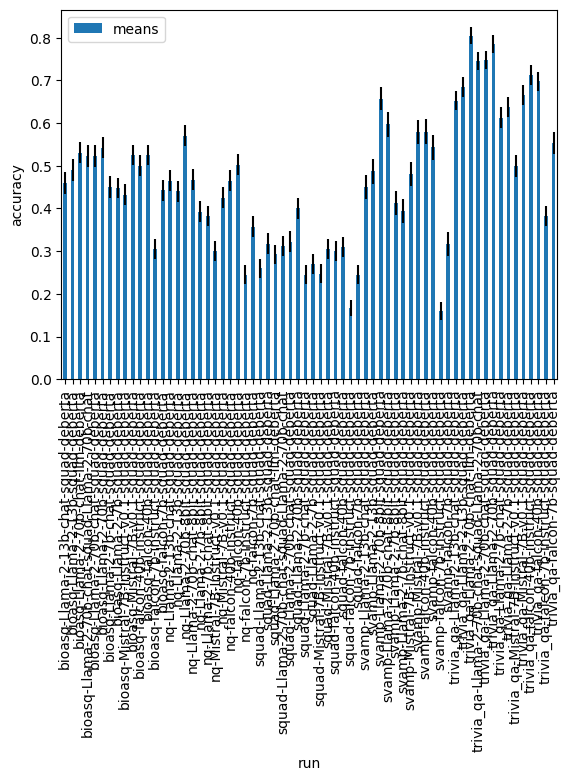

In [155]:
def get_perf_df(runs, all_results=all_results):
    perfdf = {}
    for wandb_id, run_name in runs.items():
        results = all_results[wandb_id]    
        perfdf[wandb_id] = get_perfs(results)
    
    runids = list(perfdf.keys())
    tmp = pd.DataFrame(perfdf[runids[0]])
    tmp['wandbid'] = runids[0]
    tmp['run'] = runs[runids[0]]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(perfdf[runid])
        tmp2['wandbid'] = runid
        tmp2['run'] = runs[runid]
        
        tmp = pd.concat([tmp, tmp2])
    
    perfdf = tmp.reset_index()
    
    tmp = perfdf.set_index('method').loc['accuracy']
    tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
    tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
    display(tmp.pivot(columns='model', index='dataset', values='means'))

    pdfs = {}
    for wandb_id in runs:
        results = all_results[wandb_id]
        pdfs[wandb_id] = get_uncertainty_df(results)
    
    runids = list(pdfs.keys())

    tmp = pd.DataFrame(pdfs[runids[0]])
    tmp['run'] = runs[runids[0]]
    tmp['wandbid'] = runids[0]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(pdfs[runid])
        tmp2['run'] = runs[runid]
        tmp2['wandbid'] = runid
    
        tmp = pd.concat([tmp, tmp2])
    
    all_runs = tmp.reset_index()

    return perfdf, pdfs, all_runs

perfdf, pdfs, all_runs = get_perf_df(runs)

perfdf = perfdf.merge(arg_df, on='wandbid')
all_runs = all_runs.merge(arg_df, on='wandbid')

plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run').sort_index())
plt.gca().set_ylabel('accuracy')

In [237]:
# load pik OOD runs

pik_runs = {'zb8q0s0c': 'falcon-7b-trivia_qa-squad',
 '1qwcqm89': 'falcon-7b-trivia_qa-nq',
 'v3npioit': 'falcon-7b-trivia_qa-bioasq',
 'mqn6lmow': 'falcon-7b-svamp-trivia_qa',
 'owrchir0': 'falcon-7b-instruct-trivia_qa-svamp',
 'xuz9nq8x': 'falcon-7b-instruct-trivia_qa-squad',
 'zjpeorle': 'falcon-7b-svamp-nq',
 'rbbmbltv': 'falcon-7b-instruct-nq-svamp',
 'l09gir6p': 'falcon-7b-instruct-trivia_qa-nq',
 'gcwvd0dc': 'falcon-7b-svamp-squad',
 'wuuz6tul': 'falcon-7b-instruct-nq-squad',
 'xeas4b1j': 'falcon-7b-instruct-trivia_qa-bioasq',
 'wy5d6wea': 'falcon-7b-svamp-bioasq',
 'radol9n5': 'falcon-7b-instruct-bioasq-trivia_qa',
 '6w9gpgau': 'falcon-7b-instruct-svamp-squad',
 'yynmhm18': 'falcon-7b-squad-trivia_qa',
 'ji5btg7g': 'Llama-2-13b-chat-trivia_qa-bioasq',
 'qqfan96l': 'Llama-2-13b-svamp-bioasq',
 '7378jty9': 'falcon-7b-instruct-nq-bioasq',
 'j9fc9xdf': 'falcon-7b-instruct-svamp-bioasq',
 '5fcv3979': 'falcon-7b-squad-nq',
 'fxzg4fk2': 'Llama-2-13b-chat-svamp-squad',
 '229zjxxc': 'falcon-7b-instruct-bioasq-svamp',
 '4zwjod47': 'Llama-2-13b-trivia_qa-bioasq',
 'hxmct0fe': 'falcon-7b-squad-svamp',
 'b0rvt1jh': 'falcon-7b-instruct-svamp-trivia_qa',
 'wyh7xixt': 'falcon-7b-bioasq-squad',
 'ums2ntcu': 'Llama-2-13b-chat-svamp-nq',
 'l1wz3yxp': 'Llama-2-13b-chat-bioasq-svamp',
 'zg7g48ls': 'Llama-2-13b-svamp-trivia_qa',
 'i548jgor': 'falcon-7b-squad-bioasq',
 'xjvkxyqy': 'falcon-7b-instruct-svamp-nq',
 'rqqbh2ss': 'Llama-2-13b-chat-squad-bioasq',
 'xp95pvun': 'Llama-2-13b-chat-squad-trivia_qa',
 'lb3zh6gw': 'Llama-2-13b-trivia_qa-squad',
 'r9983wt9': 'Llama-2-13b-nq-svamp',
 'lm9imw3o': 'falcon-7b-instruct-squad-svamp',
 'fixoh39l': 'falcon-7b-nq-svamp',
 'esnc5e6f': 'falcon-7b-instruct-bioasq-nq',
 'sxcthhax': 'Llama-2-13b-chat-nq-trivia_qa',
 'dpx5wbcn': 'Llama-2-13b-chat-bioasq-squad',
 'uvdx3ys5': 'Llama-2-13b-chat-svamp-bioasq',
 'q9dmcrp7': 'Llama-2-13b-chat-trivia_qa-squad',
 'g84aicza': 'Llama-2-13b-svamp-squad',
 'l28t9saq': 'Llama-2-13b-squad-svamp',
 'ka5zb0wu': 'falcon-7b-nq-trivia_qa',
 'qqt9dw5y': 'falcon-7b-instruct-squad-bioasq',
 'la8e8b4r': 'Llama-2-13b-chat-nq-svamp',
 'h05ct6vr': 'Llama-2-13b-chat-bioasq-trivia_qa',
 'x4ovchnl': 'Llama-2-13b-chat-trivia_qa-nq',
 'l129move': 'falcon-7b-trivia_qa-svamp',
 'uk9ybrid': 'Llama-2-13b-svamp-nq',
 '61pl4mms': 'Llama-2-13b-squad-nq',
 'qmcvz1jw': 'falcon-7b-bioasq-trivia_qa',
 'ryzg725a': 'falcon-7b-instruct-nq-trivia_qa',
 'wcdxfowp': 'Llama-2-13b-chat-nq-squad',
 'x8m438eg': 'Llama-2-13b-chat-trivia_qa-svamp',
 'm6zmm9kk': 'Llama-2-13b-chat-bioasq-nq',
 '4n73fv0z': 'Llama-2-13b-chat-squad-svamp',
 '7n8b8sve': 'Llama-2-13b-trivia_qa-nq',
 'q0shaobf': 'Llama-2-13b-squad-bioasq',
 '8f8gns4l': 'falcon-7b-nq-bioasq',
 '46bpgku5': 'falcon-7b-instruct-squad-trivia_qa',
 'o5qrab3i': 'Llama-2-13b-chat-nq-bioasq',
 'zv6h0ouo': 'falcon-7b-instruct-bioasq-squad',
 '9gyd2dfy': 'Llama-2-13b-bioasq-svamp',
 'kusm2lyi': 'Llama-2-13b-nq-squad',
 '2trt38y1': 'Llama-2-13b-bioasq-nq',
 '8tik0iin': 'Llama-2-13b-squad-trivia_qa',
 'ttdoaecq': 'Llama-2-13b-trivia_qa-svamp',
 'w7n1qvt4': 'falcon-7b-bioasq-svamp',
 '6pp8cozw': 'Llama-2-13b-chat-svamp-trivia_qa',
 'o6jjozep': 'falcon-7b-nq-squad',
 'g5svkp8m': 'Llama-2-13b-nq-trivia_qa',
 'tkeh0odg': 'falcon-7b-instruct-squad-nq',
 'ah9x0o7t': 'Llama-2-13b-chat-squad-nq',
 'uumqqy67': 'falcon-7b-bioasq-nq',
 'gqczft8f': 'Llama-2-13b-bioasq-squad',
 'fa2eyiej': 'Llama-2-13b-nq-bioasq',
 '460cju5m': 'Llama-2-13b-bioasq-trivia_qa',
 'ikwfpzoc': 'falcon-40b-squad-svamp',
 '67uqfyxk': 'falcon-40b-svamp-bioasq',
 'adc027lq': 'falcon-40b-trivia_qa-nq',
 'lewbkjkg': 'falcon-40b-squad-trivia_qa',
 'cw6kqha3': 'falcon-40b-trivia_qa-squad',
 'r7axsfb3': 'falcon-40b-bioasq-squad',
 '6rs17zuc': 'falcon-40b-trivia_qa-bioasq',
 's41tlp36': 'falcon-40b-squad-nq',
 'h91ugjiy': 'falcon-40b-svamp-squad',
 '2i3uvgs1': 'falcon-40b-svamp-nq',
 'bsmrqkco': 'Mistral-7B-Instruct-v0.1-squad-svamp',
 'w9mwtgs7': 'falcon-40b-svamp-trivia_qa',
 'nc8zrjcg': 'Llama-2-7b-chat-nq-svamp',
 'eeihi80z': 'Mistral-7B-Instruct-v0.1-squad-nq',
 '12mnpwz8': 'Llama-2-7b-chat-nq-squad',
 'zk1xyboc': 'Mistral-7B-Instruct-v0.1-nq-trivia_qa',
 'i67yzkmy': 'falcon-40b-nq-squad',
 'kw5zz6ee': 'Llama-2-7b-chat-nq-bioasq',
 'c3d2mmbg': 'Mistral-7B-Instruct-v0.1-squad-bioasq',
 'pr30kt3y': 'Llama-2-7b-chat-bioasq-trivia_qa',
 'dxfoej4h': 'Mistral-7B-v0.1-svamp-nq',
 'wknitcz1': 'Mistral-7B-Instruct-v0.1-nq-svamp',
 'sdldkm3c': 'falcon-40b-squad-bioasq',
 'evq1mj8k': 'Llama-2-7b-chat-bioasq-squad',
 '7bcwvmdw': 'Mistral-7B-v0.1-squad-trivia_qa',
 'yqipgbvd': 'Mistral-7B-Instruct-v0.1-nq-squad',
 'cuf7ayir': 'Llama-2-7b-chat-bioasq-svamp',
 'wpmptujj': 'falcon-40b-nq-bioasq',
 'da9jibfp': 'Mistral-7B-v0.1-nq-trivia_qa',
 '59uto4ah': 'Mistral-7B-Instruct-v0.1-nq-bioasq',
 'r2an27y9': 'Llama-2-7b-trivia_qa-squad',
 'h84txo0f': 'falcon-40b-nq-trivia_qa',
 'e6zjq4ay': 'Mistral-7B-v0.1-svamp-squad',
 'ghkm945m': 'Mistral-7B-Instruct-v0.1-bioasq-trivia_qa',
 'jl13tsh1': 'Llama-2-7b-trivia_qa-nq',
 'd1khmq82': 'falcon-40b-instruct-svamp-trivia_qa',
 'oqdkraq4': 'Mistral-7B-v0.1-squad-svamp',
 '30oefpf0': 'Mistral-7B-v0.1-bioasq-nq',
 'gvyb73tn': 'Llama-2-7b-chat-bioasq-nq',
 'f9o9u04c': 'Mistral-7B-Instruct-v0.1-bioasq-nq',
 'ee7kgeuv': 'falcon-40b-instruct-svamp-nq',
 'c57adpi0': 'falcon-40b-bioasq-svamp',
 'qcd47hro': 'Mistral-7B-v0.1-svamp-bioasq',
 'bg6igf6g': 'Mistral-7B-Instruct-v0.1-bioasq-svamp',
 'l3fsb40t': 'Llama-2-7b-trivia_qa-svamp',
 '2r8opy8u': 'falcon-40b-instruct-svamp-bioasq',
 'ob8ivht9': 'Mistral-7B-Instruct-v0.1-trivia_qa-squad',
 'dns2yp69': 'falcon-40b-instruct-squad-trivia_qa',
 '06mfjmri': 'Mistral-7B-Instruct-v0.1-bioasq-squad',
 'dpo0pkhf': 'Llama-2-7b-trivia_qa-bioasq',
 'qwx71f2t': 'falcon-40b-bioasq-trivia_qa',
 'j1pmqjpr': 'Mistral-7B-v0.1-nq-svamp',
 '8exblmo5': 'Llama-2-7b-chat-trivia_qa-nq',
 'a6dfqkft': 'Llama-2-7b-svamp-trivia_qa',
 'm7iuuyo5': 'falcon-40b-instruct-svamp-squad',
 'uesmh4bm': 'Mistral-7B-Instruct-v0.1-svamp-squad',
 'dgxw4z5b': 'Llama-2-7b-chat-trivia_qa-svamp',
 '4q4dga5k': 'Llama-2-7b-squad-trivia_qa',
 'gej7tg1t': 'falcon-40b-instruct-squad-svamp',
 'lai13dwv': 'falcon-40b-nq-svamp',
 'jqifb3yk': 'Mistral-7B-v0.1-nq-squad',
 'ezic1hj8': 'falcon-40b-trivia_qa-svamp',
 '80x6csf6': 'Llama-2-7b-chat-trivia_qa-squad',
 '75q4nqxs': 'Mistral-7B-Instruct-v0.1-svamp-trivia_qa',
 '759jwipi': 'Llama-2-7b-svamp-squad',
 'e63muwy4': 'falcon-40b-instruct-squad-bioasq',
 'wkhfljbd': 'Llama-2-70b-trivia_qa-squad',
 'tab484s6': 'Mistral-7B-v0.1-trivia_qa-svamp',
 'hozenkgk': 'Mistral-7B-v0.1-squad-bioasq',
 'vnf2sc3s': 'Llama-2-7b-svamp-bioasq',
 'hy0qibkq': 'Llama-2-7b-chat-trivia_qa-bioasq',
 '0o7wmmkq': 'falcon-40b-instruct-squad-nq',
 '17swb2xj': 'Llama-2-70b-svamp-nq',
 'twoavvoo': 'Mistral-7B-Instruct-v0.1-trivia_qa-svamp',
 'wct72ma3': 'falcon-40b-bioasq-nq',
 'uysvmfjm': 'Llama-2-7b-chat-svamp-squad',
 'hg82jwhu': 'Llama-2-7b-svamp-nq',
 'c2hjkv6e': 'falcon-40b-instruct-trivia_qa-svamp',
 'zxm9p0qo': 'falcon-40b-instruct-nq-svamp',
 'swohl40n': 'Llama-2-70b-chat-trivia_qa-bioasq',
 'skvs09s3': 'Mistral-7B-v0.1-squad-nq',
 'zisdtzit': 'falcon-40b-instruct-trivia_qa-squad',
 '56lfuoky': 'Llama-2-70b-trivia_qa-svamp',
 'y66z6luq': 'falcon-40b-instruct-trivia_qa-bioasq',
 'khwwihpx': 'falcon-40b-instruct-trivia_qa-nq',
 'tuqu5dl6': 'Llama-2-7b-chat-svamp-trivia_qa',
 'falh33vx': 'Llama-2-7b-squad-svamp',
 'cumoc0vv': 'falcon-40b-instruct-bioasq-svamp',
 'sumw8dwd': 'Mistral-7B-Instruct-v0.1-squad-trivia_qa',
 'd68h6agu': 'Llama-2-70b-chat-trivia_qa-squad',
 'jyjfosmm': 'Mistral-7B-v0.1-svamp-trivia_qa',
 '2qxni4nh': 'Llama-2-70b-nq-trivia_qa',
 'jozhpamu': 'Llama-2-70b-chat-nq-svamp',
 '92ejd6nh': 'Llama-2-70b-svamp-bioasq',
 'rfp85gk2': 'Llama-2-70b-chat-svamp-squad',
 'ftuxirff': 'Llama-2-7b-chat-svamp-nq',
 'ksmhy9nr': 'Llama-2-7b-squad-nq',
 'e6mno259': 'falcon-40b-instruct-bioasq-trivia_qa',
 'poau7tcc': 'Mistral-7B-v0.1-bioasq-trivia_qa',
 'pt9mzzji': 'Llama-2-70b-chat-svamp-trivia_qa',
 'sn4bkn3s': 'Llama-2-70b-chat-nq-squad',
 'bfve0aec': 'Llama-2-70b-chat-squad-bioasq',
 '3bktgmou': 'Mistral-7B-Instruct-v0.1-trivia_qa-nq',
 'jxr2qnti': 'Llama-2-7b-chat-squad-svamp',
 'f39sd8zq': 'Llama-2-7b-nq-trivia_qa',
 'r78cxilh': 'Llama-2-70b-squad-svamp',
 'ljnnrijc': 'Llama-2-70b-chat-bioasq-nq',
 'ocdpmx4z': 'falcon-40b-instruct-nq-bioasq',
 'lynigngm': 'Mistral-7B-v0.1-trivia_qa-nq',
 '3o1nhi7p': 'Llama-2-70b-chat-trivia_qa-svamp',
 '865pa5pf': 'Llama-2-70b-chat-bioasq-trivia_qa',
 'tozk0ogw': 'Llama-2-70b-chat-squad-nq',
 '5bws9lhs': 'Mistral-7B-v0.1-bioasq-svamp',
 'tuhqorgy': 'Llama-2-7b-chat-svamp-bioasq',
 '0y2xpvds': 'Llama-2-7b-nq-svamp',
 'pdvb3n5s': 'falcon-40b-instruct-nq-trivia_qa',
 't9a2cvr9': 'Llama-2-70b-trivia_qa-nq',
 'dypb2tbm': 'Llama-2-70b-squad-nq',
 '11hs5znn': 'Mistral-7B-Instruct-v0.1-svamp-nq',
 'yk7hp2vq': 'Llama-2-70b-chat-trivia_qa-nq',
 'vdps77ty': 'Llama-2-70b-chat-nq-bioasq',
 '3r8bu3yu': 'Llama-2-70b-chat-svamp-bioasq',
 'qajtb2ya': 'Llama-2-7b-chat-squad-trivia_qa',
 '9rugl6ug': 'Mistral-7B-v0.1-trivia_qa-squad',
 'k0zvkdlj': 'Llama-2-7b-squad-bioasq',
 'l5gzq11e': 'falcon-40b-instruct-nq-squad',
 'tlijr7ws': 'Llama-2-70b-trivia_qa-bioasq',
 'lb1528ja': 'Mistral-7B-v0.1-bioasq-squad',
 'yuhssgkm': 'Llama-2-70b-squad-bioasq',
 'nc9y07he': 'Llama-2-7b-bioasq-squad',
 'h1vr1fuo': 'Llama-2-70b-chat-bioasq-squad',
 '4jwxt1a3': 'Llama-2-70b-chat-squad-trivia_qa',
 's2m61qg6': 'Llama-2-7b-chat-squad-nq',
 '2qcxhn2q': 'Llama-2-7b-nq-squad',
 'aivfva3n': 'falcon-40b-instruct-bioasq-squad',
 '6ofo9dav': 'Llama-2-70b-svamp-squad',
 'vwbiwmlq': 'Mistral-7B-Instruct-v0.1-trivia_qa-bioasq',
 '9u7poqfl': 'Mistral-7B-v0.1-trivia_qa-bioasq',
 '9g2o0a3h': 'Llama-2-7b-bioasq-nq',
 'owej1bby': 'Llama-2-70b-nq-svamp',
 '2zaiamr4': 'Llama-2-70b-chat-bioasq-svamp',
 '1b3jcrdd': 'Llama-2-70b-chat-squad-svamp',
 'sybosmim': 'Llama-2-7b-chat-nq-trivia_qa',
 'p7s31p4x': 'Llama-2-7b-nq-bioasq',
 'h3czy7np': 'falcon-40b-instruct-bioasq-nq',
 'durcrmtv': 'Mistral-7B-v0.1-nq-bioasq',
 '36014q2k': 'Llama-2-70b-bioasq-trivia_qa',
 'nmstkiq7': 'Llama-2-70b-nq-squad',
 '0h98jth6': 'Llama-2-70b-bioasq-nq',
 'w3kd5z7z': 'Llama-2-70b-squad-trivia_qa',
 'drfgz68g': 'Llama-2-70b-svamp-trivia_qa',
 '5k2cvrsq': 'Llama-2-7b-bioasq-svamp',
 'n7kibx9n': 'Llama-2-70b-chat-nq-trivia_qa',
 'z5dozpuy': 'Llama-2-70b-chat-svamp-nq',
 '2ljsyp15': 'Mistral-7B-Instruct-v0.1-svamp-bioasq',
 'gbocy33g': 'Llama-2-7b-chat-squad-bioasq',
 'fjjk7jjz': 'Llama-2-7b-bioasq-trivia_qa',
 'wfdivgg4': 'Llama-2-70b-nq-bioasq',
 'zwsbv6iv': 'Llama-2-70b-bioasq-svamp',
 '9rvayd6j': 'Llama-2-70b-bioasq-squad'}

# pik_results = {}
for wandb_id in pik_runs:
    print(wandb_id, list(pik_runs.keys()).index(wandb_id), len(pik_runs))
    if wandb_id not in pik_results:
        pik_results[wandb_id], _ = restore_file(wandb_id)


import pickle
with open('/scratch-ssd/jansen/semantic_uncertainty/pik_ood_short.pkl', 'wb') as f:
    pickle.dump([pik_runs, pik_results], f)

# with open('/scratch-ssd/jansen/semantic_uncertainty/pik_ood_short.pkl', 'rb') as f:
#     pik_runs, pik_results = pickle.load(f)


zb8q0s0c 0 240
1qwcqm89 1 240
v3npioit 2 240
mqn6lmow 3 240
owrchir0 4 240
xuz9nq8x 5 240
zjpeorle 6 240
rbbmbltv 7 240
l09gir6p 8 240
gcwvd0dc 9 240
wuuz6tul 10 240
xeas4b1j 11 240
wy5d6wea 12 240
radol9n5 13 240
6w9gpgau 14 240
yynmhm18 15 240
ji5btg7g 16 240
qqfan96l 17 240
7378jty9 18 240
j9fc9xdf 19 240
5fcv3979 20 240
fxzg4fk2 21 240
229zjxxc 22 240
4zwjod47 23 240
hxmct0fe 24 240
b0rvt1jh 25 240
wyh7xixt 26 240
ums2ntcu 27 240
l1wz3yxp 28 240
zg7g48ls 29 240
i548jgor 30 240
xjvkxyqy 31 240
rqqbh2ss 32 240
xp95pvun 33 240
lb3zh6gw 34 240
r9983wt9 35 240
lm9imw3o 36 240
fixoh39l 37 240
esnc5e6f 38 240
sxcthhax 39 240
dpx5wbcn 40 240
uvdx3ys5 41 240
q9dmcrp7 42 240
g84aicza 43 240
l28t9saq 44 240
ka5zb0wu 45 240
qqt9dw5y 46 240
la8e8b4r 47 240
h05ct6vr 48 240
x4ovchnl 49 240
l129move 50 240
uk9ybrid 51 240
61pl4mms 52 240
qmcvz1jw 53 240
ryzg725a 54 240
wcdxfowp 55 240
x8m438eg 56 240
m6zmm9kk 57 240
4n73fv0z 58 240
7n8b8sve 59 240
q0shaobf 60 240
8f8gns4l 61 240
46bpgku5 62 240
o5

In [239]:
pik_perfdf, pik_pdfs, pik_all_runs = get_perf_df(pik_runs, all_results=pik_results)
pik_all_runs['c.dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[-2])
pik_all_runs['c.ood_dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[-1])
pik_all_runs['c.model_name'] = pik_all_runs.run.map(lambda x: '-'.join(x.split('-')[:-2]))
pik_all_runs = pik_all_runs.set_index('method').loc['p_ik'].reset_index()
pik_all_runs['method_real'] = pik_all_runs['method'] + ' ' + pik_all_runs['c.ood_dataset']
pik_all_runs['method'] = 'p_ik_ood'


model,Llama,Mistral,falcon
dataset,,,
2-13b-bioasq-nq,0.49,NaN,NaN
2-13b-bioasq-squad,0.49,NaN,NaN
2-13b-bioasq-svamp,0.49,NaN,NaN
2-13b-bioasq-trivia_qa,0.49,NaN,NaN
2-13b-chat-bioasq-nq,0.46,NaN,NaN
...,...,...,...
7b-svamp-trivia_qa,NaN,NaN,0.316667
7b-trivia_qa-bioasq,NaN,NaN,0.552500
7b-trivia_qa-nq,NaN,NaN,0.552500


In [266]:
# for name, tmp in pik_all_runs.groupby(merge):
#     assert len(tmp) == 4
# display(tmp)

merge = ['metric', 'c.dataset', 'c.model_name']
tmp = pik_all_runs.groupby(merge).mean('hack').reset_index()
pik_all_runs_averaged = tmp.merge(pik_all_runs[merge + ['base_method', 'run', 'wandb_id']], on=merge)

In [267]:
tmp

,metric,c.dataset,c.model_name,means,low,high
0,AUROC,bioasq,Llama-2-13b,0.488783,0.460915,0.516651
1,AUROC,bioasq,Llama-2-13b-chat,0.612684,0.586520,0.638847
2,AUROC,bioasq,Llama-2-70b,0.579644,0.552057,0.607231
3,AUROC,bioasq,Llama-2-70b-chat,0.511085,0.483061,0.539109
4,AUROC,bioasq,Llama-2-7b,0.650971,0.623941,0.678000
...,...,...,...,...,...,...
415,mean_uncertainty,trivia_qa,Mistral-7B-v0.1,0.466540,0.449280,0.483800
416,mean_uncertainty,trivia_qa,falcon-40b,0.843906,0.832012,0.855800
417,mean_uncertainty,trivia_qa,falcon-40b-instruct,0.826828,0.815948,0.837708
418,mean_uncertainty,trivia_qa,falcon-7b,0.770641,0.756953,0.784329


/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


Text(0, 0.5, 'accuracy')

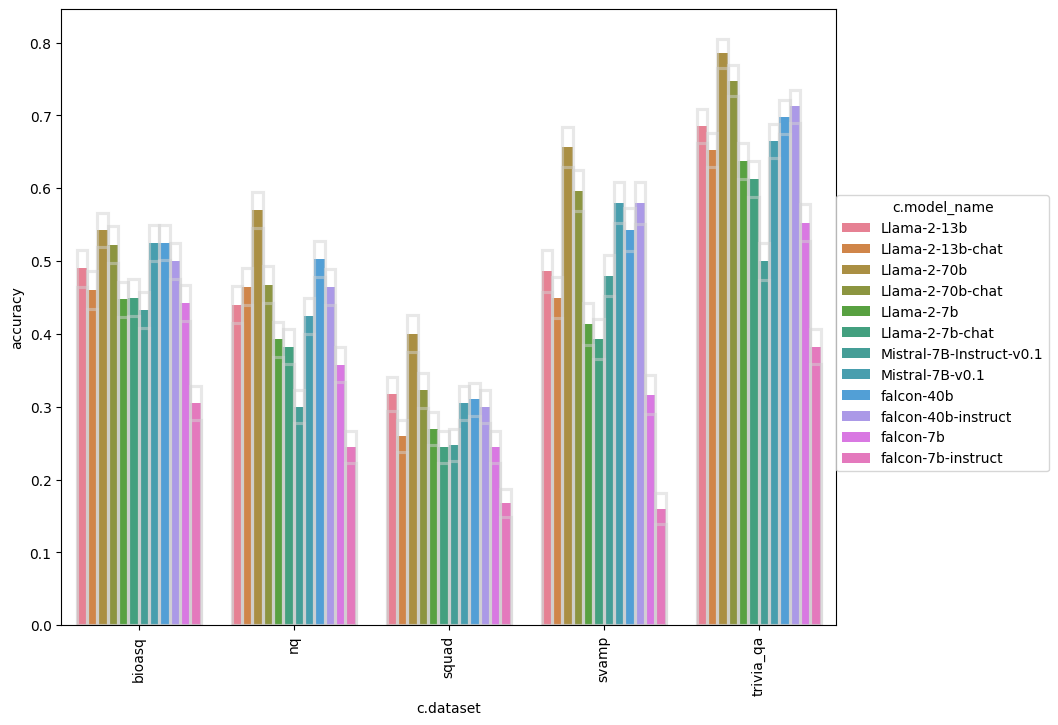

In [156]:
# just select the base entailment_model and metric, and ignore 'max_from' accuracies
acc = 'accuracy'
plot_grouped(perfdf.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad'].set_index('method').loc[acc], metric='means', x='c.dataset', hue='c.model_name')
plt.gca().set_ylabel(acc)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


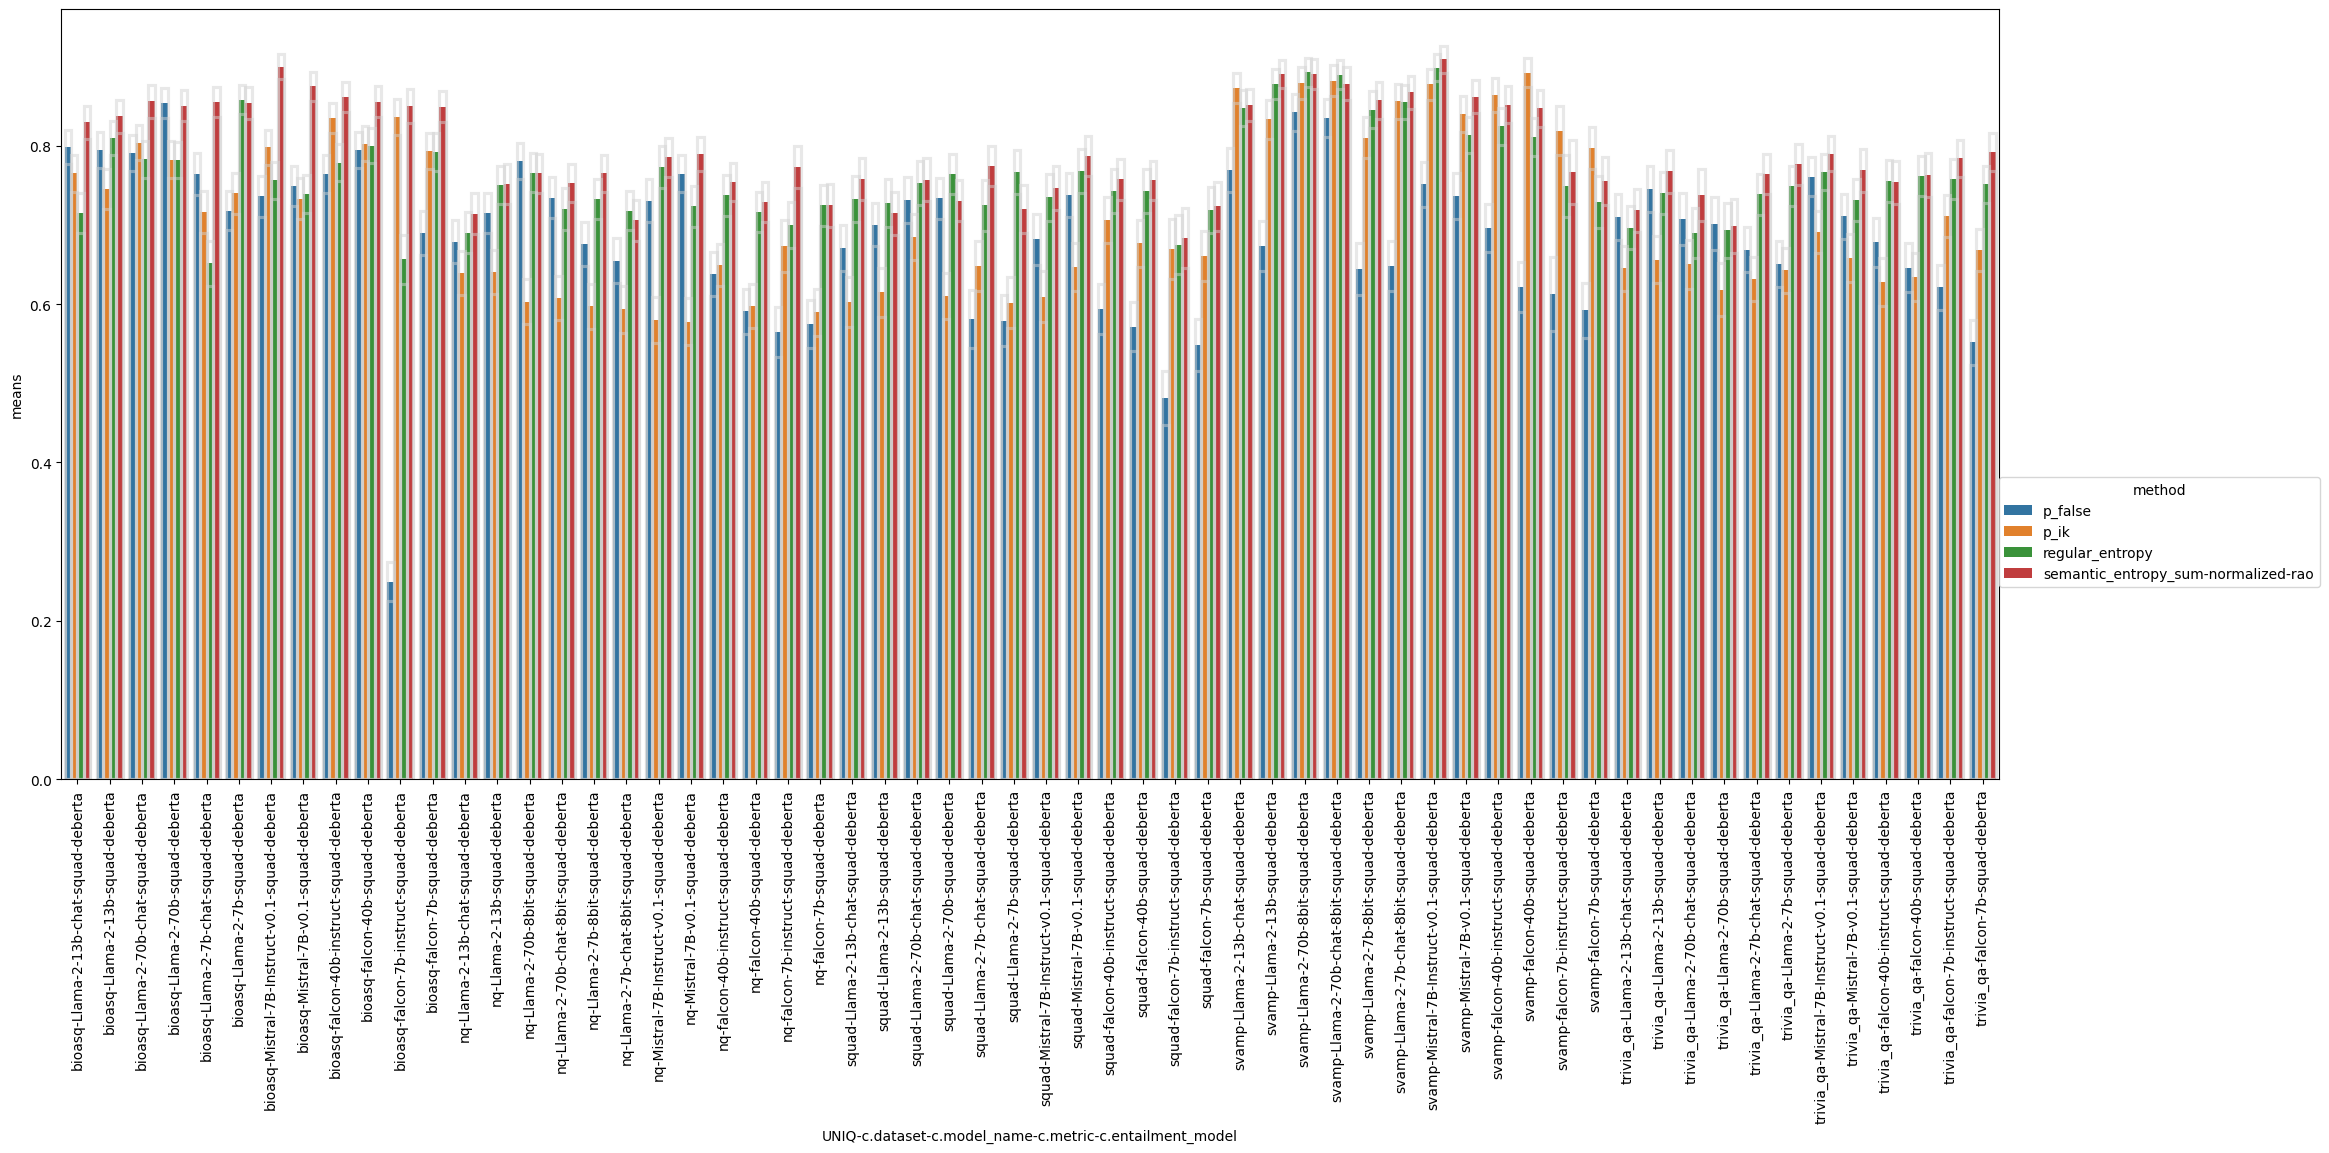

In [157]:

# main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']# , 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']
main_methods = ['regular_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']# , 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']

plot_grouped(
    all_runs.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad'].set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
    metric='means', x=uniq_name, hue='method',
    figsize=(25, 10)
)

plot the same, but per dataset

(actually, semantic entropy (and variants), are not that bad overall, especially once you start taking smaller models into account (where e.g. p_false oftens sucks))

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

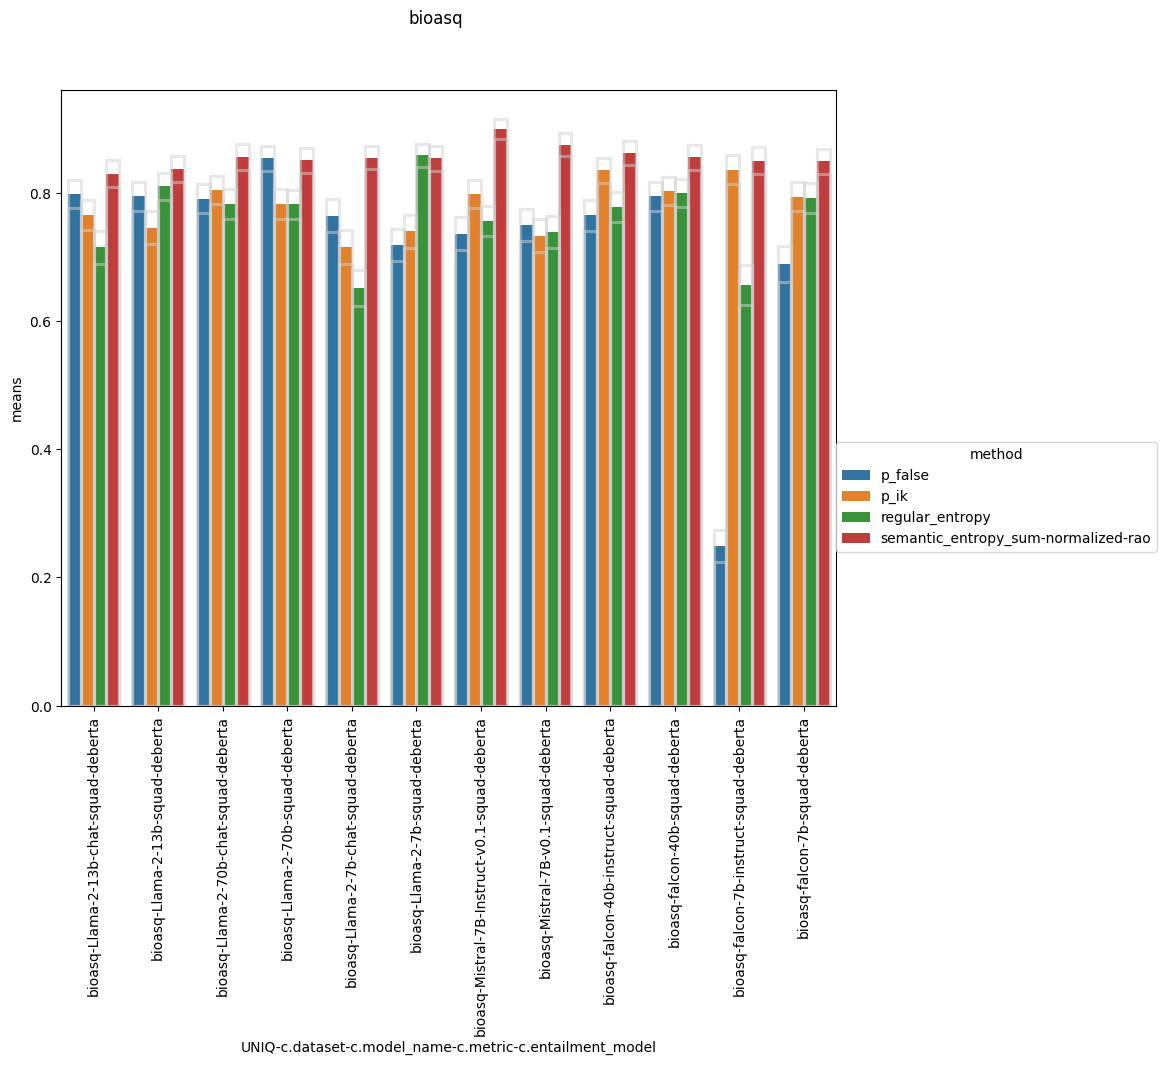

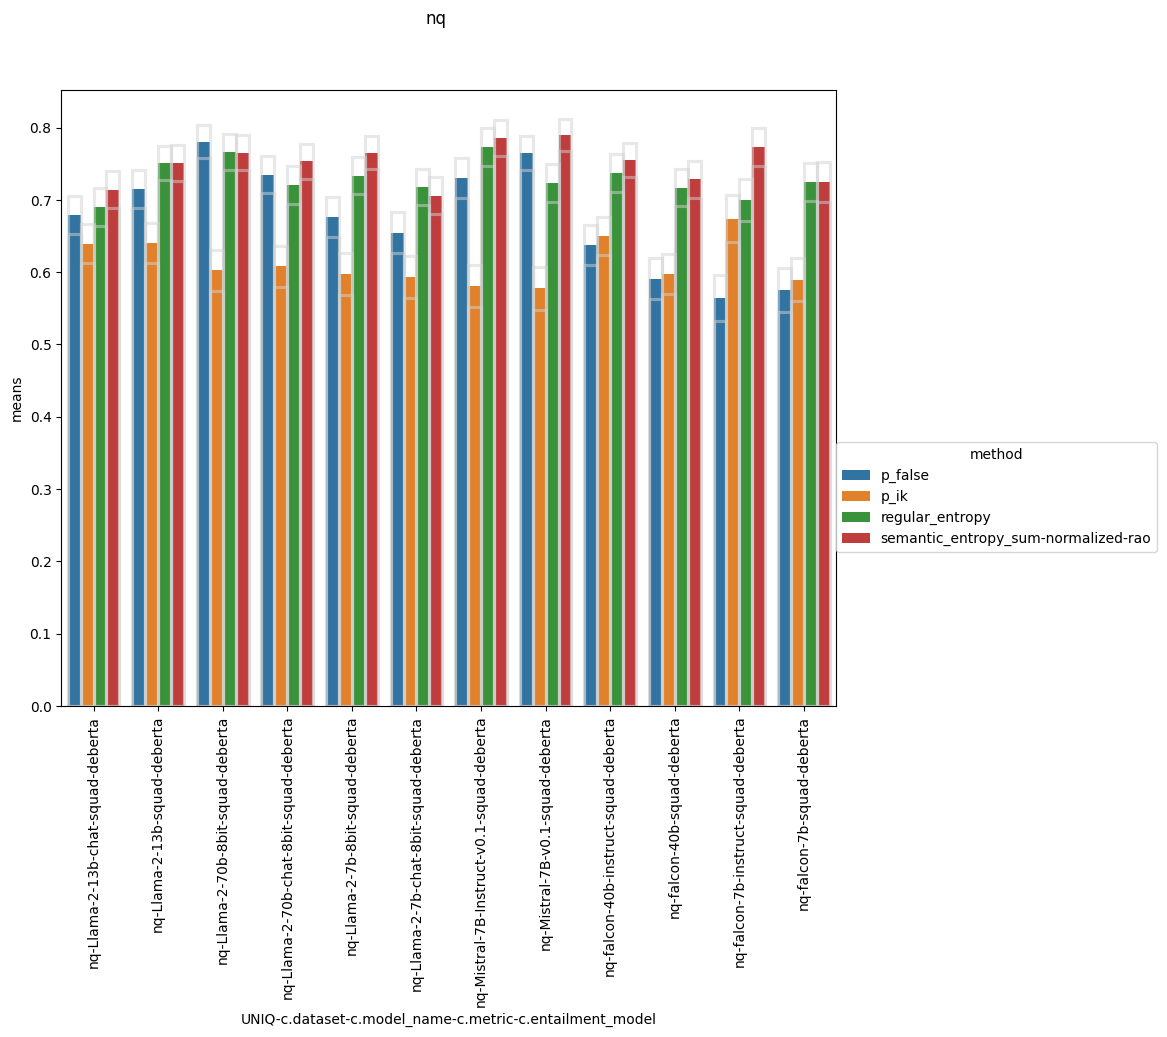

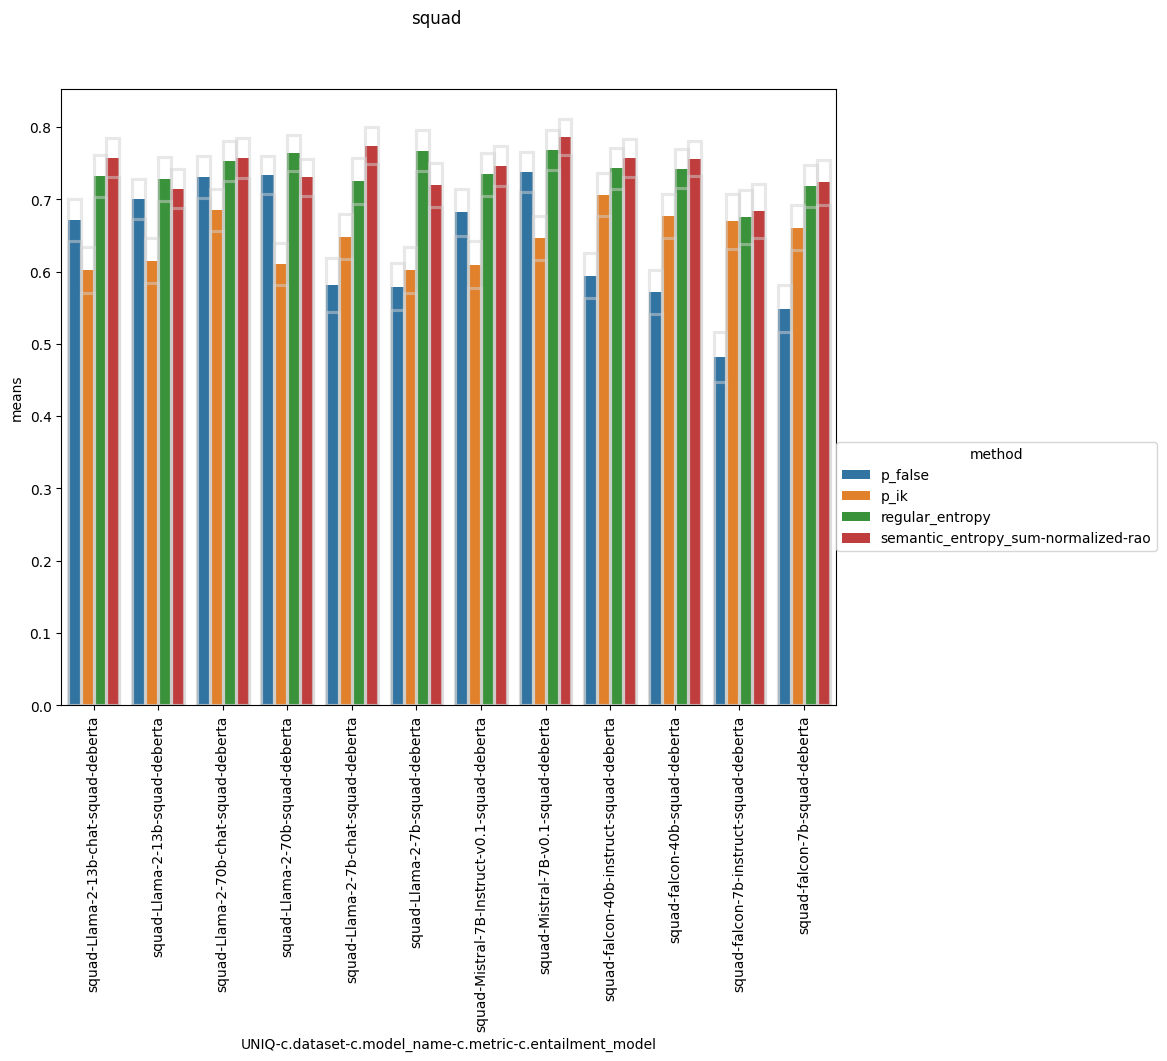

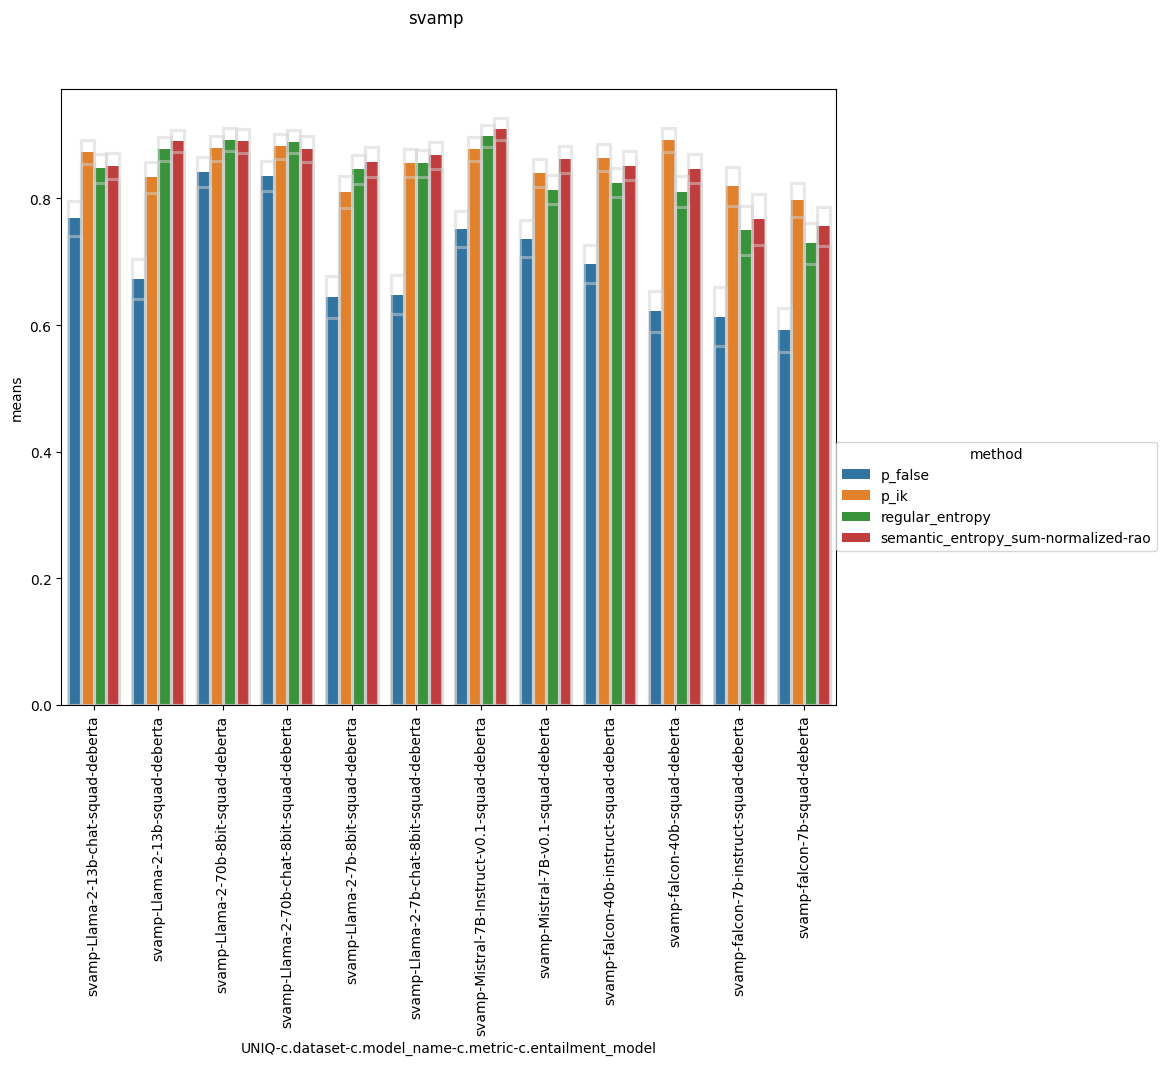

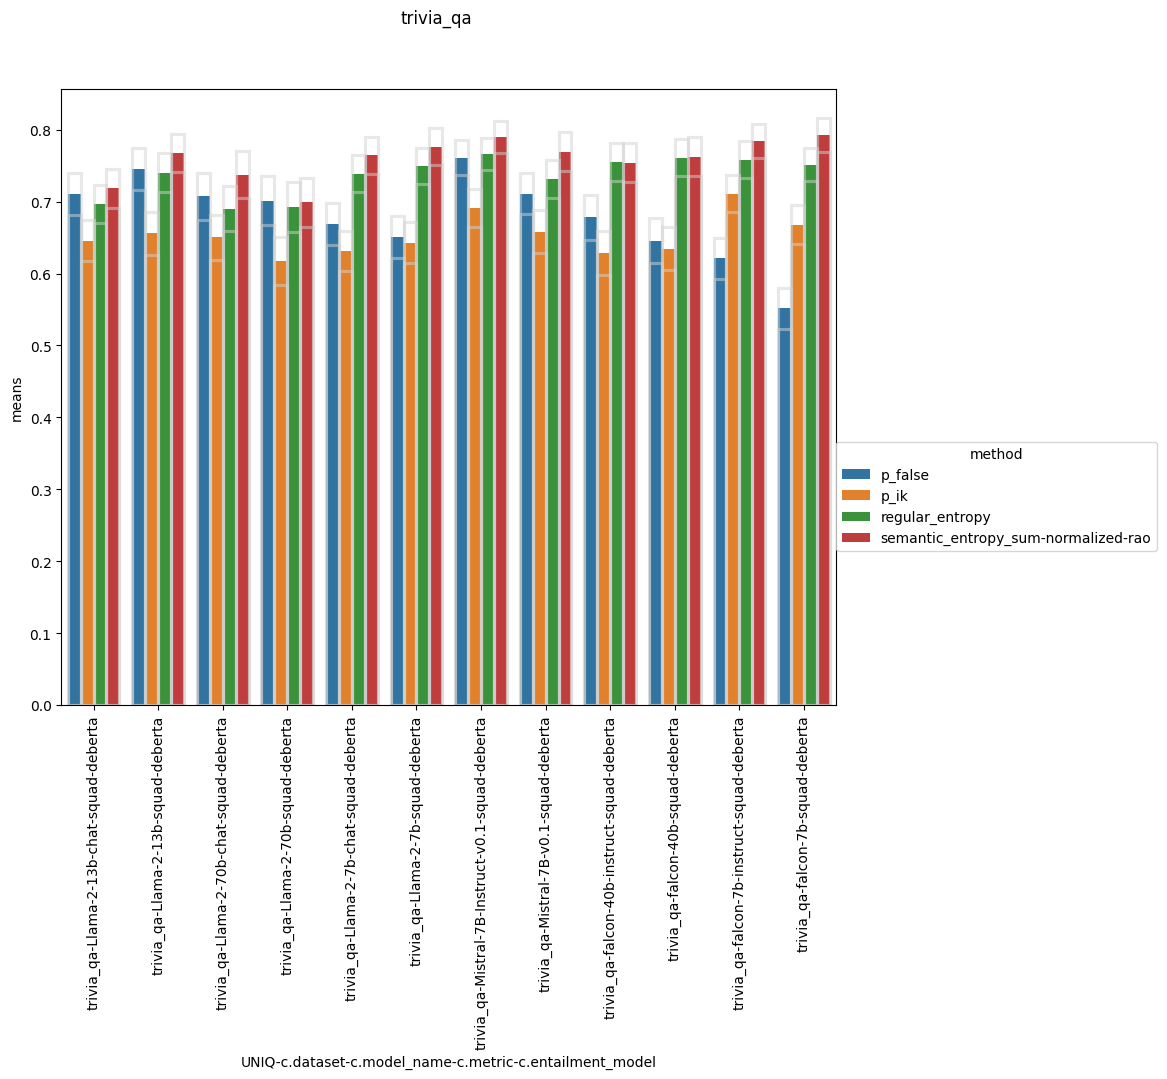

In [158]:
for dataset, gdf in all_runs.groupby('c.dataset'):

    plot_grouped(
        gdf.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad'].set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
        metric='means', x=uniq_name, hue='method',
    )
    plt.gcf().suptitle(dataset)

['regular_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)


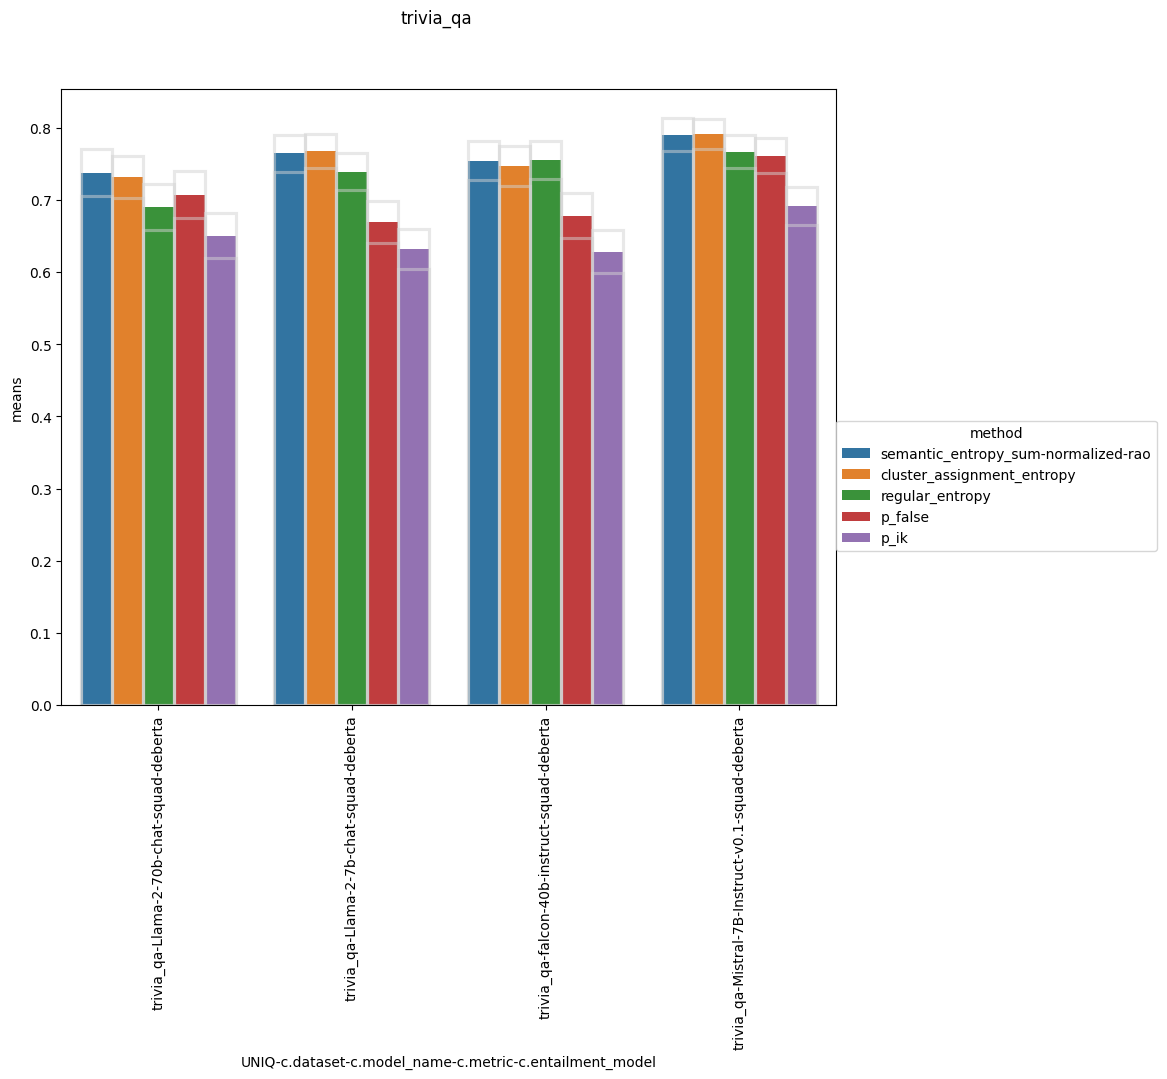

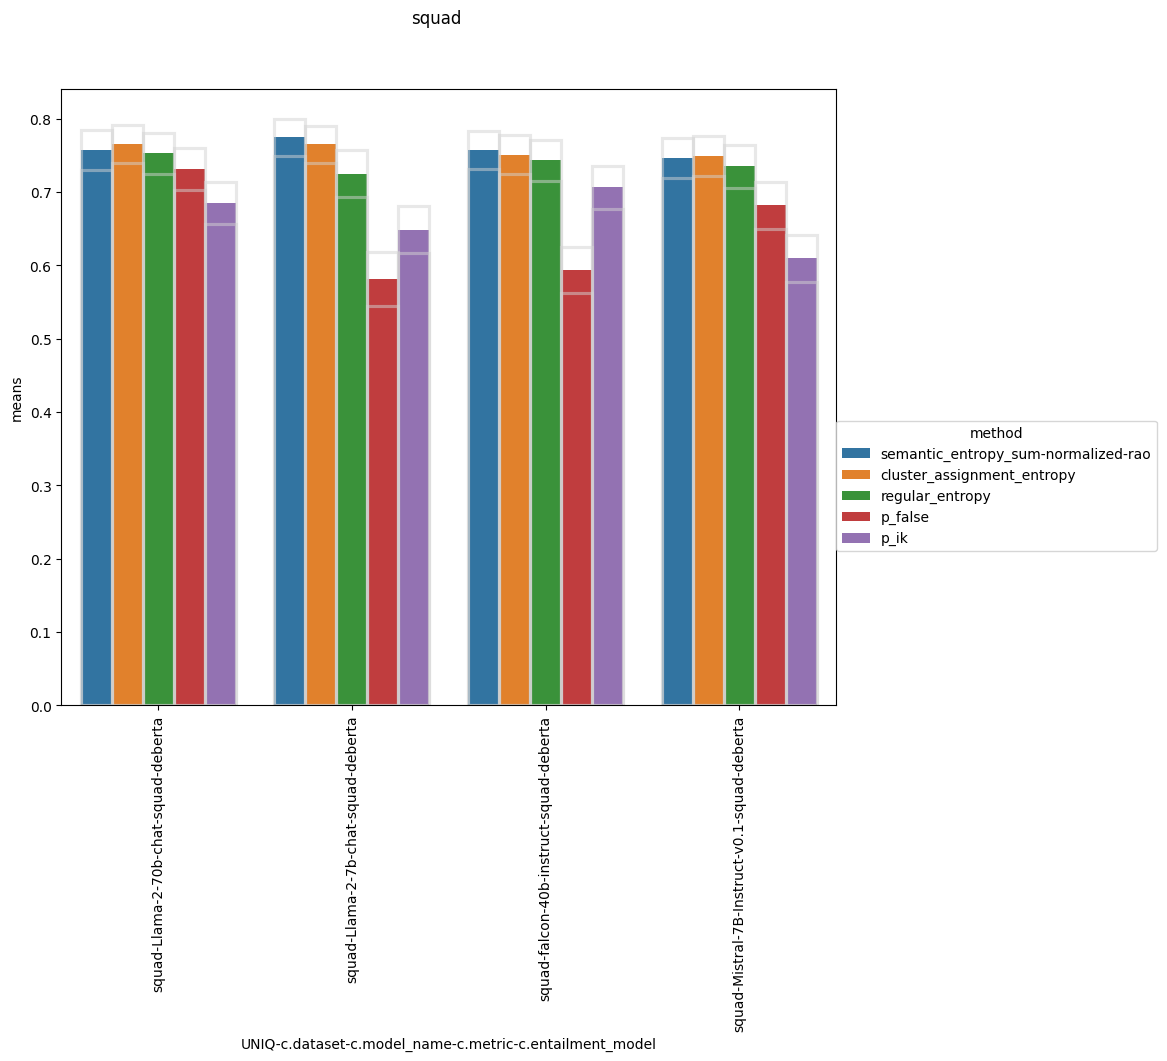

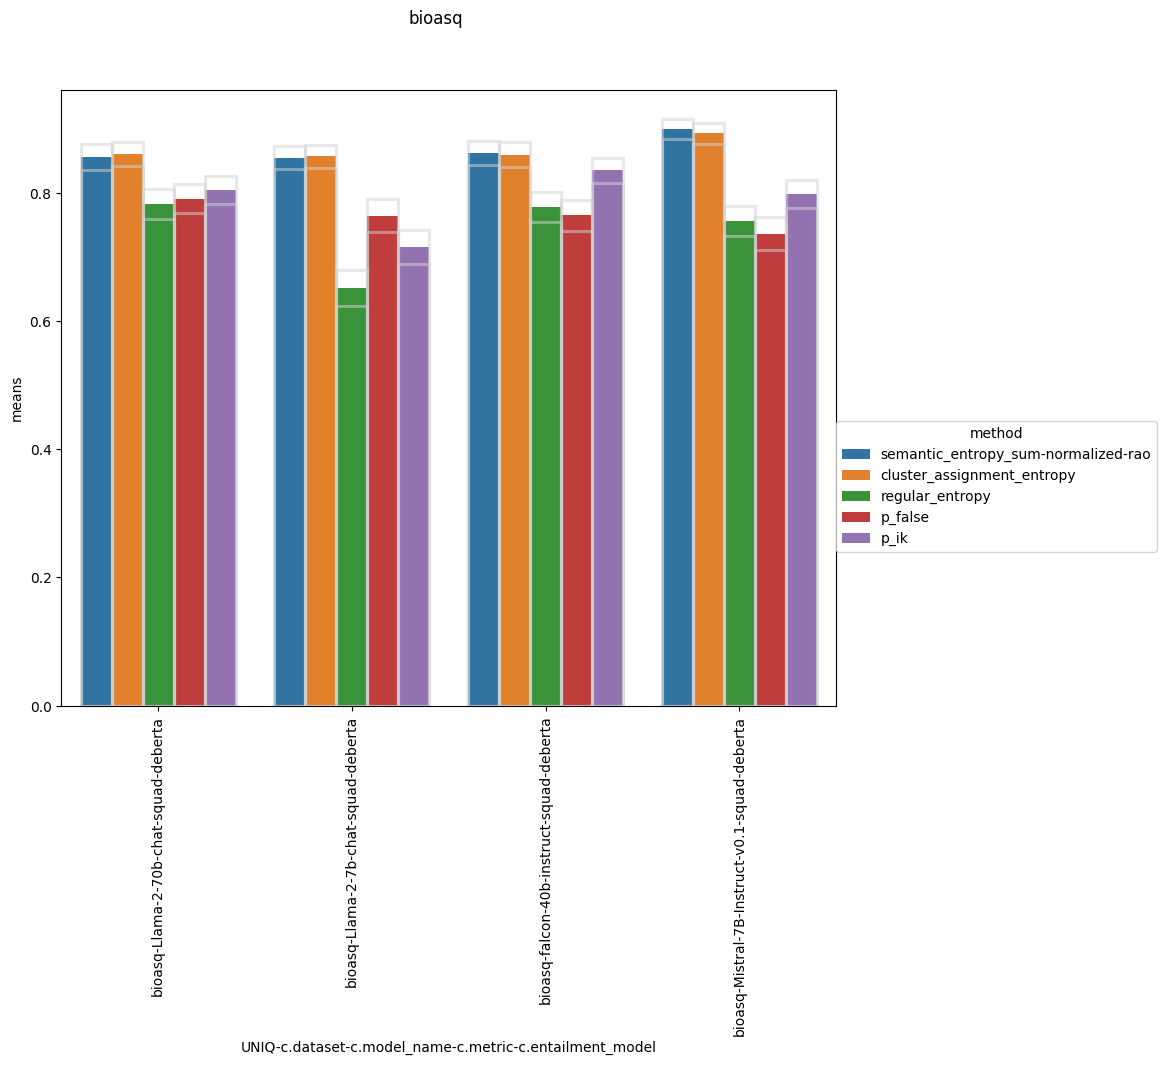

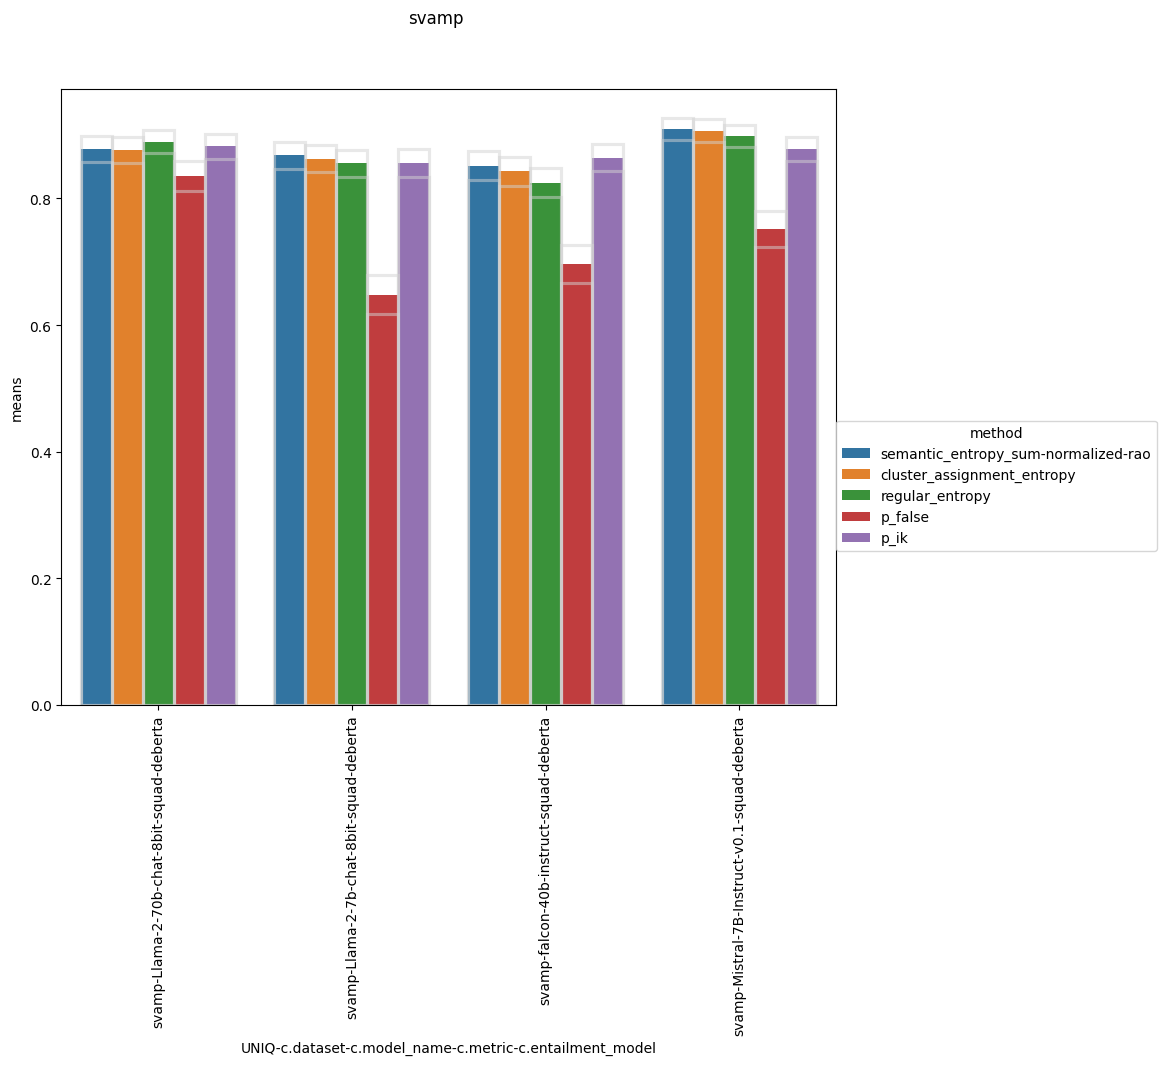

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

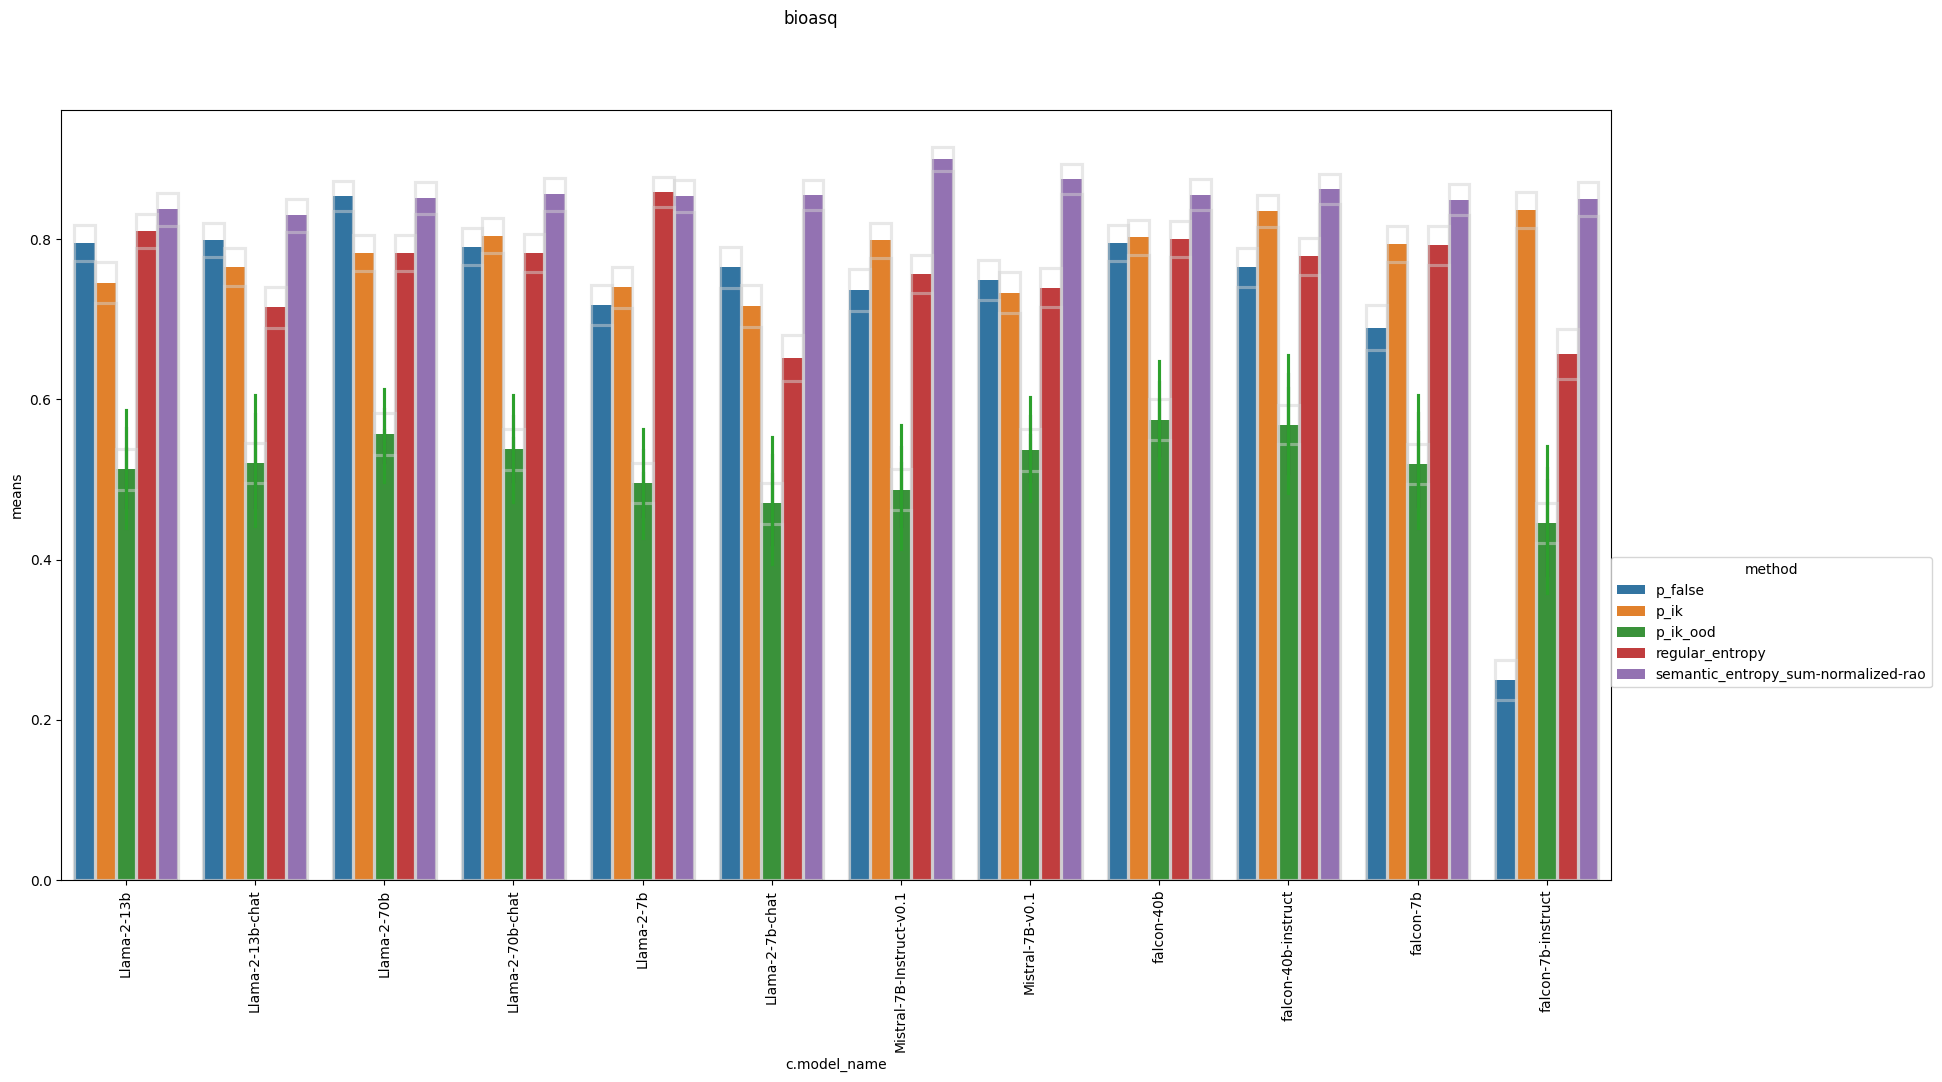

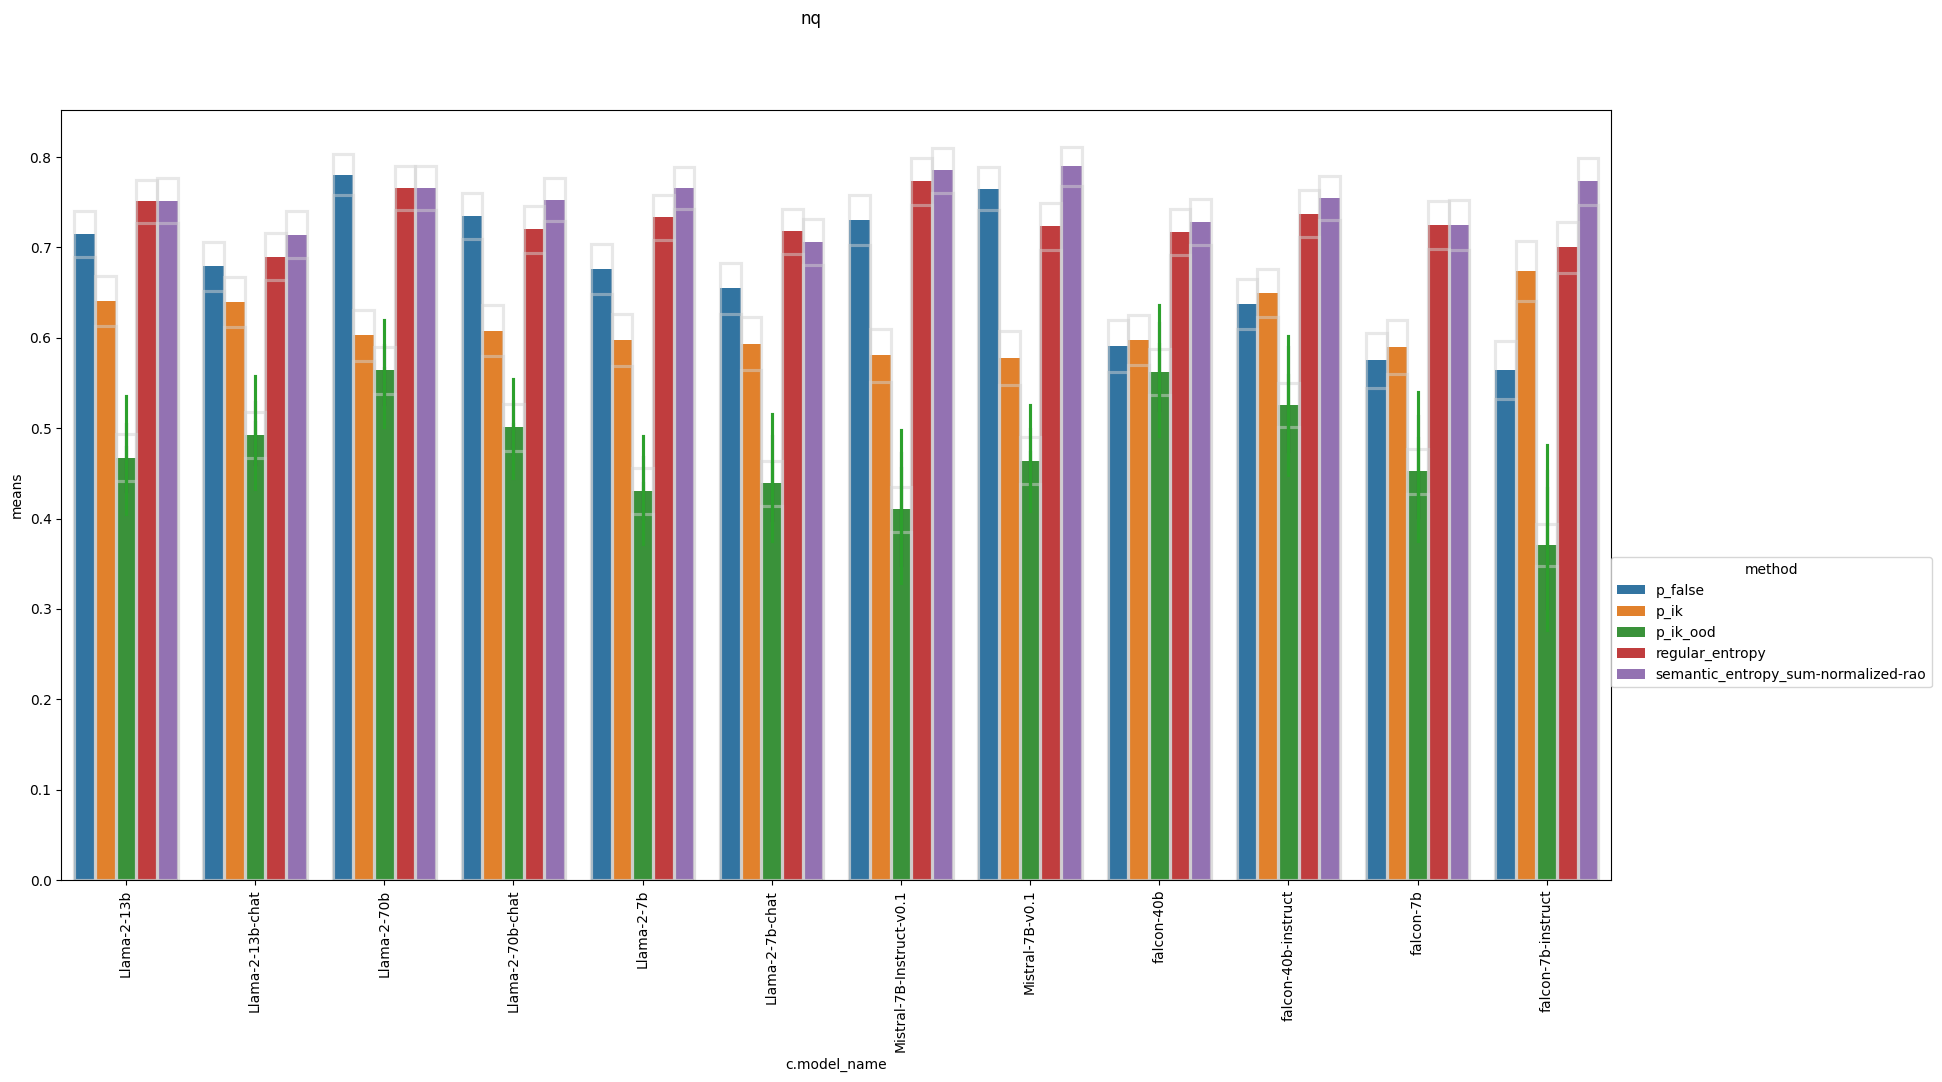

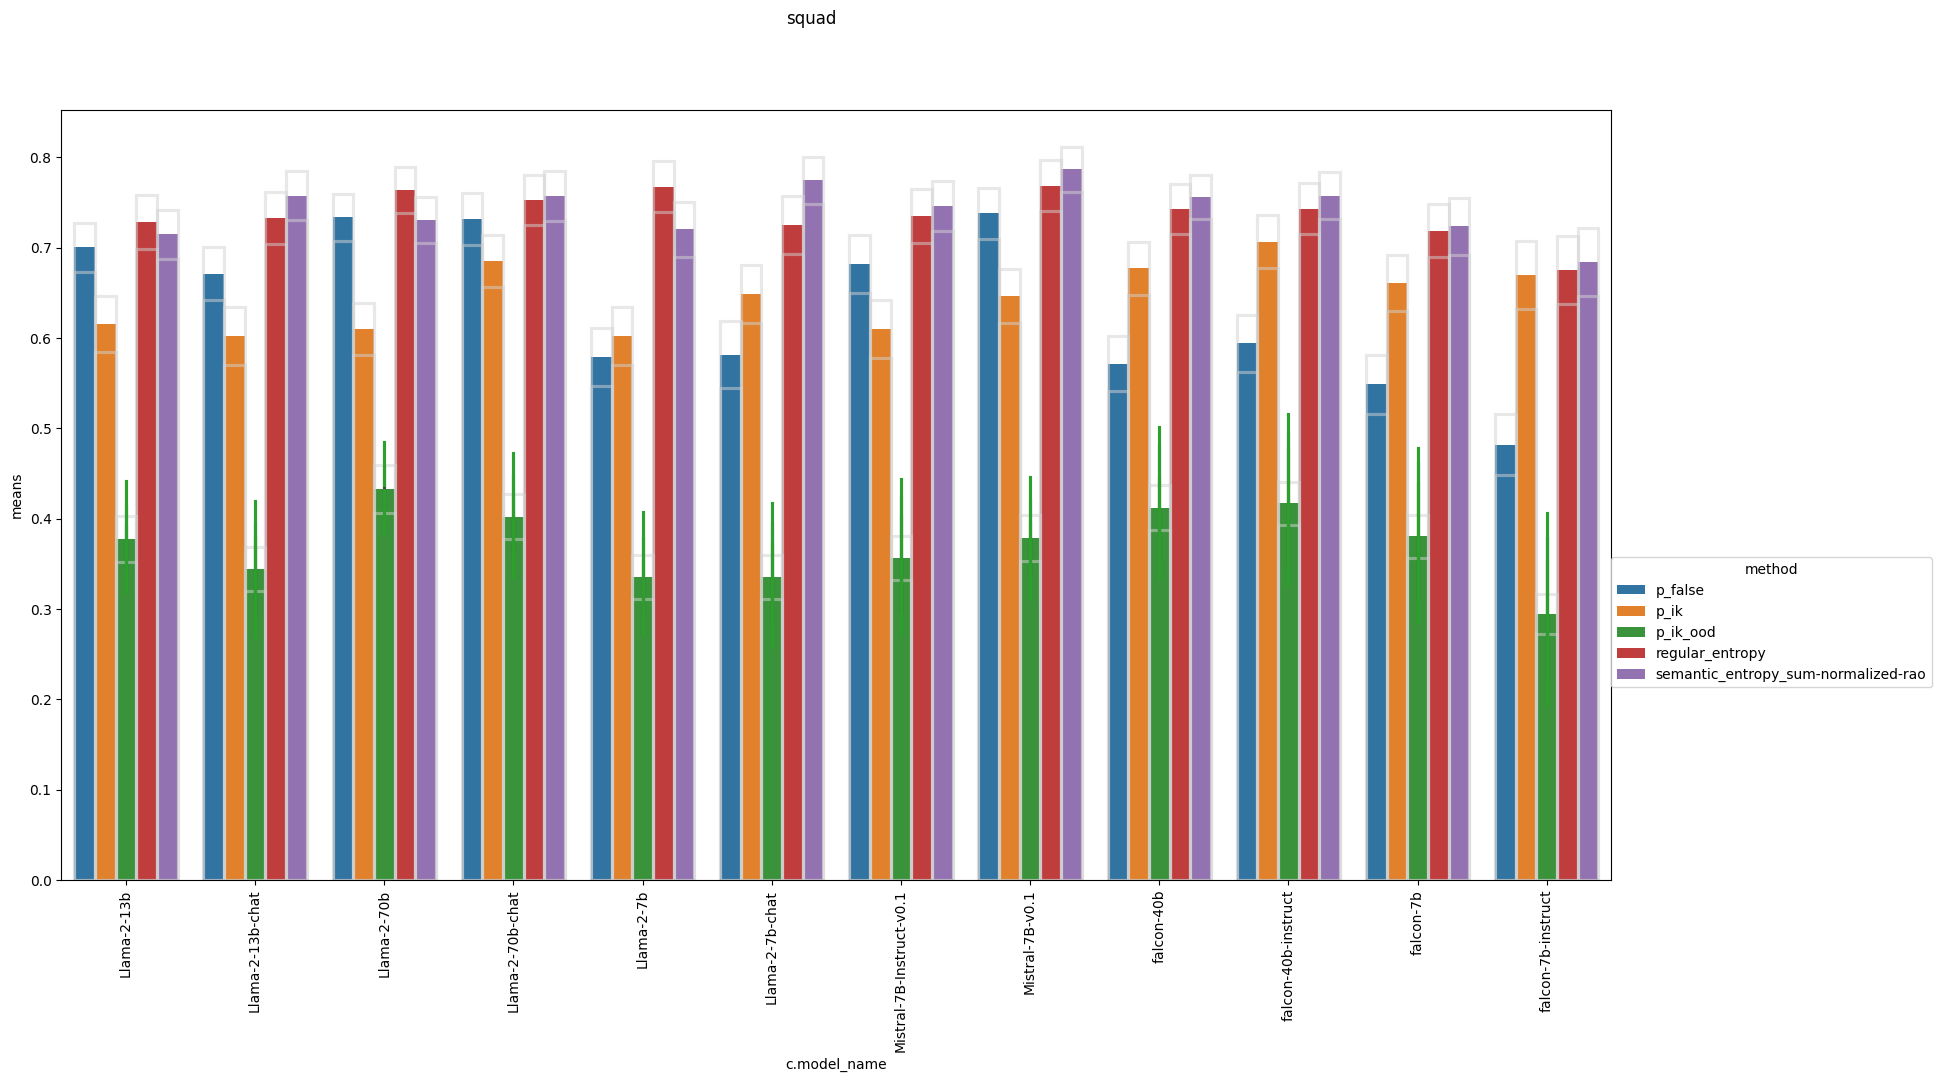

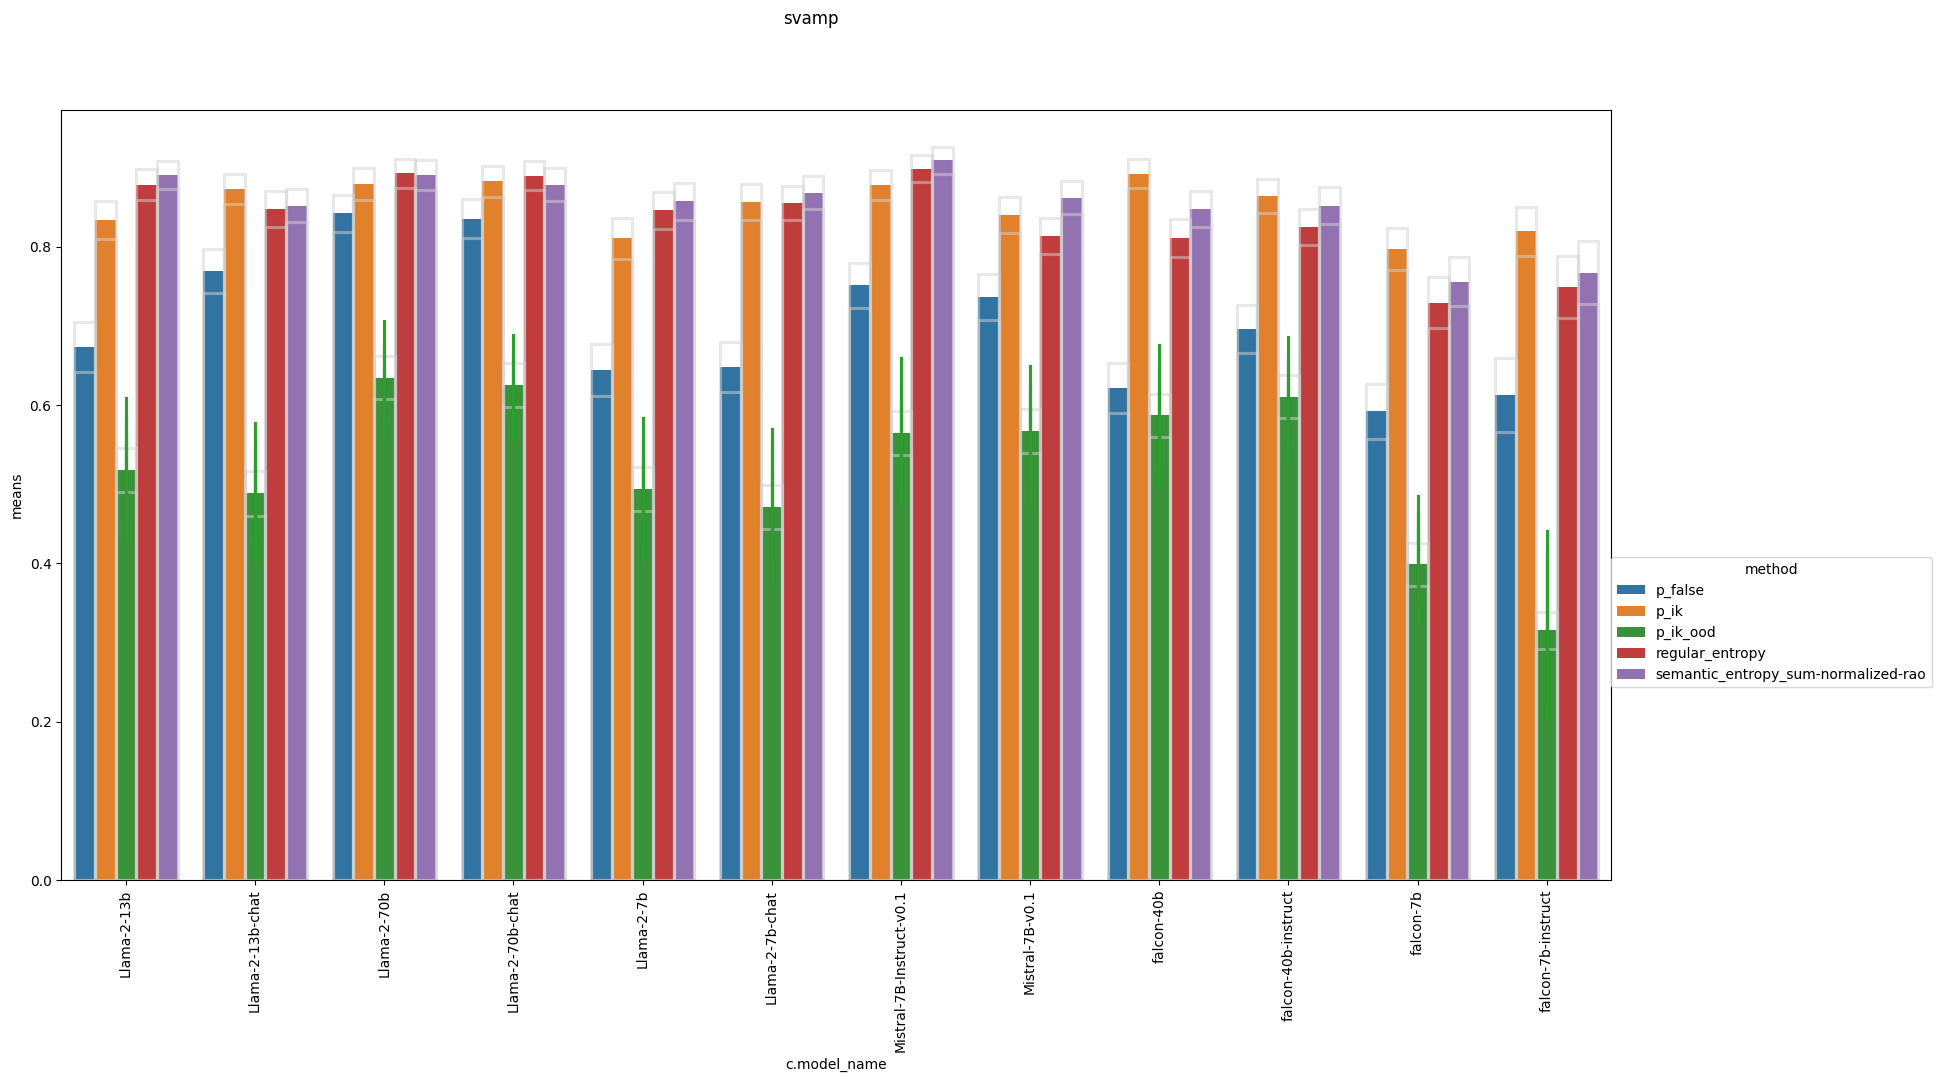

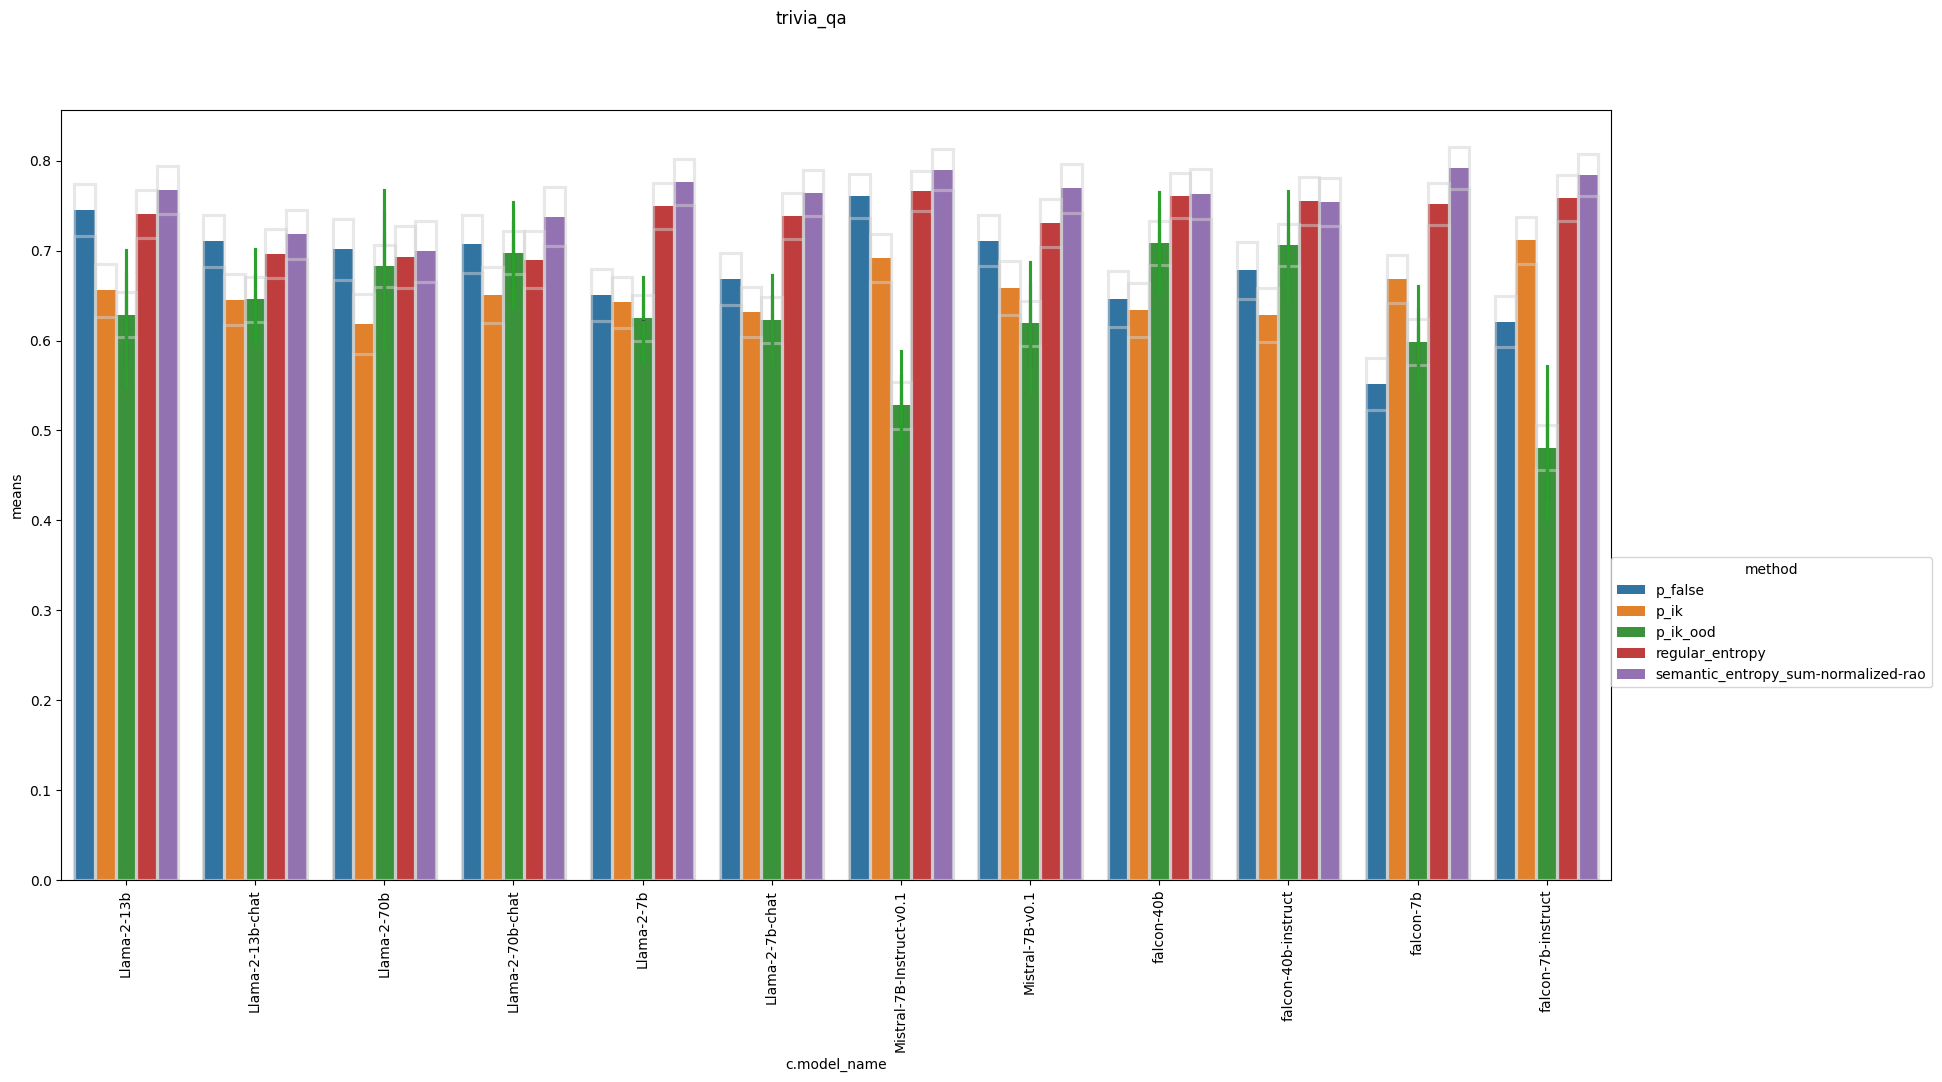

In [420]:
# add average p_ik performance when trained on OOD data
all_relevant_runs = all_runs.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad'].set_index('metric').loc['AUROC'].reset_index()
cat_df = pd.concat([pik_all_runs, all_relevant_runs])

for dataset, gdf in cat_df.groupby('c.dataset'):

    plot_grouped(
        gdf.set_index('method').loc[main_methods + ['p_ik_ood']].reset_index(),
        metric='means', x='c.model_name', hue='method',
        figsize=(20, 10)
    )
    plt.gcf().suptitle(dataset)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

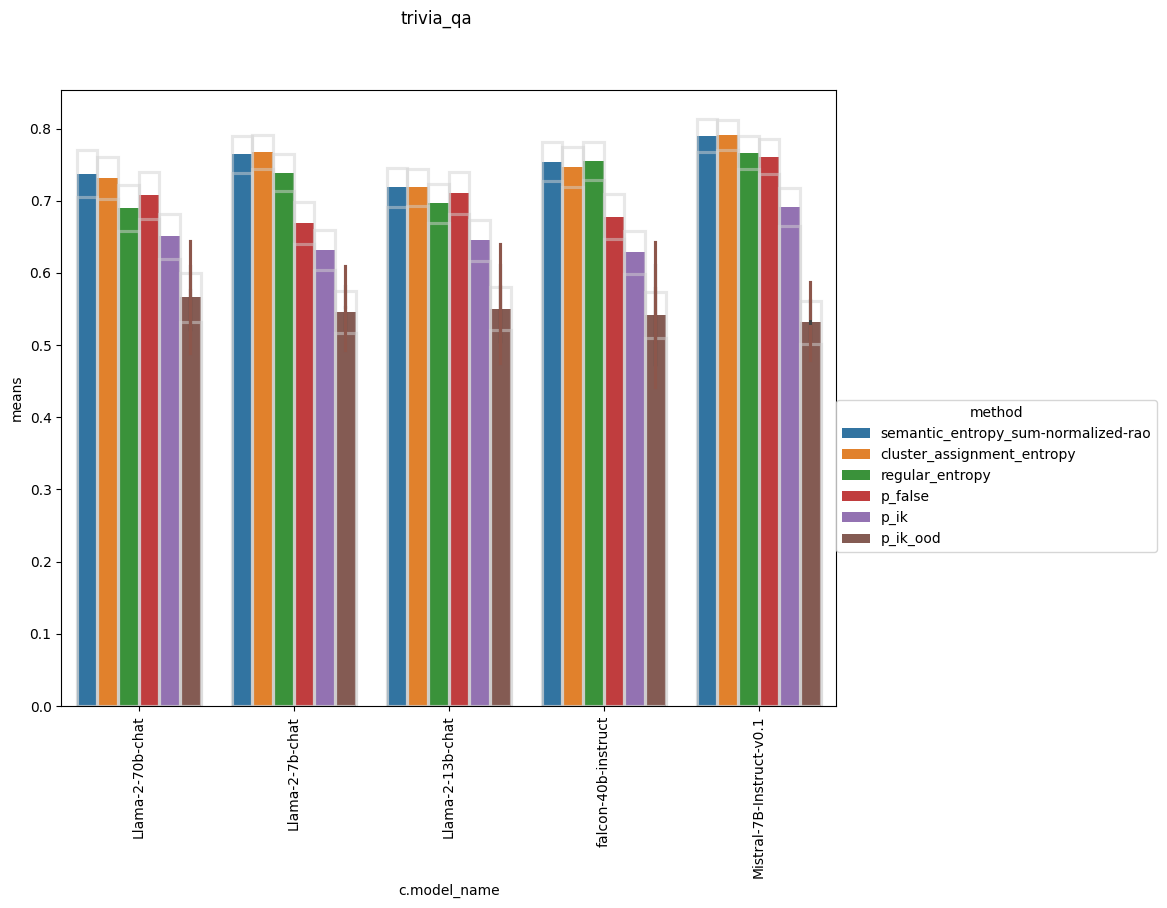

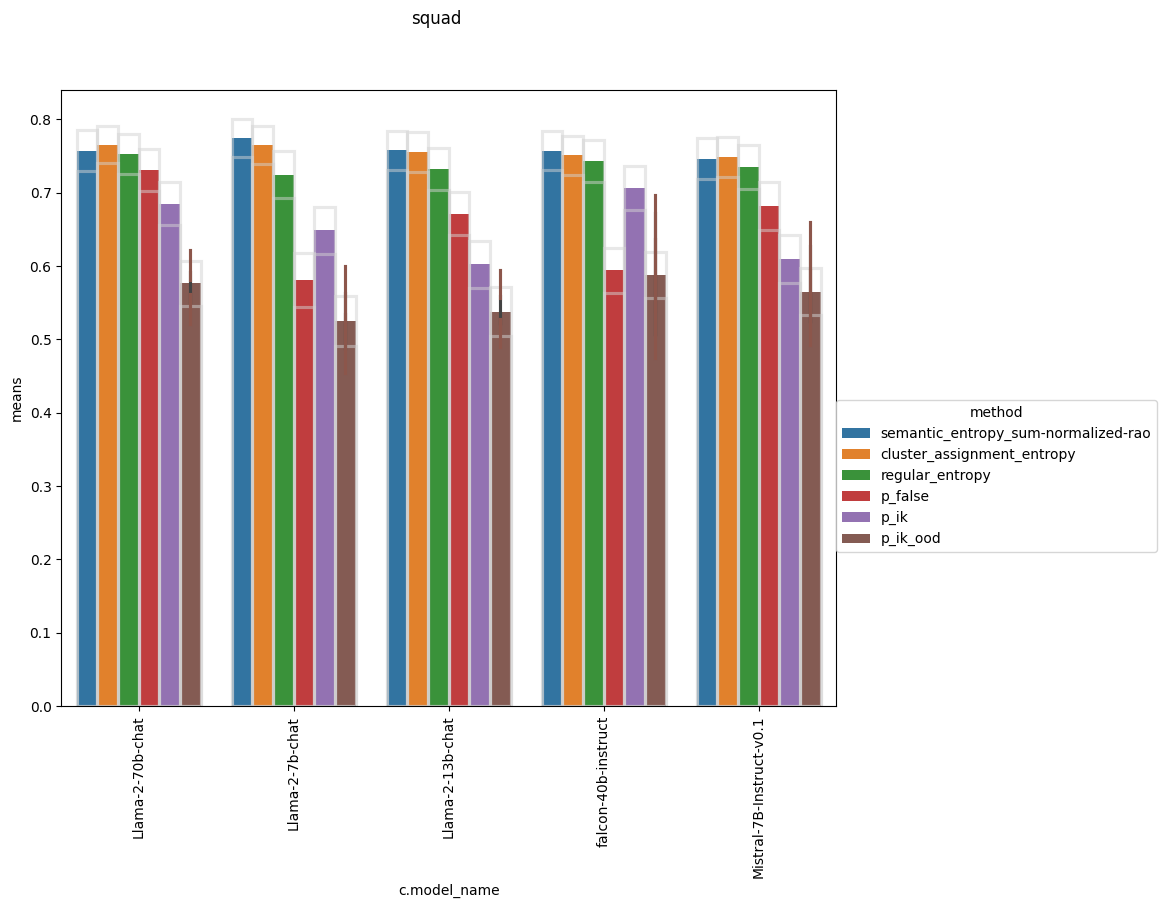

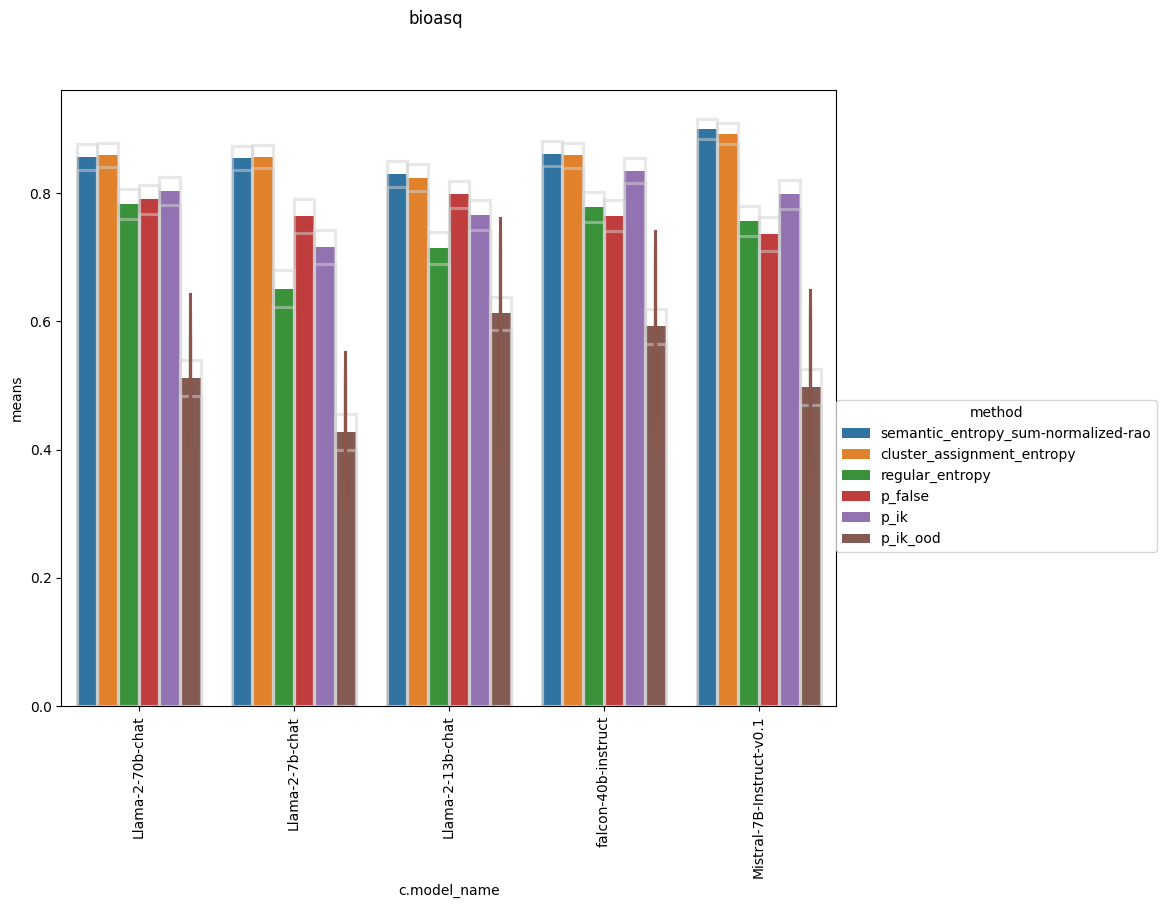

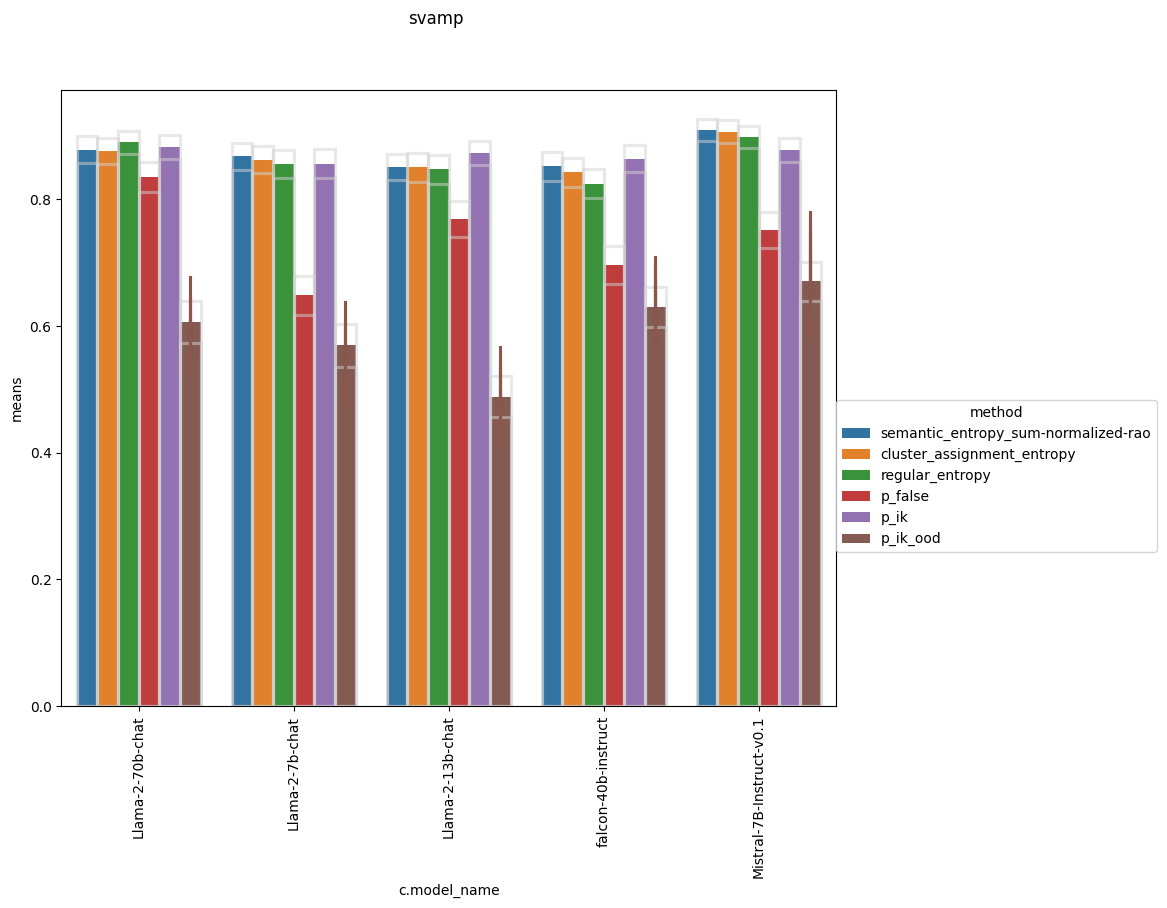

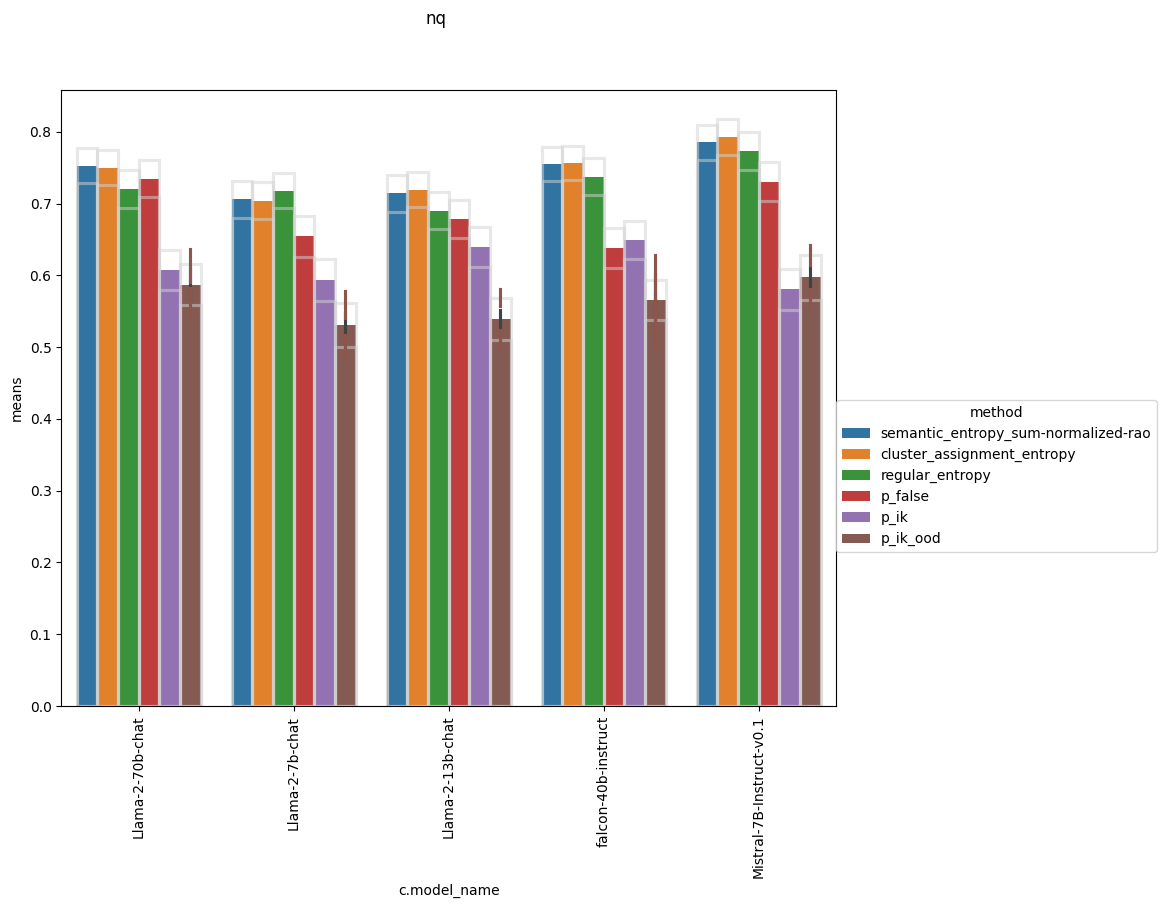

In [421]:
# restrict plot to the datasets/models currently in seb plots
for dataset in ['trivia_qa',  'squad', 'bioasq', 'svamp', 'nq']:
    gdf = cat_df.set_index('c.dataset').loc[dataset].set_index('c.model_name').loc[['Llama-2-70b-chat', 'Llama-2-7b-chat', 'Llama-2-13b-chat', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1']].reset_index()
    # gdf = cat_df.set_index('c.dataset').loc[dataset].set_index('c.model_name').loc[['Llama-2-70b', 'Llama-2-7b', 'Llama-2-13b', 'falcon-40b', 'Mistral-7B-v0.1']].reset_index()

    methods = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood']
    plot_grouped(
        gdf.set_index('metric').loc['AUROC'].set_index('method').loc[methods].reset_index(),
        metric='means', x='c.model_name', hue='method', with_sort=False)
    plt.gcf().suptitle(dataset)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

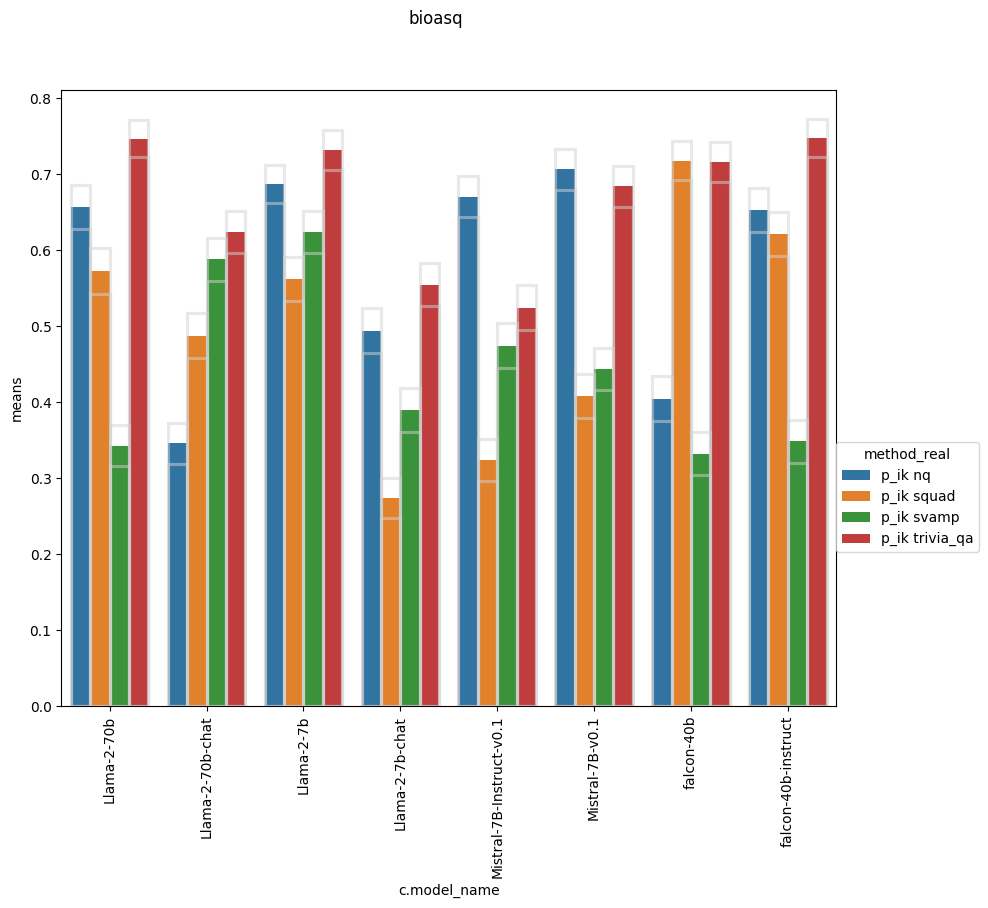

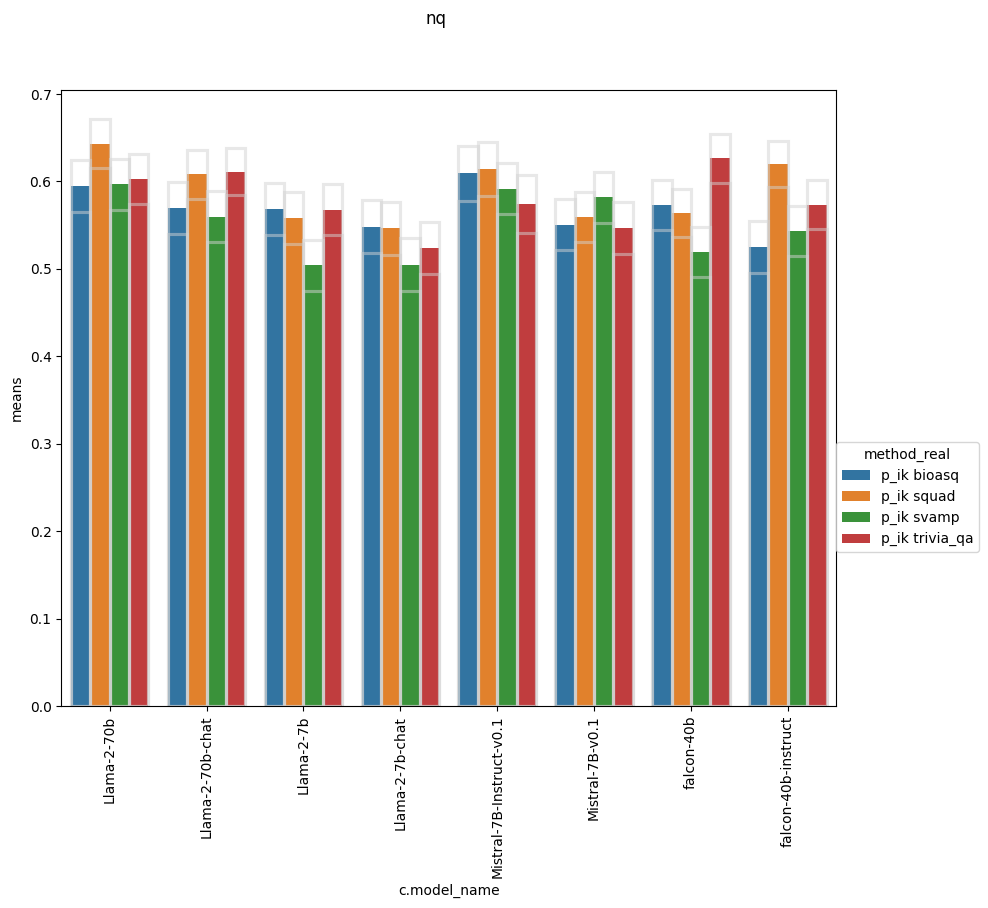

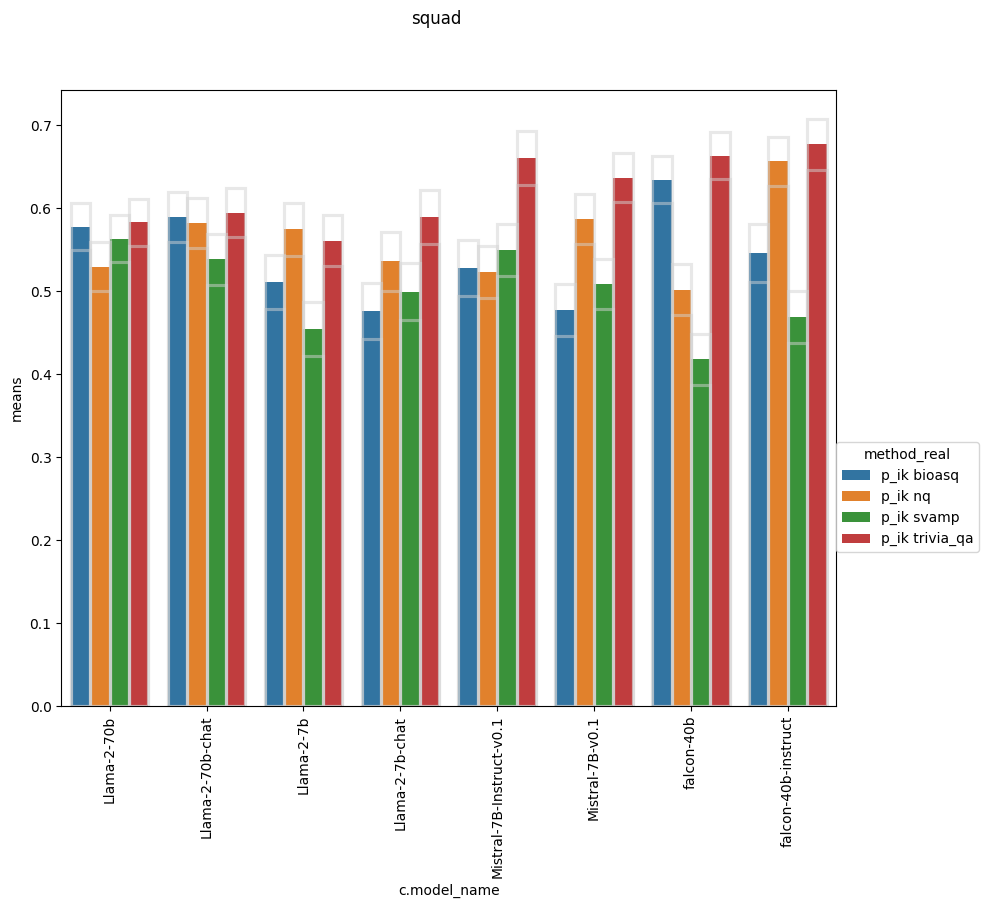

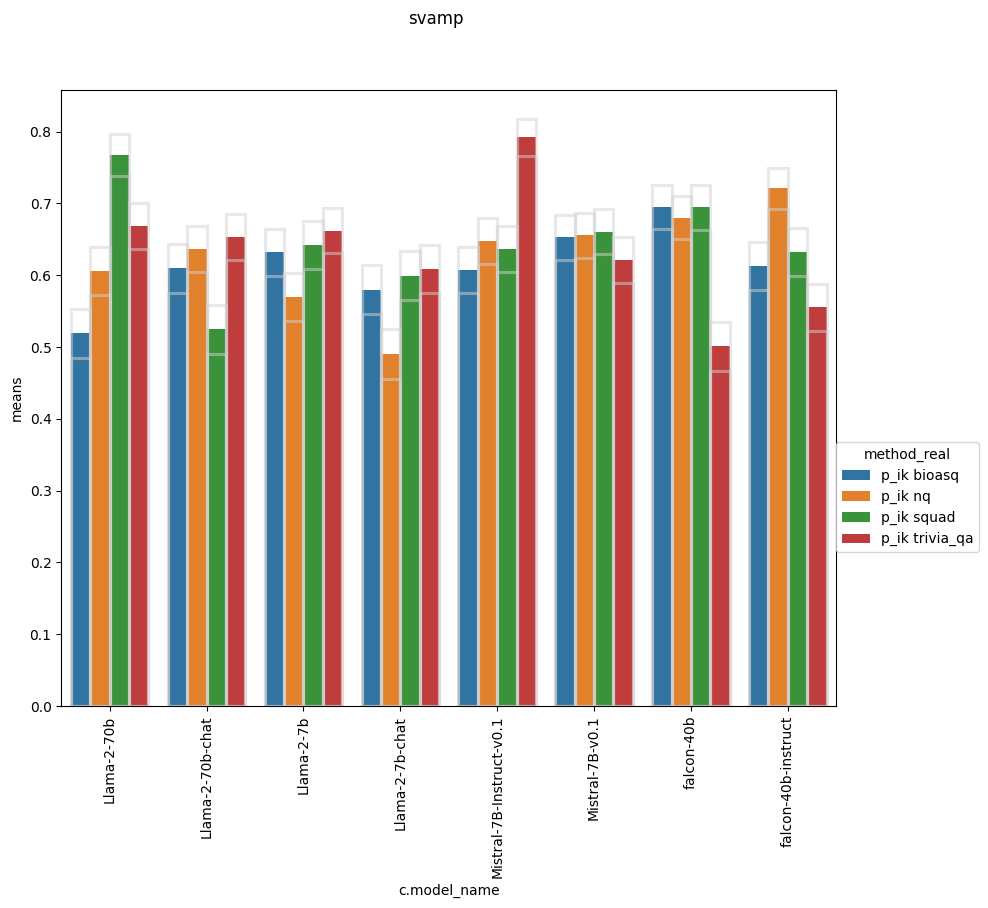

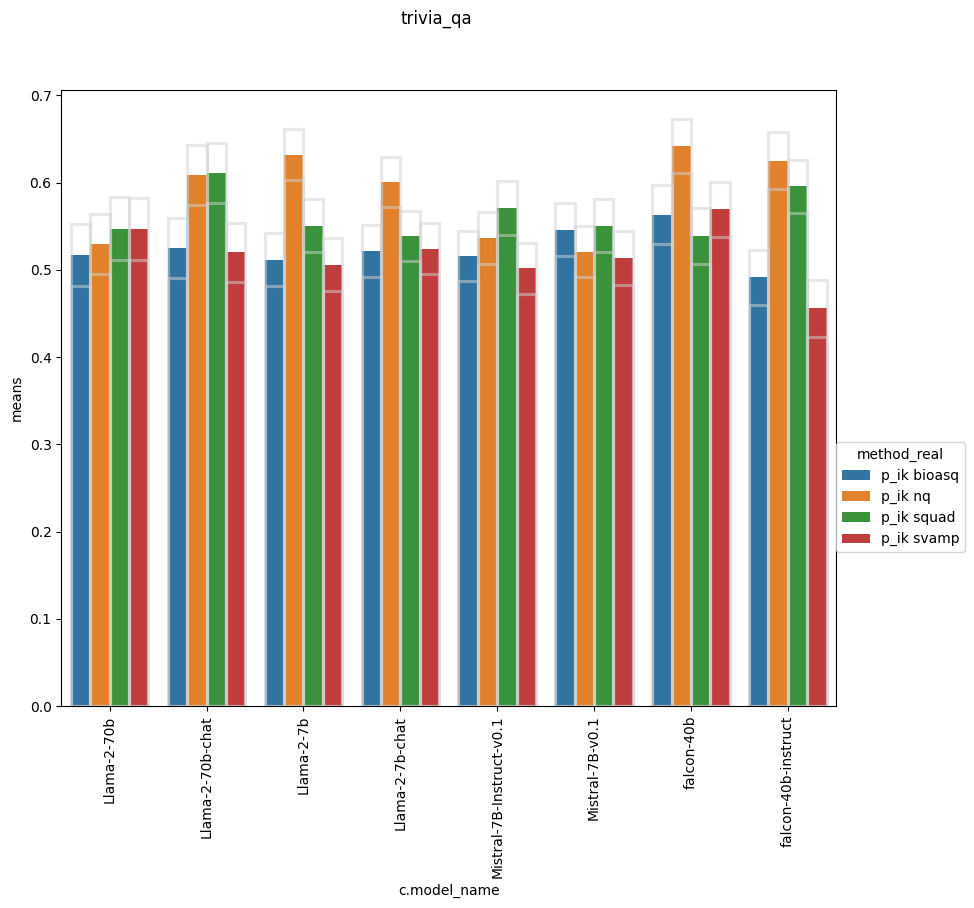

In [224]:
# ood performance separately for p_ik
for dataset, gdf in pik_all_runs.groupby('c.dataset'):
    plot_grouped(
        gdf.set_index('metric').loc['AUROC'],
        metric='means', x='c.model_name', hue='method_real',
    )
    plt.gcf().suptitle(dataset)

In [159]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)

tmp = all_runs.set_index('metric').loc['AUROC']

# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad']
tmp = tmp.set_index('method').loc['semantic_entropy_sum-normalized-rao']
tmp.groupby('c.model_name').mean('means').sort_values('means', ascending=False)

,means,low,high
c.model_name,,,
Mistral-7B-Instruct-v0.1,0.826296,0.804772,0.847821
Mistral-7B-v0.1,0.816590,0.793965,0.839214
Llama-2-70b-chat,0.796512,0.771342,0.821682
falcon-40b-instruct,0.796111,0.772233,0.819989
Llama-2-7b,0.794715,0.770266,0.819164
Llama-2-7b-chat,0.793524,0.770340,0.816708
Llama-2-13b,0.792373,0.768949,0.815797
falcon-40b,0.790103,0.766139,0.814068
Llama-2-70b,0.787404,0.762732,0.812077


In [160]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)

tmp = all_runs.set_index('metric').loc['AUROC']

# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad']
tmp = tmp.set_index('method').loc['semantic_entropy_sum-normalized-rao']
tmp.groupby('c.dataset').mean('means').sort_values('means', ascending=False)

,means,low,high
c.dataset,,,
bioasq,0.856330,0.836918,0.875741
svamp,0.852544,0.829410,0.875677
trivia_qa,0.759738,0.732777,0.786699
nq,0.751031,0.726252,0.775809
squad,0.742457,0.714546,0.770367


In [471]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)

tmp = all_runs.set_index('metric').loc['AUROC']

# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad']
# tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]
tmp = tmp[tmp.method.map(lambda x: x in main_methods)]
tmp.groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao,0.792420,0.767981,0.816859
cluster_assignment_entropy,0.790429,0.766318,0.814540
regular_entropy,0.760006,0.734126,0.785885
p_ik,0.708346,0.681360,0.735332
p_false,0.683316,0.654815,0.711817


In [475]:
main_runs = all_runs.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad']
len(main_runs.set_index('metric').loc['AUROC'].set_index('method').loc['p_false'].groupby(['c.dataset', 'c.model_name']))

60

In [447]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)
main_methods = [
    'semantic_entropy_sum-normalized-rao',
    'cluster_assignment_entropy',
    'regular_entropy',
    'p_false',
    'p_ik',
]

tmp = all_runs.set_index('metric').loc['AUROC']
# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad']
tmp = tmp.set_index('method').loc[main_methods].reset_index()[['method', 'means']]
means = tmp.groupby('method').mean('means').sort_values('means', ascending=False).loc[main_methods]
sems = tmp.groupby('method').agg(sem).sort_values('means', ascending=False).loc[main_methods].rename(columns={'means': 'sem'})
perfstmp = pd.concat([means, sems], axis=1)
with pd.option_context('display.precision', 3):
    display(perfstmp)

,means,sem
method,,
semantic_entropy_sum-normalized-rao,0.792,0.008
cluster_assignment_entropy,0.790,0.007
regular_entropy,0.760,0.007
p_false,0.683,0.013
p_ik,0.708,0.013


/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

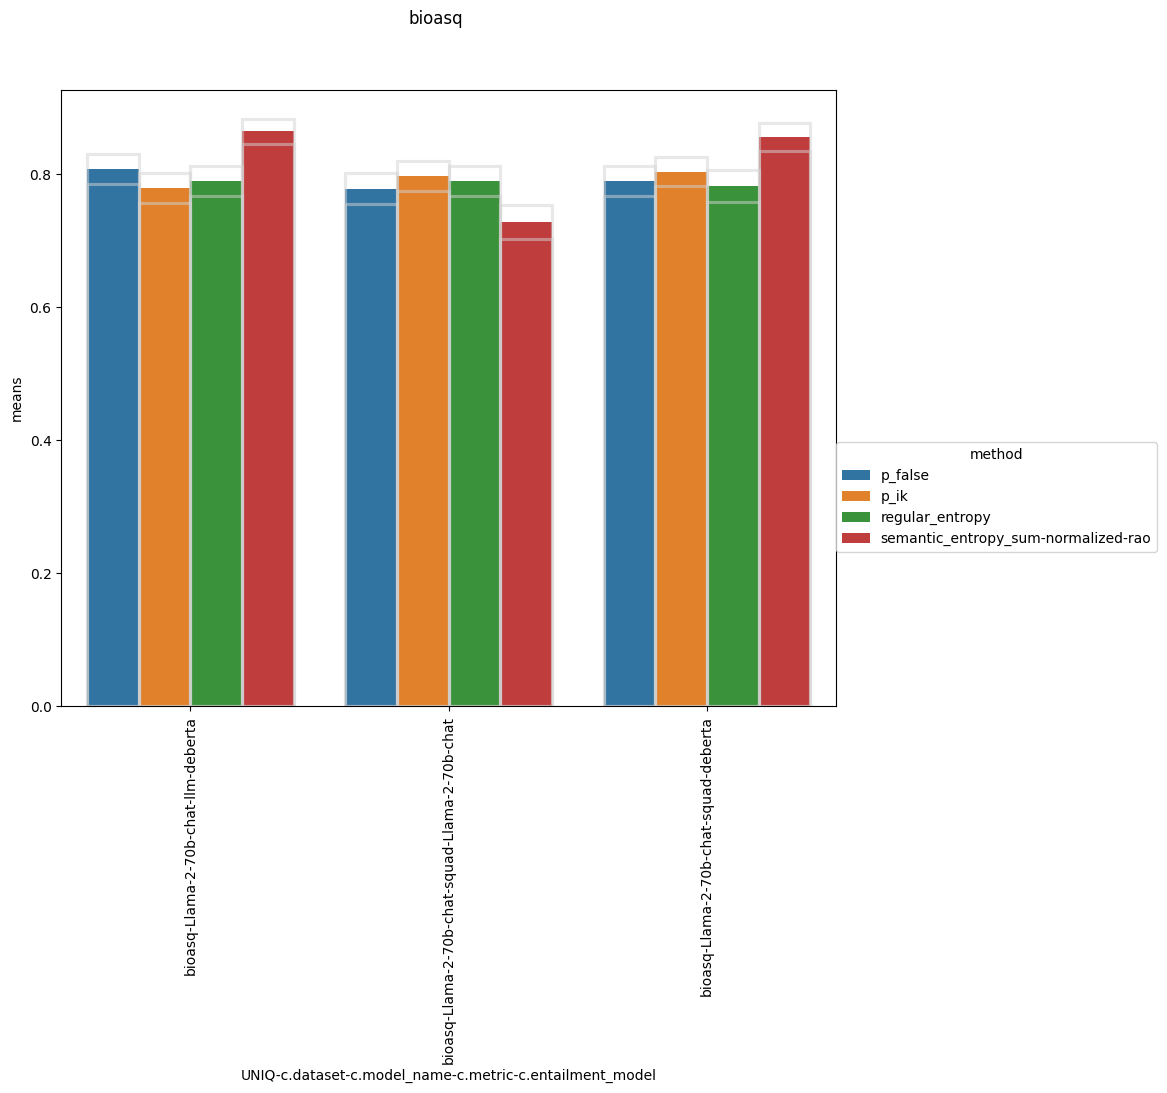

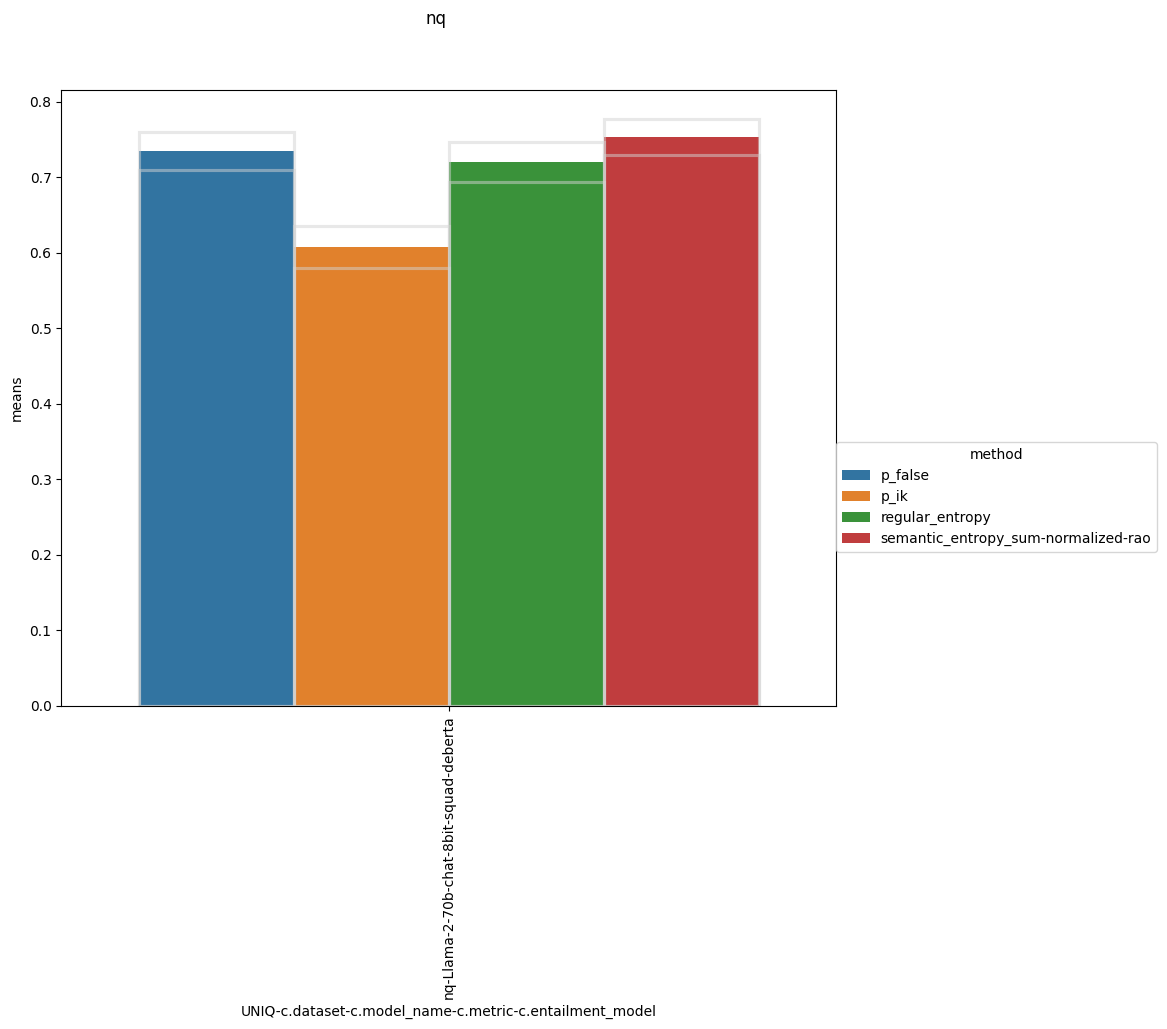

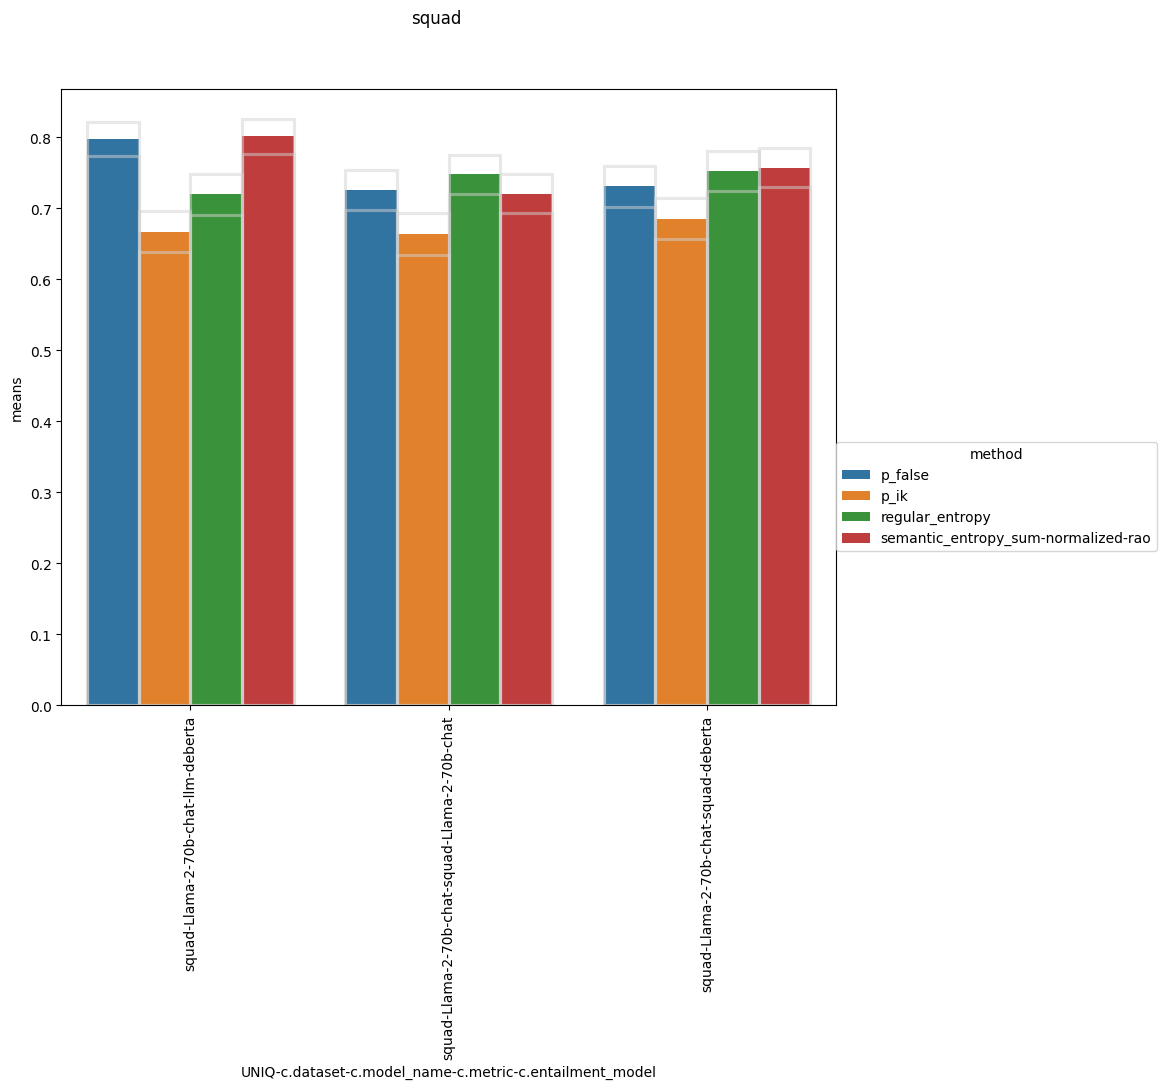

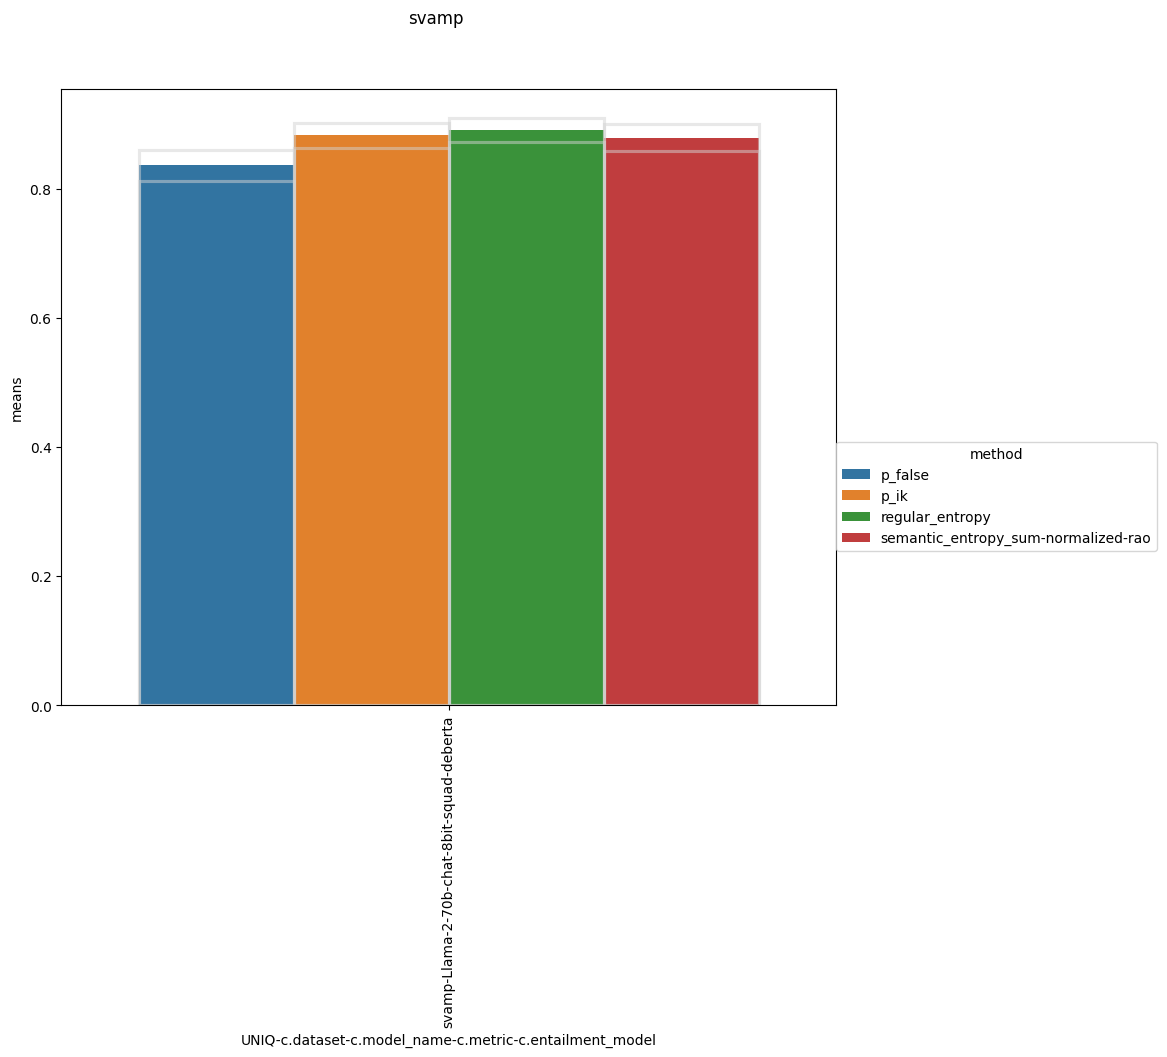

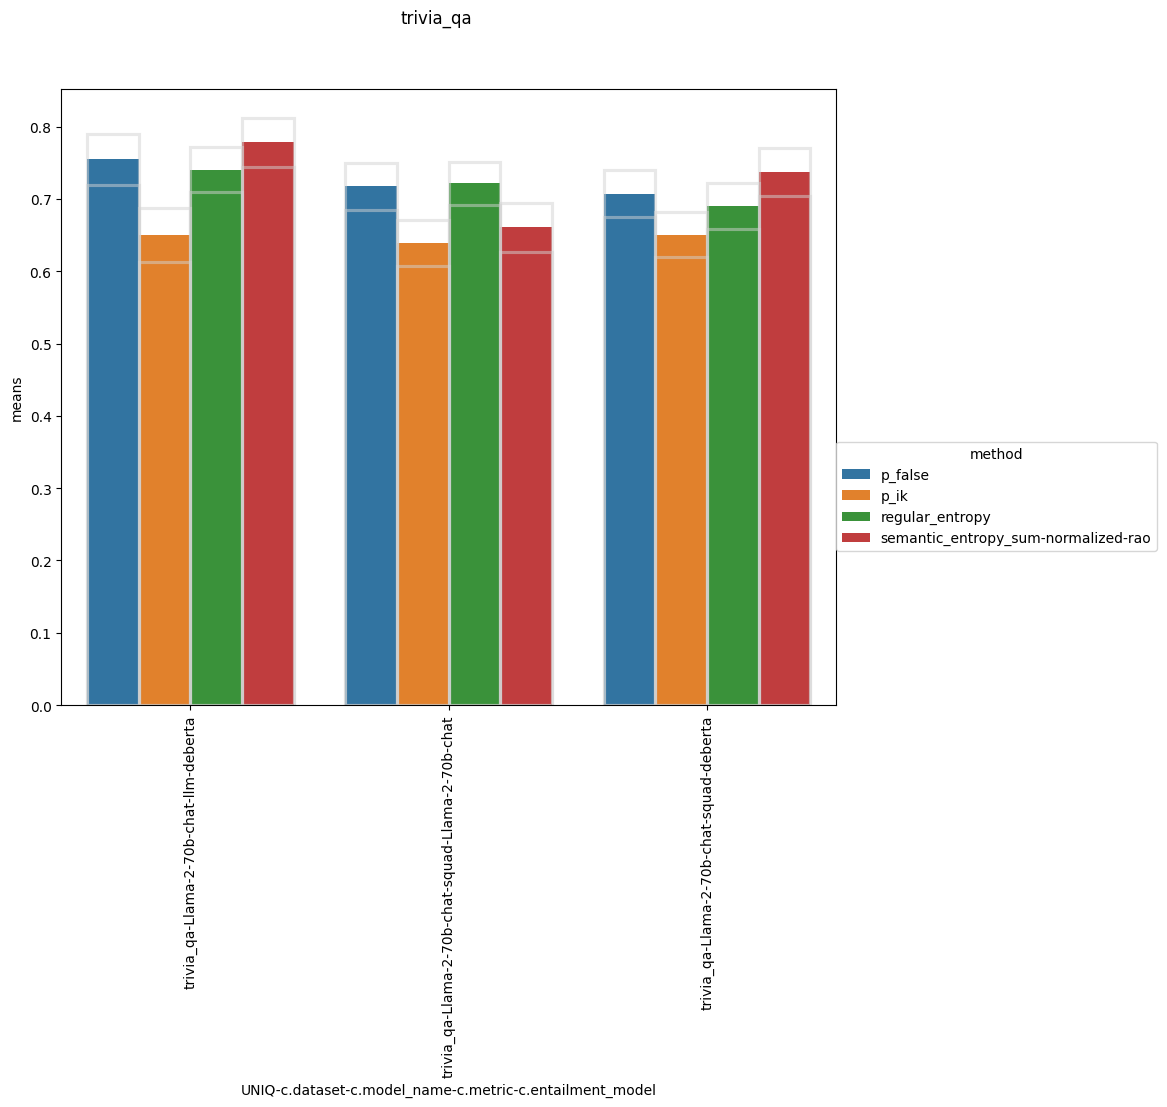

In [162]:
# ablation for llama-2-70b-chat: do other entailment models/accuracy metrics help
for dataset, gdf in all_runs.groupby('c.dataset'):

    plot_grouped(
        gdf.set_index('c.model_name').loc['Llama-2-70b-chat'].set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
        metric='means', x=uniq_name, hue='method',
    )
    plt.gcf().suptitle(dataset)

In [ ]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)
main_methods = [
    'semantic_entropy_sum-normalized-rao',
    'cluster_assignment_entropy',
    'regular_entropy',
    'p_false',
    'p_ik',
]

tmp = all_runs.set_index('metric').loc['AUROC']
# select main runs (they have deberta entailment and squad metric)
# tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]
tmp = tmp.set_index('method').loc[main_methods].reset_index()[['method', 'means']]
means = tmp.groupby('method').mean('means').sort_values('means', ascending=False).loc[main_methods]
sems = tmp.groupby('method').agg(sem).sort_values('means', ascending=False).loc[main_methods].rename(columns={'means': 'sem'})
perfstmp = pd.concat([means, sems], axis=1)
with pd.option_context('display.precision', 3):
    display(perfstmp)

# Analyze length of generations

In [ ]:
# Re-Run (possible rare bug in token for some hidden states (~1/100))

# runs = {
#     'av4gzkg7': 'bioasq-falcon-40b-instruct-squad-deberta',
#     'fr076c4r': 'squad-falcon-40b-squad-deberta',
#     'n0o0k1fj': 'bioasq-falcon-40b-squad-deberta',
#     'yklbn06w': 'squad-Llama-2-70b-chat-llm-deberta',
#     'lmu9rk2f': 'squad-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#     'yxp1vsb6': 'trivia_qa-Llama-2-70b-chat-llm-deberta',
#     'd2vg99sd': 'trivia_qa-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#     '3hel8mhl': 'squad-falcon-40b-instruct-squad-deberta',
#     'wragy6xx': 'trivia_qa-falcon-40b-squad-deberta',
#     'gm0va3z5': 'trivia_qa-falcon-40b-instruct-squad-deberta',
#     'zmzjxzie': 'bioasq-Llama-2-70b-chat-llm-deberta',
#     'q7jzuock': 'bioasq-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#     'ps6tsy1w': 'squad-Llama-2-7b-squad-deberta',
#     'wkoco87o': 'trivia_qa-Llama-2-7b-squad-deberta',
#     'i5pm39lm': 'squad-Llama-2-70b-squad-deberta',
#     'rtkaljty': 'squad-Llama-2-70b-chat-squad-deberta',
#     '0pw5tnye': 'bioasq-Llama-2-7b-squad-deberta',
#     '7j2rbwa7': 'trivia_qa-Llama-2-70b-squad-deberta',
#     'tm87ugfd': 'trivia_qa-Llama-2-70b-chat-squad-deberta',
#     'srf6863m': 'squad-Llama-2-7b-chat-squad-deberta',
#     'p1g0at90': 'trivia_qa-Llama-2-7b-chat-squad-deberta',
#     '6eep0pm4': 'bioasq-Llama-2-7b-chat-squad-deberta',
#     'rlgiuwt5': 'bioasq-Llama-2-70b-squad-deberta',
#     'dn6r1584': 'bioasq-Llama-2-70b-chat-squad-deberta'}
# }


In [427]:
# select runs with deberta-entailment and squad-f1 metric
standard_runs = arg_df.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad'].wandbid.values

In [428]:
# read generations from run
# all_gens = {}
for wandb_id in standard_runs:
    if wandb_id not in all_gens:
        all_gens[wandb_id] = restore_file(wandb_id, filenames=['validation_generations.pkl'])

In [429]:
# compute statistics
low_temp, high_temp, df = get_length_statistic(all_gens)
df = df.merge(arg_df[['wandbid', 'c.dataset', 'c.model_name']], on='wandbid')

df

,temp,wandbid,statistic,value,c.dataset,c.model_name
0,low,j1c2w3a7,mean,10.795000,trivia_qa,Mistral-7B-Instruct-v0.1
1,low,j1c2w3a7,sem,0.603557,trivia_qa,Mistral-7B-Instruct-v0.1
2,low,j1c2w3a7,std,12.056035,trivia_qa,Mistral-7B-Instruct-v0.1
3,low,j1c2w3a7,median,9.000000,trivia_qa,Mistral-7B-Instruct-v0.1
4,high,j1c2w3a7,mean,12.024750,trivia_qa,Mistral-7B-Instruct-v0.1
...,...,...,...,...,...,...
475,low,xps6i5qz,median,7.000000,bioasq,falcon-7b
476,high,xps6i5qz,mean,18.812250,bioasq,falcon-7b
477,high,xps6i5qz,sem,0.405657,bioasq,falcon-7b
478,high,xps6i5qz,std,25.652807,bioasq,falcon-7b


In [430]:
np.concatenate(list(low_temp.values()) + list(high_temp.values())).shape

(250800,)

In [431]:
stats(np.concatenate(list(low_temp.values()) + list(high_temp.values())))

{'mean': 15.938122009569378,
 'sem': 0.04361576346190586,
 'std': 21.84270292601857,
 'median': 9.0}

In [432]:
# this is only correct for mean!!
# stats(df.set_index('statistic').loc['mean']['value'])

In [433]:
# average length per model and dataset
for name, gdf in df.groupby('temp'):
    print('temperature', name)
    gdf = gdf.set_index('statistic').loc['mean']
    display(gdf.pivot(index='c.dataset', columns='c.model_name', values='value')) 

temperature high


c.model_name,Llama-2-13b,Llama-2-13b-chat,Llama-2-70b,Llama-2-70b-chat,Llama-2-7b,Llama-2-7b-chat,Mistral-7B-Instruct-v0.1,Mistral-7B-v0.1,falcon-40b,falcon-40b-instruct,falcon-7b,falcon-7b-instruct
c.dataset,,,,,,,,,,,,
bioasq,17.572000,18.192250,20.615750,19.063500,17.815250,19.83825,24.40325,21.29325,20.517000,23.26025,18.81225,28.25450
nq,17.548750,16.395000,17.922500,18.903750,18.472750,17.32850,25.51575,18.35625,23.015500,28.82800,17.81050,24.77350
squad,19.614000,18.293500,22.355000,19.088000,21.637750,20.01600,28.09075,19.93050,21.465500,23.01075,20.04150,30.26350
svamp,4.141667,4.260333,4.044333,4.195667,4.115667,4.35700,5.30200,4.08200,4.343333,4.70000,4.67200,6.13000
trivia_qa,9.126750,9.460500,9.714500,9.280000,9.754250,9.77200,12.02475,9.19950,9.503500,9.95575,9.88800,12.93825


temperature low


c.model_name,Llama-2-13b,Llama-2-13b-chat,Llama-2-70b,Llama-2-70b-chat,Llama-2-7b,Llama-2-7b-chat,Mistral-7B-Instruct-v0.1,Mistral-7B-v0.1,falcon-40b,falcon-40b-instruct,falcon-7b,falcon-7b-instruct
c.dataset,,,,,,,,,,,,
bioasq,17.755000,17.230000,19.715000,17.2025,16.1700,19.8075,25.537500,17.052500,17.3825,20.412500,16.8625,26.982500
nq,14.465000,16.147500,16.012500,17.0000,15.6325,16.1450,20.190000,14.130000,15.6575,23.447500,14.0650,19.980000
squad,16.055000,17.052500,16.365000,16.1400,15.6675,17.9775,22.547500,15.252500,14.7175,18.207500,14.8450,24.200000
svamp,4.076667,4.336667,4.033333,4.1400,4.0700,4.2800,4.183333,4.023333,3.9900,4.096667,3.8900,4.573333
trivia_qa,9.040000,9.260000,9.132500,9.2150,9.2725,9.5025,10.795000,9.027500,9.1350,9.415000,9.7400,11.480000


In [434]:
# average length per dataset
for name, gdf in df.groupby('temp'):
    print('temperature', name)
    gdf = gdf.set_index('statistic').loc['mean'].reset_index()
    display(gdf.groupby('c.dataset').mean('value'))


temperature high


,value
c.dataset,
bioasq,20.803125
nq,20.405896
squad,21.983896
svamp,4.528667
trivia_qa,10.051479


temperature low


,value
c.dataset,
bioasq,19.342500
nq,16.906042
squad,17.418958
svamp,4.141111
trivia_qa,9.584583


In [170]:
# average length per model
for name, gdf in df.groupby('temp'):
    print(name)
    gdf = gdf.set_index('statistic').loc['mean']
    display(gdf.groupby('c.model_name').mean('value'))

high


,value
c.model_name,
Llama-2-13b,13.600633
Llama-2-13b-chat,13.320317
Llama-2-70b,14.930417
Llama-2-70b-chat,14.106183
Llama-2-7b,14.359133
Llama-2-7b-chat,14.262350
Mistral-7B-Instruct-v0.1,19.067300
Mistral-7B-v0.1,14.572300
falcon-40b,15.768967


low


,value
c.model_name,
Llama-2-13b,12.278333
Llama-2-13b-chat,12.805333
Llama-2-70b,13.051667
Llama-2-70b-chat,12.739500
Llama-2-7b,12.162500
Llama-2-7b-chat,13.542500
Mistral-7B-Instruct-v0.1,16.650667
Mistral-7B-v0.1,11.897167
falcon-40b,12.176500


In [171]:
# more_detailed results per model and dataset
for name, gdf in df.groupby('temp'):
    print(name)
    display(gdf.pivot(index=['c.dataset', 'c.model_name'], columns='statistic', values='value')) 

high


statistic                                mean  median       sem        std
c.dataset c.model_name                                                    
bioasq    Llama-2-13b               17.572000     8.0  0.373835  23.640428
          Llama-2-13b-chat          18.192250    10.0  0.357070  22.580252
          Llama-2-70b               20.615750    10.0  0.445123  28.148545
          Llama-2-70b-chat          19.063500     9.0  0.413083  26.122384
          Llama-2-7b                17.815250     8.0  0.390119  24.670187
          Llama-2-7b-chat           19.838250    10.0  0.390317  24.682698
          Mistral-7B-Instruct-v0.1  24.403250    11.0  0.542676  34.317541
          Mistral-7B-v0.1           21.293250     9.0  0.465773  29.454393
          falcon-40b                20.517000    10.0  0.435586  27.545403
          falcon-40b-instruct       23.260250    11.0  0.501202  31.694850
          falcon-7b                 18.812250     9.0  0.405657  25.652807
          falcon-7b-instruct        28.254500    16.0  0.563306  35.622159
nq        Llama-2-13b               17.548750    13.0  0.327888  20.734865
          Llama-2-13b-chat          16.395000    13.0  0.258036  16.317582
          Llama-2-70b               17.922500    13.0  0.329816  20.856797
          Llama-2-70b-chat          18.903750    13.0  0.341219  21.577905
          Llama-2-7b                18.472750    13.0  0.360069  22.769909
          Llama-2-7b-chat           17.328500    13.0  0.290149  18.348327
          Mistral-7B-Instruct-v0.1  25.515750    14.0  0.530168  33.526560
          Mistral-7B-v0.1           18.356250    13.0  0.356233  22.527335
          falcon-40b                23.015500    14.0  0.486624  30.772963
          falcon-40b-instruct       28.828000    15.0  0.607481  38.415692
          falcon-7b                 17.810500    13.0  0.318140  20.118451
          falcon-7b-instruct        24.773500    15.0  0.446738  28.250685
squad     Llama-2-13b               19.614000    14.0  0.318136  20.118188
          Llama-2-13b-chat          18.293500    15.0  0.245388  15.517759
          Llama-2-70b               22.355000    15.0  0.391558  24.761189
          Llama-2-70b-chat          19.088000    14.0  0.315041  19.922456
          Llama-2-7b                21.637750    15.0  0.370278  23.415508
          Llama-2-7b-chat           20.016000    15.0  0.298605  18.883054
          Mistral-7B-Instruct-v0.1  28.090750    18.0  0.483014  30.544664
          Mistral-7B-v0.1           19.930500    14.0  0.333893  21.114584
          falcon-40b                21.465500    14.5  0.369656  23.376191
          falcon-40b-instruct       23.010750    15.0  0.399029  25.233631
          falcon-7b                 20.041500    14.0  0.336708  21.292623
          falcon-7b-instruct        30.263500    19.0  0.502631  31.785186
svamp     Llama-2-13b                4.141667     4.0  0.031871   1.745355
          Llama-2-13b-chat           4.260333     4.0  0.042396   2.321758
          Llama-2-70b                4.044333     4.0  0.022931   1.255800
          Llama-2-70b-chat           4.195667     4.0  0.039960   2.188313
          Llama-2-7b                 4.115667     4.0  0.029810   1.632469
          Llama-2-7b-chat            4.357000     4.0  0.049159   2.692128
          Mistral-7B-Instruct-v0.1   5.302000     4.0  0.181238   9.925160
          Mistral-7B-v0.1            4.082000     4.0  0.040162   2.199381
          falcon-40b                 4.343333     4.0  0.119783   6.559684
          falcon-40b-instruct        4.700000     4.0  0.111699   6.116971
          falcon-7b                  4.672000     4.0  0.176775   9.680758
          falcon-7b-instruct         6.130000     4.0  0.193666  10.605742
trivia_qa Llama-2-13b                9.126750     8.0  0.075491   4.773854
          Llama-2-13b-chat           9.460500     8.0  0.079555   5.030849
          Llama-2-70b                9.714500     9.0  0.103096   6.519547
          Llama-2-70b-cha

low


statistic                                mean  median       sem        std
c.dataset c.model_name                                                    
bioasq    Llama-2-13b               17.755000     7.0  1.170898  23.388672
          Llama-2-13b-chat          17.230000     9.0  1.044549  20.864853
          Llama-2-70b               19.715000     8.0  1.457647  29.116469
          Llama-2-70b-chat          17.202500     8.0  1.116005  22.292185
          Llama-2-7b                16.170000     6.0  1.070651  21.386236
          Llama-2-7b-chat           19.807500     9.0  1.281462  25.597176
          Mistral-7B-Instruct-v0.1  25.537500     9.0  1.952820  39.007545
          Mistral-7B-v0.1           17.052500     6.0  1.201935  24.008639
          falcon-40b                17.382500     7.0  1.282753  25.622962
          falcon-40b-instruct       20.412500     8.0  1.410174  28.168197
          falcon-7b                 16.862500     7.0  1.255523  25.079047
          falcon-7b-instruct        26.982500    14.0  1.736799  34.692538
nq        Llama-2-13b               14.465000    11.0  0.834040  16.659945
          Llama-2-13b-chat          16.147500    12.0  0.818827  16.356061
          Llama-2-70b               16.012500    12.0  1.056739  21.108348
          Llama-2-70b-chat          17.000000    13.0  0.909336  18.163975
          Llama-2-7b                15.632500    12.0  0.982762  19.630651
          Llama-2-7b-chat           16.145000    12.0  0.828765  16.554576
          Mistral-7B-Instruct-v0.1  20.190000    13.0  1.330921  26.585126
          Mistral-7B-v0.1           14.130000    11.5  0.926636  18.509541
          falcon-40b                15.657500    12.0  1.109647  22.165180
          falcon-40b-instruct       23.447500    13.0  1.574015  31.440933
          falcon-7b                 14.065000    12.0  0.680770  13.598374
          falcon-7b-instruct        19.980000    13.5  1.113665  22.245440
squad     Llama-2-13b               16.055000    13.0  0.878684  17.551694
          Llama-2-13b-chat          17.052500    13.5  0.777986  15.540262
          Llama-2-70b               16.365000    12.0  0.789605  15.772342
          Llama-2-70b-chat          16.140000    12.0  0.777415  15.528857
          Llama-2-7b                15.667500    12.5  0.606496  12.114741
          Llama-2-7b-chat           17.977500    13.0  0.936180  18.700187
          Mistral-7B-Instruct-v0.1  22.547500    15.0  1.375832  27.482226
          Mistral-7B-v0.1           15.252500    11.0  0.830246  16.584141
          falcon-40b                14.717500    12.0  0.592270  11.830583
          falcon-40b-instruct       18.207500    13.0  0.938730  18.751118
          falcon-7b                 14.845000    12.0  0.607835  12.141498
          falcon-7b-instruct        24.200000    16.0  1.300183  25.971138
svamp     Llama-2-13b                4.076667     4.0  0.060951   1.053940
          Llama-2-13b-chat           4.336667     4.0  0.157070   2.716000
          Llama-2-70b                4.033333     4.0  0.061173   1.057775
          Llama-2-70b-chat           4.140000     4.0  0.159225   2.753253
          Llama-2-7b                 4.070000     4.0  0.060611   1.048062
          Llama-2-7b-chat            4.280000     4.0  0.114231   1.975247
          Mistral-7B-Instruct-v0.1   4.183333     4.0  0.101434   1.753964
          Mistral-7B-v0.1            4.023333     4.0  0.058487   1.011330
          falcon-40b                 3.990000     4.0  0.074133   1.281887
          falcon-40b-instruct        4.096667     4.0  0.076299   1.319339
          falcon-7b                  3.890000     4.0  0.074911   1.295338
          falcon-7b-instruct         4.573333     4.0  0.175138   3.028414
trivia_qa Llama-2-13b                9.040000     8.0  0.218811   4.370744
          Llama-2-13b-chat           9.260000     8.0  0.233677   4.667698
          Llama-2-70b                9.132500     9.0  0.216719   4.328966
          Llama-2-70b-cha

# Cluster distribution

In [435]:
standard_arg = arg_df.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad']
standard_runs = standard_arg.wandbid.values

In [436]:
# uncertainties = {}
for wandb_id in standard_runs:
    if wandb_id not in uncertainties:
        uncertainties[wandb_id] = restore_file(wandb_id, filenames=['uncertainty_measures.pkl'])

In [437]:
num_ids = {}
for wandbid, unc in uncertainties.items():
    unc = unc[0]
    num_ids[wandbid] = np.array([len(np.unique(s)) for s in np.array(unc['semantic_ids'])])

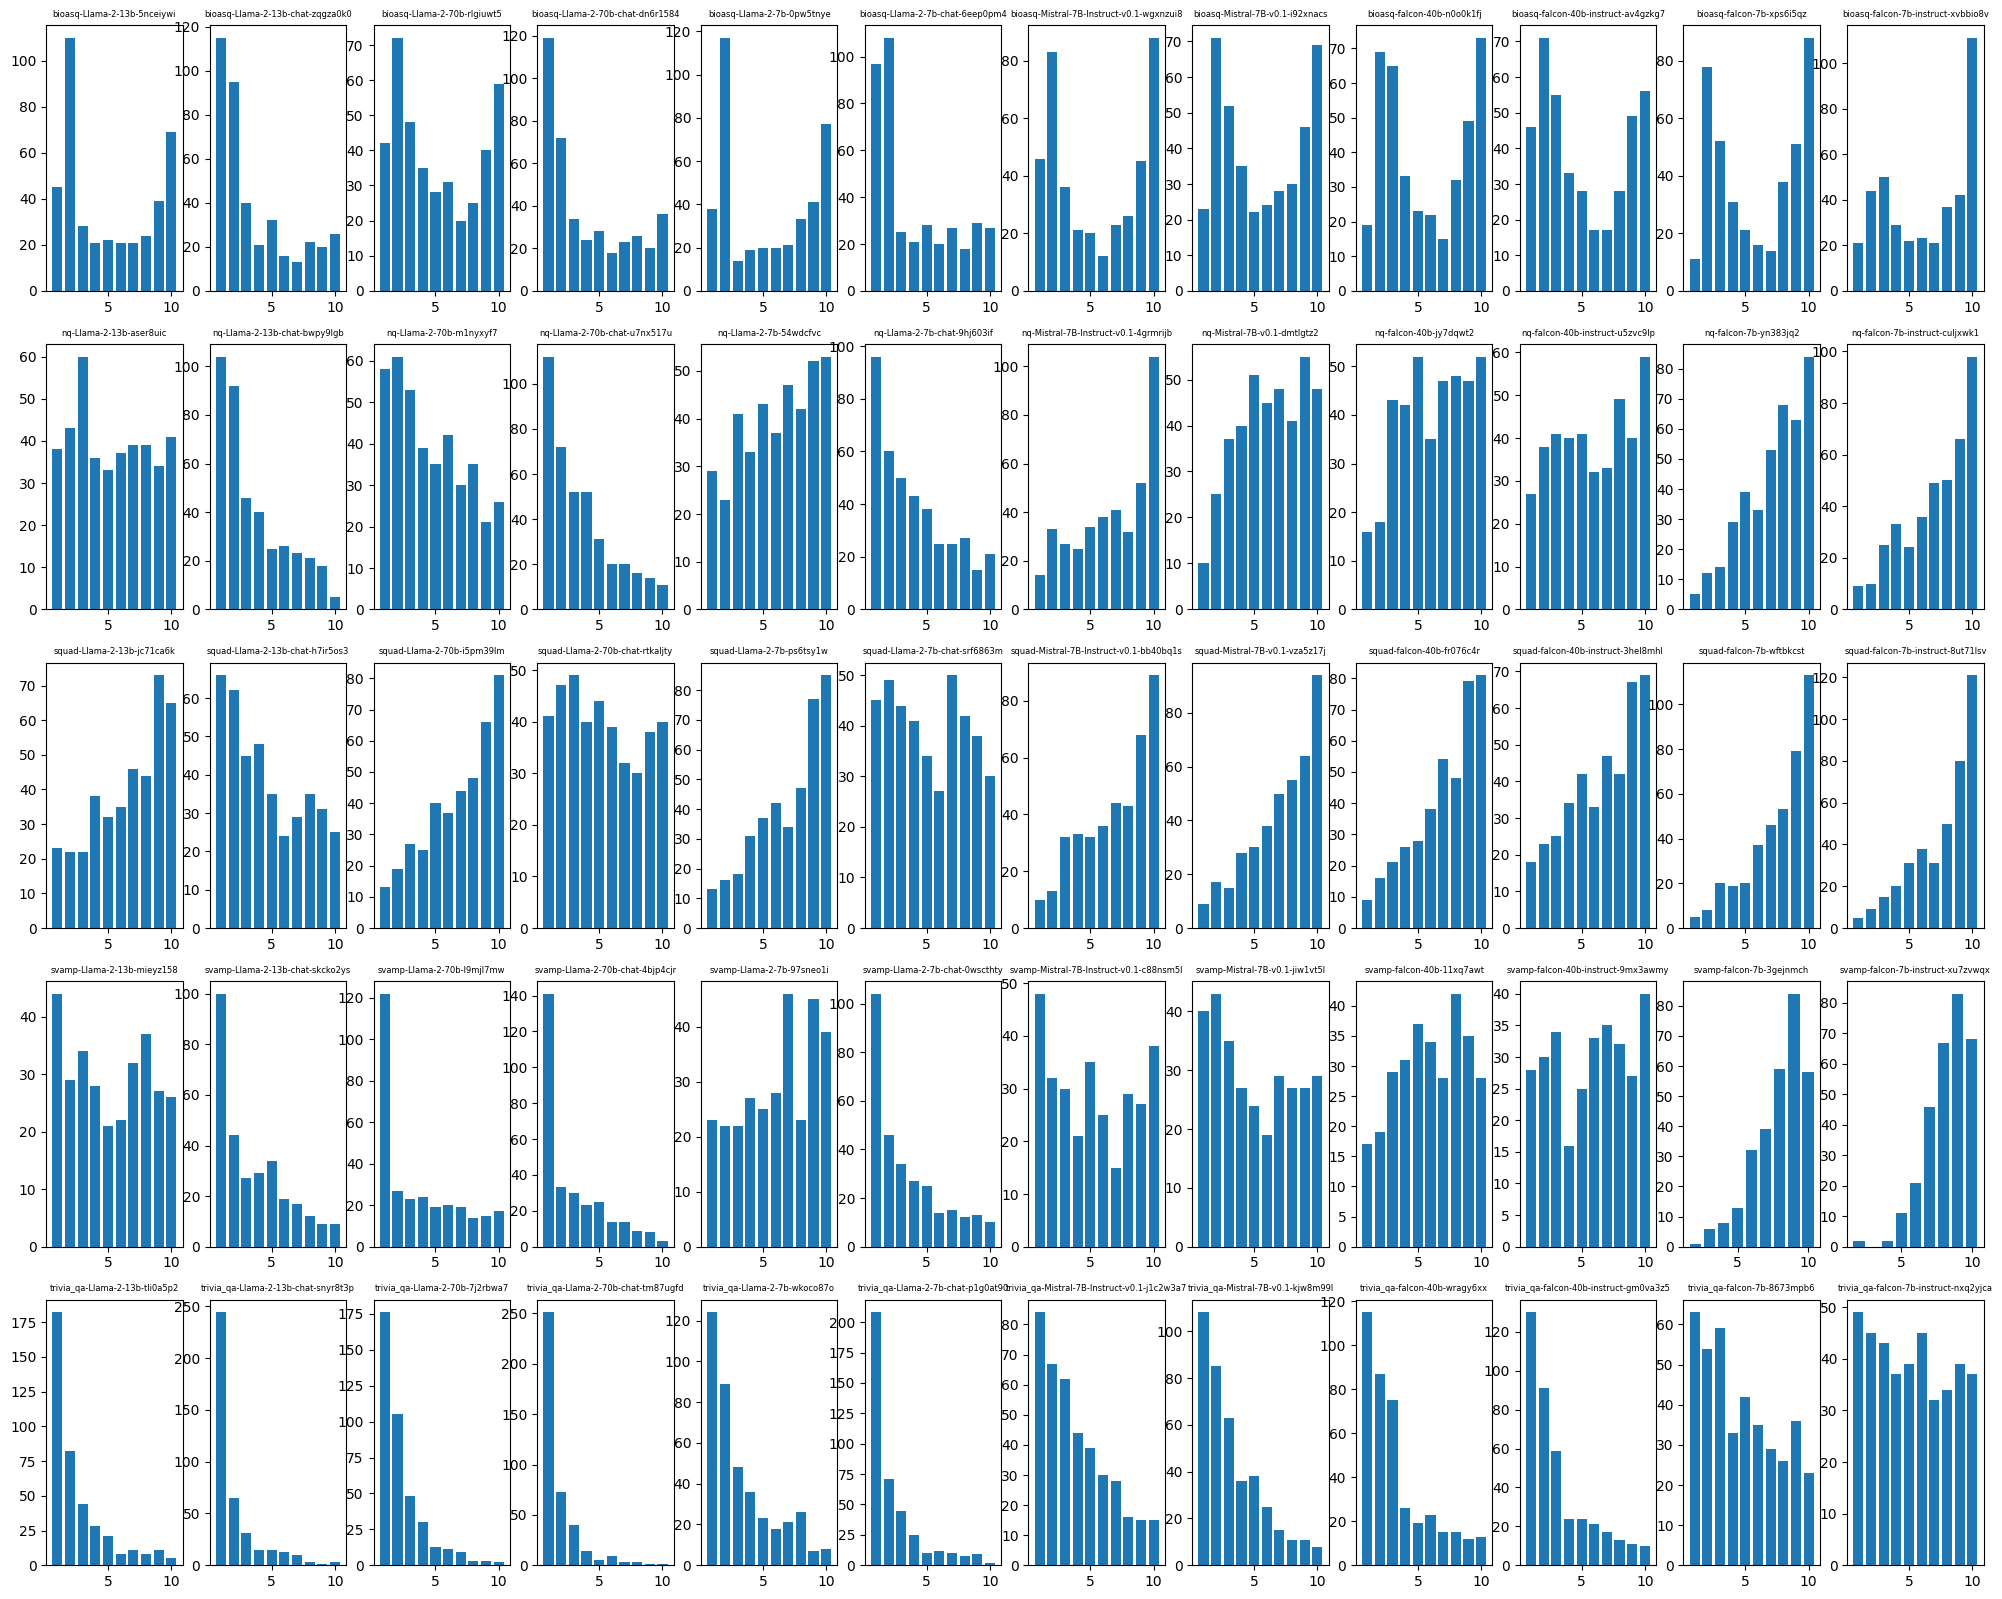

In [438]:
fig, axes_2d = plt.subplots(*standard_arg[['c.dataset', 'c.model_name']].nunique().values, figsize=(25, 20))

for axes, dataset in zip(axes_2d, sorted(standard_arg['c.dataset'].unique())):
    for ax, model in zip(axes, sorted(standard_arg['c.model_name'].unique())):
        wid = standard_arg.set_index('c.dataset').loc[dataset].set_index('c.model_name').loc[model]['wandbid']
        ax.set_title(f'{dataset}-{model}-{wid}', fontsize=6)
        uniq_counts, count_values = np.unique(num_ids[wid], return_counts=True)
        ax.bar(uniq_counts, count_values)
    
    


In [439]:
cdf = get_cluster_stats(num_ids)
cdf = cdf.merge(arg_df[['wandbid', 'c.dataset', 'c.model_name']], on='wandbid')

cdf

,wandbid,statistic,value,c.dataset,c.model_name
0,j1c2w3a7,mean,3.910000,trivia_qa,Mistral-7B-Instruct-v0.1
1,j1c2w3a7,sem,0.129215,trivia_qa,Mistral-7B-Instruct-v0.1
2,j1c2w3a7,std,2.581066,trivia_qa,Mistral-7B-Instruct-v0.1
3,j1c2w3a7,median,3.000000,trivia_qa,Mistral-7B-Instruct-v0.1
4,u5zvc9lp,mean,5.890000,nq,falcon-40b-instruct
...,...,...,...,...,...
235,8ut71lsv,median,9.000000,squad,falcon-7b-instruct
236,xps6i5qz,mean,5.972500,bioasq,falcon-7b
237,xps6i5qz,sem,0.161616,bioasq,falcon-7b
238,xps6i5qz,std,3.228273,bioasq,falcon-7b


In [440]:
# overall stats
stats(np.concatenate(list(num_ids.values())))

{'mean': 5.135131578947369,
 'sem': 0.020991812119630398,
 'std': 3.169624608392227,
 'median': 5.0}

**note that further aggregates are only valid for mean! i.e. mean of median/sem/std will be mean(metric) not overall metric!! i.e. mean(median) != median**

In [441]:
display(cdf.set_index('statistic').loc['mean'].groupby('c.model_name').mean('value'))

,value
c.model_name,
Llama-2-13b,4.977667
Llama-2-13b-chat,3.473833
Llama-2-70b,4.543333
Llama-2-70b-chat,3.497500
Llama-2-7b,5.582333
Llama-2-7b-chat,3.814167
Mistral-7B-Instruct-v0.1,5.696333
Mistral-7B-v0.1,5.495167
falcon-40b,5.643500


In [442]:
display(cdf.set_index('statistic').loc['mean'].groupby('c.dataset').mean('value'))

,value
c.dataset,
bioasq,5.154792
nq,5.557292
squad,6.577917
svamp,5.261667
trivia_qa,3.155625


In [443]:
# number of clusters
gdf = cdf.set_index('statistic').loc['mean']
display(gdf.pivot(index='c.dataset', columns='c.model_name', values='value')) 

c.model_name,Llama-2-13b,Llama-2-13b-chat,Llama-2-70b,Llama-2-70b-chat,Llama-2-7b,Llama-2-7b-chat,Mistral-7B-Instruct-v0.1,Mistral-7B-v0.1,falcon-40b,falcon-40b-instruct,falcon-7b,falcon-7b-instruct
c.dataset,,,,,,,,,,,,
bioasq,5.122500,3.680000,5.215000,4.0450,5.400000,3.990000,5.575000,5.637500,5.6575,5.177500,5.972500,6.3850
nq,5.340000,3.520000,4.652500,3.4975,6.075000,4.035000,6.775000,6.237500,6.1875,5.890000,7.255000,7.2225
squad,6.590000,4.620000,6.875000,5.2550,7.042500,5.247500,6.985000,7.210000,7.1475,6.602500,7.665000,7.6950
svamp,5.253333,3.516667,3.686667,2.9000,6.116667,3.443333,5.236667,5.083333,5.9400,5.736667,7.966667,8.2600
trivia_qa,2.582500,2.032500,2.287500,1.7900,3.277500,2.355000,3.910000,3.307500,3.2850,3.132500,4.662500,5.2450


Difference in number of clusters between base models and instruct models

In [444]:
instruct_num_ids = {k: v for k, v in num_ids.items() if 'chat' in arg_df.set_index('wandbid').loc[k]['c.model_name'] or 'instruct' in arg_df.set_index('wandbid').loc[k]['c.model_name'].lower()}
stats(np.concatenate(list(instruct_num_ids.values())))

{'mean': 4.788859649122807,
 'sem': 0.029802999283761674,
 'std': 3.1819499865874286,
 'median': 4.0}

In [445]:
base_num_ids = {k: v for k, v in num_ids.items() if not ('chat' in arg_df.set_index('wandbid').loc[k]['c.model_name'] or 'instruct' in arg_df.set_index('wandbid').loc[k]['c.model_name'].lower())}
stats(np.concatenate(list(base_num_ids.values())))

{'mean': 5.48140350877193,
 'sem': 0.029213790822193452,
 'std': 3.1190424973601374,
 'median': 5.0}

In [446]:
instruct_num_ids.keys() - base_num_ids.keys() == instruct_num_ids.keys(), base_num_ids.keys() - instruct_num_ids.keys() == base_num_ids.keys()

(True, True)

Base models generate a little bit more diversity but not much.

In [410]:
from constants import COLORS, TEXTWIDTH, GOLDEN_RATIO, METRIC_NAMES, MODEL_NAMES, PRETTY_NAMES
import matplotlib.patches as mpatches

In [500]:
# Full Figure 2 plot for the paper
# We want a massive grid of plots that include AUROC and AU RA C for each dataset (in rows) and model (in columns)

def full_sentence_plot(df, models_in_order=[], datasets_in_order=[], methods_in_order=[], metrics_in_order=[], ylim=None, save_path=None):
    tdf = df.copy()
    n_datasets = len(datasets_in_order)
    n_models = len(models_in_order)
    fig, axs = plt.subplots(n_datasets, n_models, figsize=(2.6*TEXTWIDTH, 2*TEXTWIDTH), sharex=True, sharey='row')
    for i, dataset in enumerate(datasets_in_order):
        axs[i,0].set_ylim(bottom=1.0, top=0.0)
        
        for j, model in enumerate(models_in_order):
            gdf = tdf[(tdf['c.dataset'] == dataset) & (tdf['c.model_name'] == model) & (tdf['metric'].isin(metrics_in_order)) & (tdf['method'].isin(methods_in_order))].copy()
            
            for original_name, new_name in METRIC_NAMES.items():
                gdf.loc[gdf['metric'] == original_name,'metric'] = new_name
            if len(gdf) == 0:
                print(f"Skipping {dataset} {model}")
                continue
            ax = axs[i,j]
            g = sns.barplot(
                    x="metric",       # x variable name
                    y="means",       # y variable name
                    hue="method",  # group variable name
                    data=gdf,     # dataframe to plot
                    ax=ax,
                    hue_order = methods_in_order,
                    palette = COLORS,
                    legend = False,
                    errorbar= None,
            )

            # Min value
            temp_min = np.nanmin(gdf['means'])
            temp_max = np.nanmax(gdf['means'])
            current_min, current_max = axs[i,0].get_ylim()
            if current_min > temp_min:
                axs[i,0].set_ylim(bottom=temp_min)
            if current_max < temp_max:
                axs[i,0].set_ylim(top=temp_max)


            # Crosshatch the p_ik_ood
            n_bars = len(methods_in_order) * len(metrics_in_order)
            idxs_to_edit = np.arange(n_bars-len(metrics_in_order), n_bars, 1)
            for bar_idx, bar in enumerate(g.patches):
                if bar_idx in idxs_to_edit:
                    bar.set_hatch('//')
                    bar.set_facecolor('white')
                    bar.set_edgecolor(COLORS['p_ik_ood'])
            sns.despine()
            if i == n_datasets - 1:
                ax.set_xlabel(MODEL_NAMES[model])
            if j == 0:
                ax.set_ylabel(PRETTY_NAMES[dataset])

            ax.set_axisbelow(True)
            ax.grid(axis='y', linestyle=':', linewidth=.5)
        if ylim == None:
            current_min, current_max = axs[i,0].get_ylim()
            current_min -= 0.05
            current_max += 0.05
            ax.set_ylim(bottom=max(current_min, 0), top=min(current_max, 1.0))
        else:
            ax.set_ylim(*ylim)
    
    patches = [mpatches.Patch(color=COLORS[method], label=PRETTY_NAMES[method]) for method in methods_in_order]
    for patch in patches:
        if patch.get_label() == "Embedding Regression - OOD":
            original_edgecolor = patch.get_edgecolor()
            patch.set_hatch('//')
            patch.set_facecolor('white')
            patch.set_edgecolor(original_edgecolor)
    axs[0,2].legend(handles=patches, loc='center', bbox_to_anchor=(1.1, 1.16), ncols=3, frameon=False)
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
    return True


In [460]:
from constants import MODEL_NAMES

True

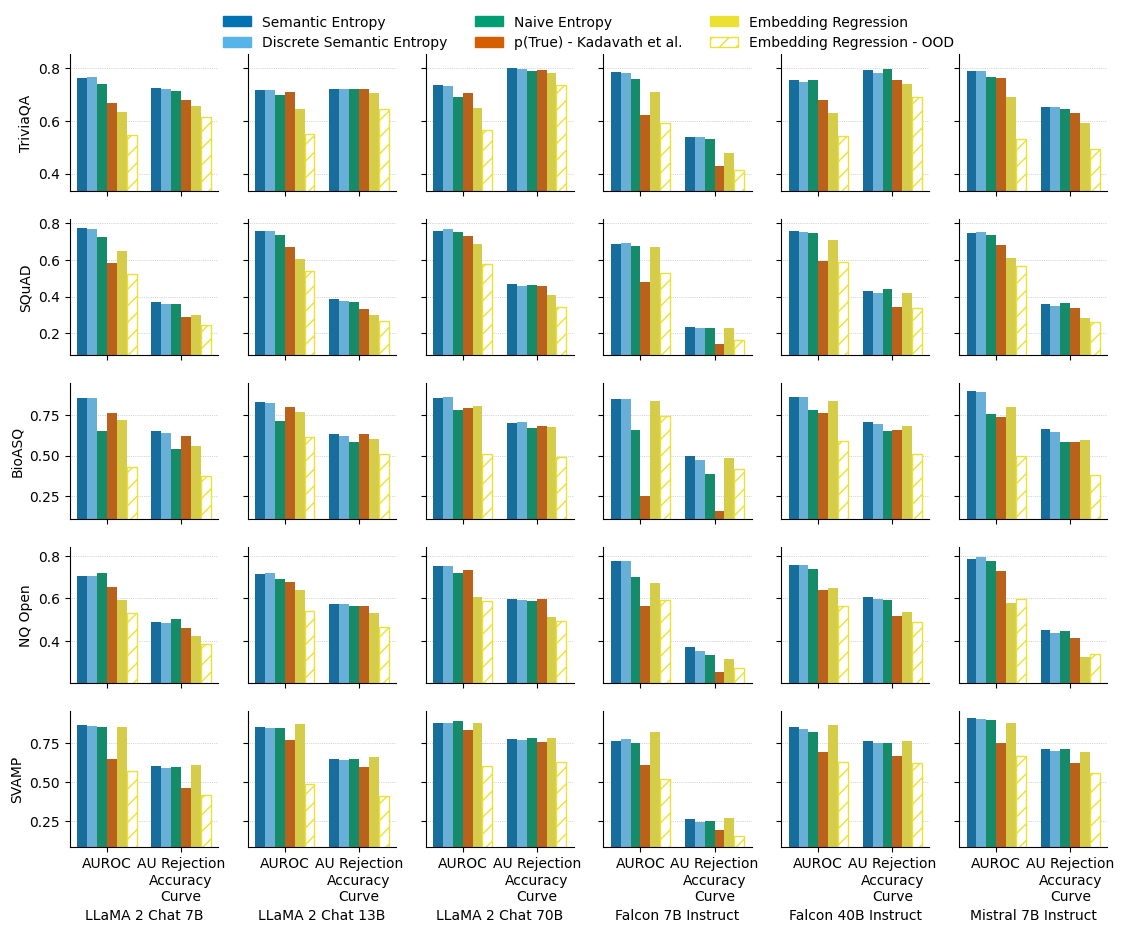

In [505]:
# UPDATE from JANNIK: fix bug with wrong average
all_relevant_runs = all_runs.set_index('c.entailment_model').loc['deberta'].reset_index().set_index('c.metric').loc['squad'].reset_index()

# UPDATE from JANNIK: add p_ik ood runs
# PLEASE NOTE: pik runs do not have entailment_model and metric and other configs! (because they are only an eval run!)
all_relevant_runs_with_pik = pd.concat([pik_all_runs, all_relevant_runs])


# Plot for short appendix
# WEIRD BUG FOR 13B
full_sentence_plot(all_relevant_runs_with_pik,
                   datasets_in_order=['trivia_qa', 'squad', 'bioasq', 'nq', 'svamp'],
                   models_in_order=['Llama-2-7b-chat', 'Llama-2-13b-chat', 'Llama-2-70b-chat','falcon-7b-instruct', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1'],
                   methods_in_order = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood'],
                   metrics_in_order=['AUROC', 'area_under_thresholded_accuracy'],
                   save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_short_main.pdf")

Comment from Jannik 02/12/23: how do you feel about not sharying ylims between rows? such that we can show differences between methods more clearly?


True

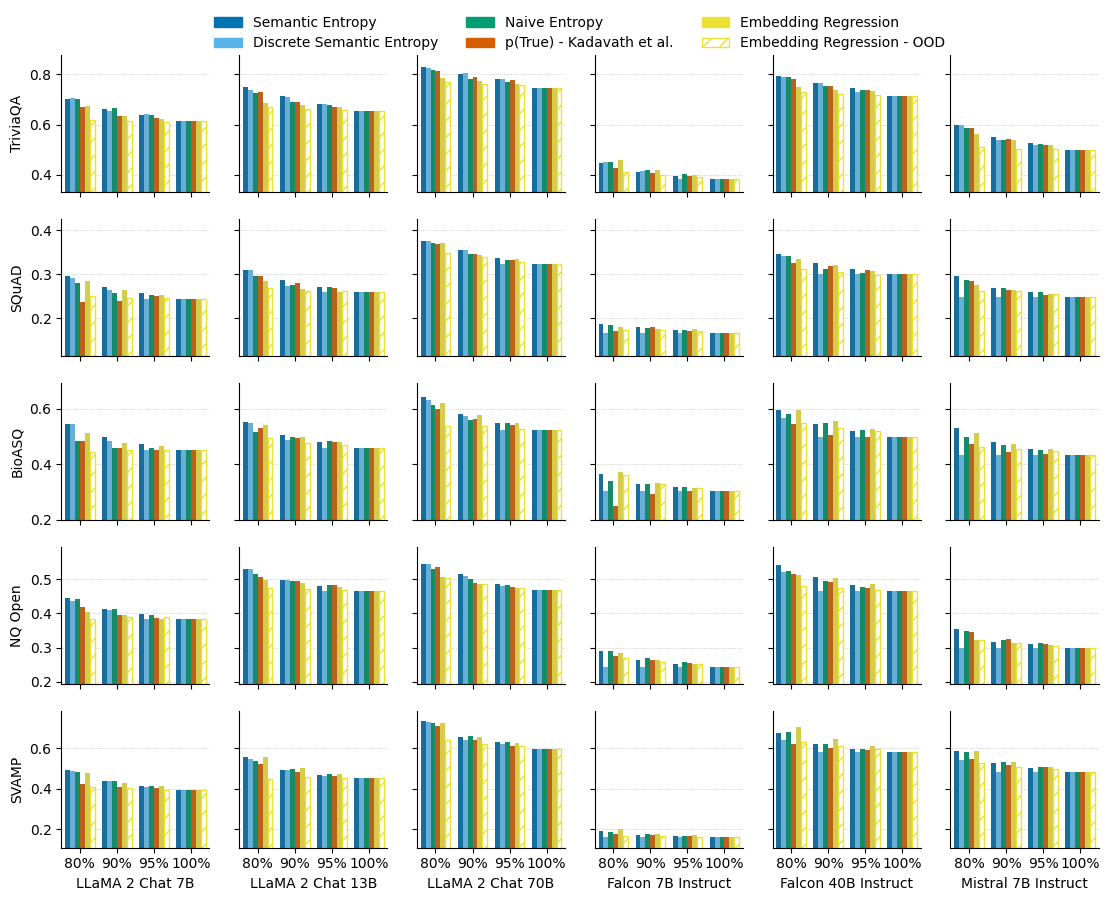

In [506]:
# Backup plot for appendix of all the rejection accuracies

print('Comment from Jannik 02/12/23: how do you feel about not sharying ylims between rows? such that we can show differences between methods more clearly?')

# Plot for Figure 4
full_sentence_plot(all_relevant_runs_with_pik,
                   datasets_in_order=['trivia_qa', 'squad', 'bioasq', 'nq', 'svamp'],
                   models_in_order=['Llama-2-7b-chat', 'Llama-2-13b-chat', 'Llama-2-70b-chat','falcon-7b-instruct', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1'],
                   methods_in_order = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood'],
                   metrics_in_order=['accuracy_at_0.8_answer_fraction', 'accuracy_at_0.9_answer_fraction', 'accuracy_at_0.95_answer_fraction', 'accuracy_at_1.0_answer_fraction'],
                   ylim=None,
                   save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_short_rejection_accuracy.pdf")

Comment from Jannik 02/12/23: how do you feel about not sharying ylims between rows? such that we can show differences between methods more clearly?


True

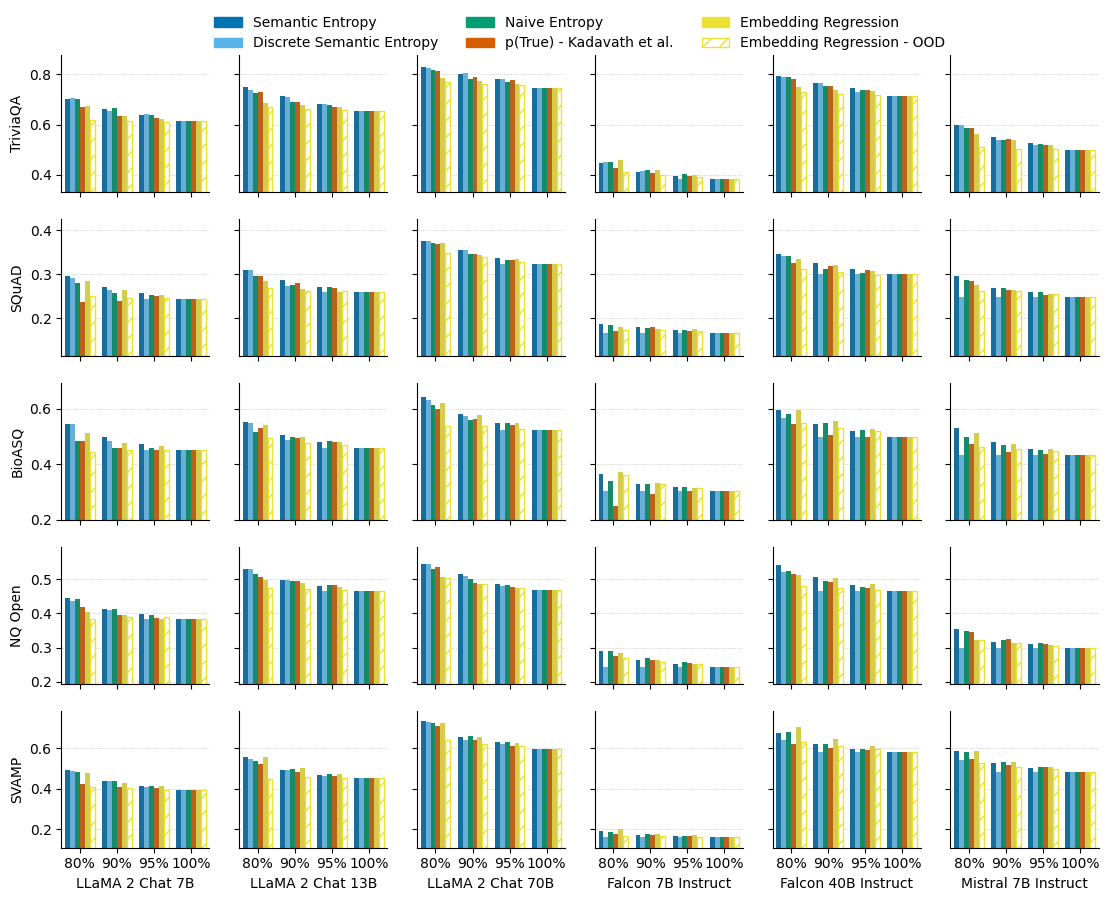

In [507]:
# Backup plot for appendix of all the rejection accuracies

print('Comment from Jannik 02/12/23: how do you feel about not sharying ylims between rows? such that we can show differences between methods more clearly?')

# Plot for Figure 4
full_sentence_plot(all_relevant_runs_with_pik,
                   datasets_in_order=['trivia_qa', 'squad', 'bioasq', 'nq', 'svamp'],
                   models_in_order=['Llama-2-7b-chat', 'Llama-2-13b-chat', 'Llama-2-70b-chat','falcon-7b-instruct', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1'],
                   methods_in_order = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood'],
                   metrics_in_order=['accuracy_at_0.8_answer_fraction', 'accuracy_at_0.9_answer_fraction', 'accuracy_at_0.95_answer_fraction', 'accuracy_at_1.0_answer_fraction'],
                   ylim=None,
                   save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_short_rejection_accuracy_non_it.pdf")

True

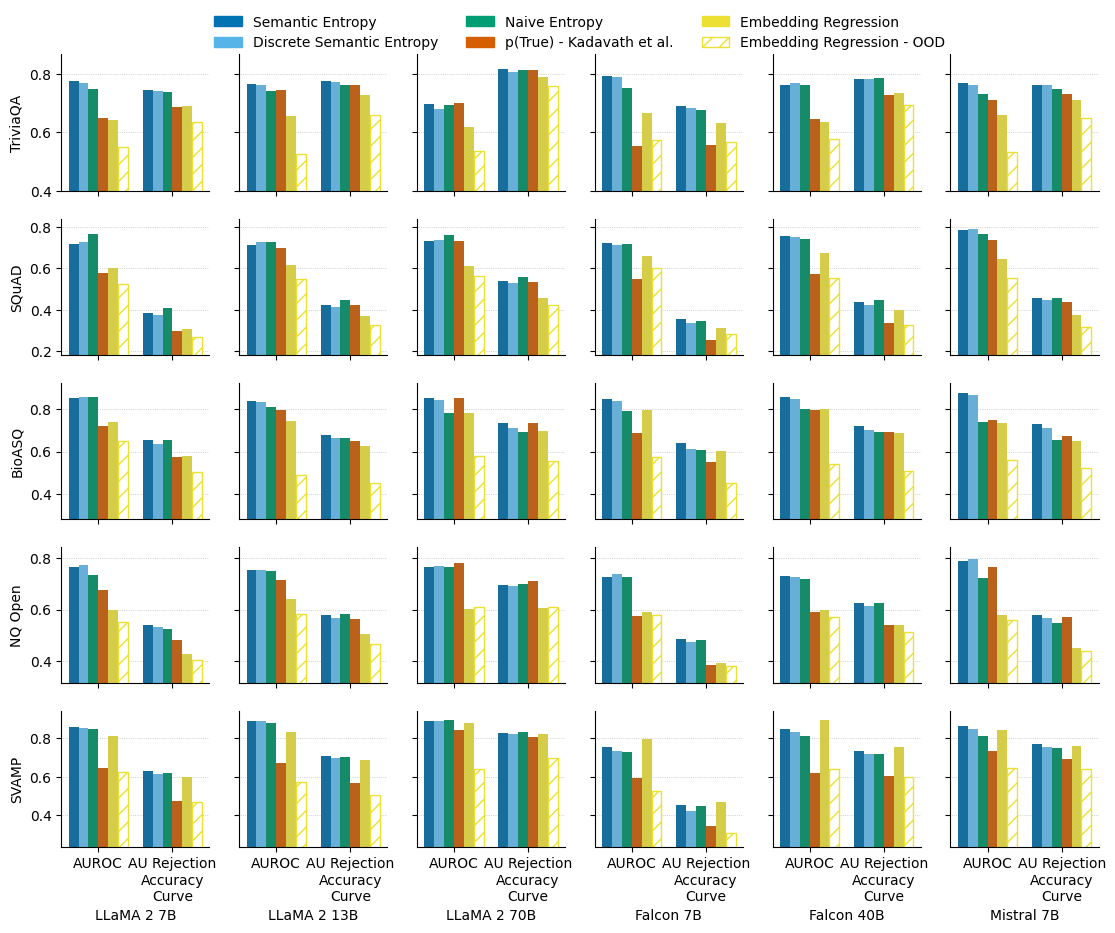

In [509]:
# Backup plot for appendix of all the rejection accuracies WITH NON IT MODELS

# Plot for Figure 4
full_sentence_plot(all_relevant_runs_with_pik,
                   datasets_in_order=['trivia_qa', 'squad', 'bioasq', 'nq', 'svamp'],
                   models_in_order=['Llama-2-7b', 'Llama-2-13b', 'Llama-2-70b','falcon-7b', 'falcon-40b', 'Mistral-7B-v0.1'],
                   methods_in_order = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood'],
                   metrics_in_order=['AUROC', 'area_under_thresholded_accuracy'],
                   ylim=None,
                   save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_short_main_non_it.pdf")

# Create run scripts for p_ik OOD eval

In [141]:
cmd = 'sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py '
cmd += '--eval_wandb_runid={eval} --train_wandb_runid={train} --no-compute_predictive_entropy --experiment_lot=231201_ptrue_ood_short'

In [225]:
# select runs with deberta-entailment and squad-f1 metric
standard_runs = arg_df.set_index('c.entailment_model').loc['deberta'].reset_index().set_index('c.metric').loc['squad'].reset_index()

In [227]:
for model, gdf in standard_runs.groupby('c.model_name'):
    print(f'# model: {model}')
    if model not in ['Llama-2-13b', 'Llama-2-13b-chat', 'falcon-7b', 'falcon-7b-instruct']:
        continue
    for ds1, gdf1 in gdf.groupby('c.dataset'):
        assert len(gdf1) == 1
        for ds2, gdf2 in gdf.groupby('c.dataset'):
            assert len(gdf2) == 1

            if ds1 == ds2:
                continue

            wandbid1 = gdf1['wandbid'].values[0]
            wandbid2 = gdf2['wandbid'].values[0]
            
            print(cmd.format(eval=wandbid1, train=wandbid2))

# model: Llama-2-13b
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=5nceiywi --train_wandb_runid=aser8uic --no-compute_predictive_entropy --experiment_lot=231201_ptrue_ood_short
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=5nceiywi --train_wandb_runid=jc71ca6k --no-compute_predictive_entropy --experiment_lot=231201_ptrue_ood_short
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=5nceiywi --train_wandb_runid=mieyz158 --no-compute_predictive_entropy --experiment_lot=231201_ptrue_ood_short
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=5nceiywi --train_wandb_runid=tli0a5p2 --no-compute_predictive_entropy --experiment_lot=231201

# Check on p_ik ood runs

In [231]:
import wandb

api = wandb.Api()
api_runs = api.runs('goatml/semantic_uncertainty')

configs = {}

for run in api_runs[:500]:
    finished = run.state == 'finished'
    lot = '231201_ptrue_ood_short' in run.description
    if lot and finished:
        configs[run.id] = run.config
        configs[run.id]['state'] = run.state
        configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]


In [232]:
args = ['state', 'slurmid', 'dataset', 'model_name', 'ood_training_set', 'train_wandb_runid', 'eval_wandb_runid']
# args = ['state', 'slurmid', 'dataset', 'train_wandb_runid', 'eval_wandb_runid']

tmp_arg_df, _, _ = get_arg_df(configs)

tmp_arg_df['c.model_name'] = tmp_arg_df['c.model_name'].map(lambda x: x if not x.endswith('-8bit') else x[:-len('-8bit')])

with pd.option_context('display.max_rows', None):
    tmp = tmp_arg_df
    display(tmp) #need display to show the dataframe when using with in jupyter



,wandbid,c.state,c.slurmid,c.dataset,c.model_name,c.ood_training_set,c.train_wandb_runid,c.eval_wandb_runid,UNIQ-c.dataset-c.model_name-c.ood_training_set-c.train_wandb_runid-c.eval_wandb_runid
0,zb8q0s0c,finished,173083,trivia_qa,falcon-7b,squad,wftbkcst,8673mpb6,trivia_qa-falcon-7b-squad-wftbkcst-8673mpb6
1,1qwcqm89,finished,173082,trivia_qa,falcon-7b,nq,yn383jq2,8673mpb6,trivia_qa-falcon-7b-nq-yn383jq2-8673mpb6
2,v3npioit,finished,173081,trivia_qa,falcon-7b,bioasq,xps6i5qz,8673mpb6,trivia_qa-falcon-7b-bioasq-xps6i5qz-8673mpb6
3,mqn6lmow,finished,173080,svamp,falcon-7b,trivia_qa,8673mpb6,3gejnmch,svamp-falcon-7b-trivia_qa-8673mpb6-3gejnmch
4,owrchir0,finished,173104,trivia_qa,falcon-7b-instruct,svamp,xu7zvwqx,nxq2yjca,trivia_qa-falcon-7b-instruct-svamp-xu7zvwqx-nx...
5,xuz9nq8x,finished,173103,trivia_qa,falcon-7b-instruct,squad,8ut71lsv,nxq2yjca,trivia_qa-falcon-7b-instruct-squad-8ut71lsv-nx...
6,zjpeorle,finished,173078,svamp,falcon-7b,nq,yn383jq2,3gejnmch,svamp-falcon-7b-nq-yn383jq2-3gejnmch
7,rbbmbltv,finished,173091,nq,falcon-7b-instruct,svamp,xu7zvwqx,culjxwk1,nq-falcon-7b-instruct-svamp-xu7zvwqx-culjxwk1
8,l09gir6p,finished,173102,trivia_qa,falcon-7b-instruct,nq,culjxwk1,nxq2yjca,trivia_qa-falcon-7b-instruct-nq-culjxwk1-nxq2yjca
9,gcwvd0dc,finished,173079,svamp,falcon-7b,squad,wftbkcst,3gejnmch,svamp-falcon-7b-squad-wftbkcst-3gejnmch


In [235]:
for name, gdf in tmp.groupby(['c.train_wandb_runid', 'c.eval_wandb_runid']):
    if len(gdf) > 1:
        print(name)
        display(gdf)

for model_name, gdf in tmp_arg_df.groupby('c.model_name'):

    print(model_name)
    display(gdf.pivot(index='c.dataset', columns='c.ood_training_set', values='wandbid'))

Llama-2-13b


c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,2trt38y1,gqczft8f,9gyd2dfy,460cju5m
nq,fa2eyiej,NaN,kusm2lyi,r9983wt9,g5svkp8m
squad,q0shaobf,61pl4mms,NaN,l28t9saq,8tik0iin
svamp,qqfan96l,uk9ybrid,g84aicza,NaN,zg7g48ls
trivia_qa,4zwjod47,7n8b8sve,lb3zh6gw,ttdoaecq,NaN


Llama-2-13b-chat


c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,m6zmm9kk,dpx5wbcn,l1wz3yxp,h05ct6vr
nq,o5qrab3i,NaN,wcdxfowp,la8e8b4r,sxcthhax
squad,rqqbh2ss,ah9x0o7t,NaN,4n73fv0z,xp95pvun
svamp,uvdx3ys5,ums2ntcu,fxzg4fk2,NaN,6pp8cozw
trivia_qa,ji5btg7g,x4ovchnl,q9dmcrp7,x8m438eg,NaN


Llama-2-70b


...

c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,h3czy7np,aivfva3n,cumoc0vv,e6mno259
nq,ocdpmx4z,NaN,l5gzq11e,zxm9p0qo,pdvb3n5s
squad,e63muwy4,0o7wmmkq,NaN,gej7tg1t,dns2yp69
svamp,2r8opy8u,ee7kgeuv,m7iuuyo5,NaN,d1khmq82
trivia_qa,y66z6luq,khwwihpx,zisdtzit,c2hjkv6e,NaN


falcon-7b


c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,uumqqy67,wyh7xixt,w7n1qvt4,qmcvz1jw
nq,8f8gns4l,NaN,o6jjozep,fixoh39l,ka5zb0wu
squad,i548jgor,5fcv3979,NaN,hxmct0fe,yynmhm18
svamp,wy5d6wea,zjpeorle,gcwvd0dc,NaN,mqn6lmow
trivia_qa,v3npioit,1qwcqm89,zb8q0s0c,l129move,NaN


falcon-7b-instruct


c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,esnc5e6f,zv6h0ouo,229zjxxc,radol9n5
nq,7378jty9,NaN,wuuz6tul,rbbmbltv,ryzg725a
squad,qqt9dw5y,tkeh0odg,NaN,lm9imw3o,46bpgku5
svamp,j9fc9xdf,xjvkxyqy,6w9gpgau,NaN,b0rvt1jh
trivia_qa,xeas4b1j,l09gir6p,xuz9nq8x,owrchir0,NaN


In [236]:
t = tmp_arg_df
{w: f'{m}-{d}-{o}' for w, m, d, o in zip(t['wandbid'], t['c.model_name'], t['c.dataset'], t['c.ood_training_set'])}

{'zb8q0s0c': 'falcon-7b-trivia_qa-squad',
 '1qwcqm89': 'falcon-7b-trivia_qa-nq',
 'v3npioit': 'falcon-7b-trivia_qa-bioasq',
 'mqn6lmow': 'falcon-7b-svamp-trivia_qa',
 'owrchir0': 'falcon-7b-instruct-trivia_qa-svamp',
 'xuz9nq8x': 'falcon-7b-instruct-trivia_qa-squad',
 'zjpeorle': 'falcon-7b-svamp-nq',
 'rbbmbltv': 'falcon-7b-instruct-nq-svamp',
 'l09gir6p': 'falcon-7b-instruct-trivia_qa-nq',
 'gcwvd0dc': 'falcon-7b-svamp-squad',
 'wuuz6tul': 'falcon-7b-instruct-nq-squad',
 'xeas4b1j': 'falcon-7b-instruct-trivia_qa-bioasq',
 'wy5d6wea': 'falcon-7b-svamp-bioasq',
 'radol9n5': 'falcon-7b-instruct-bioasq-trivia_qa',
 '6w9gpgau': 'falcon-7b-instruct-svamp-squad',
 'yynmhm18': 'falcon-7b-squad-trivia_qa',
 'ji5btg7g': 'Llama-2-13b-chat-trivia_qa-bioasq',
 'qqfan96l': 'Llama-2-13b-svamp-bioasq',
 '7378jty9': 'falcon-7b-instruct-nq-bioasq',
 'j9fc9xdf': 'falcon-7b-instruct-svamp-bioasq',
 '5fcv3979': 'falcon-7b-squad-nq',
 'fxzg4fk2': 'Llama-2-13b-chat-svamp-squad',
 '229zjxxc': 'falcon-7b-ins

# Recompute analysis with finegrained quantiles

In [477]:
cmd = 'sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py '
cmd += '--wandb_runids={eval} --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun2_rounded_short'

for wid in standard_runs:
    print(cmd.format(eval=wid))

sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=skcko2ys --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun2_rounded_short
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=bwpy9lgb --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun2_rounded_short
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=h7ir5os3 --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun2_rounded_short
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=snyr8t3p --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun2_rounded_short
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=zqgza0k0 -

In [478]:

cmd = 'sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py '
cmd += '--wandb_runids={eval} --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun_rounded2_ood_short'

for wid in pik_runs:
    print(cmd.format(eval=wid))

sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=zb8q0s0c --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun_rounded2_ood_short
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=1qwcqm89 --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun_rounded2_ood_short
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=v3npioit --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun_rounded2_ood_short
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=mqn6lmow --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun_rounded2_ood_short
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_r

# Check out state of quantile recompute runs

In [489]:
import wandb

api = wandb.Api(timeout=100)
api_runs = api.runs('goatml/semantic_uncertainty')


In [495]:
configs = {}
for run in api_runs[:300]:
    finished = run.state == 'finished'
    lot = run.description.endswith('finegrained_rerun2_rounded_short')
    if lot and finished:
        configs[run.id] = run.config
        configs[run.id]['state'] = run.state
        configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]
        configs[run.id]['eval_wid'] = run.metadata['args'][0].split('=')[1]
configs

{'7v9829hs': {'state': 'finished',
  'slurmid': '174107',
  'eval_wid': 'dn6r1584'},
 'p612l1sb': {'state': 'finished',
  'slurmid': '174106',
  'eval_wid': 'rlgiuwt5'},
 'l73gru9d': {'state': 'finished',
  'slurmid': '174105',
  'eval_wid': '6eep0pm4'},
 '1qxx1kdc': {'state': 'finished',
  'slurmid': '174103',
  'eval_wid': 'srf6863m'},
 'lpiqolkq': {'state': 'finished',
  'slurmid': '174104',
  'eval_wid': 'p1g0at90'},
 'c49kowku': {'state': 'finished',
  'slurmid': '174101',
  'eval_wid': '7j2rbwa7'},
 '2y5iz0yp': {'state': 'finished',
  'slurmid': '174100',
  'eval_wid': '0pw5tnye'},
 'qulmpm7j': {'state': 'finished',
  'slurmid': '174102',
  'eval_wid': 'tm87ugfd'},
 't8wh24jt': {'state': 'finished',
  'slurmid': '174087',
  'eval_wid': 'vza5z17j'},
 'gw7whx93': {'state': 'finished',
  'slurmid': '174099',
  'eval_wid': 'rtkaljty'},
 'm2c7th22': {'state': 'finished',
  'slurmid': '174084',
  'eval_wid': 'c88nsm5l'},
 'olwzg5bi': {'state': 'finished',
  'slurmid': '174076',
  'eval

In [496]:
wid2name = {wid: name for wid, name in zip(arg_df['wandbid'], arg_df['UNIQ-c.dataset-c.model_name-c.metric-c.entailment_model'])}
new_runs = {wid: wid2name[configs[wid]['eval_wid']] for wid in configs}
# {'7v9829hs': 'bioasq-Llama-2-70b-chat-squad-deberta',
#  'p612l1sb': 'bioasq-Llama-2-70b-squad-deberta',
#  'l73gru9d': 'bioasq-Llama-2-7b-chat-squad-deberta',
#  '1qxx1kdc': 'squad-Llama-2-7b-chat-squad-deberta',
#  'lpiqolkq': 'trivia_qa-Llama-2-7b-chat-squad-deberta',
#  'c49kowku': 'trivia_qa-Llama-2-70b-squad-deberta'}
new_runs


{'7v9829hs': 'bioasq-Llama-2-70b-chat-squad-deberta',
 'p612l1sb': 'bioasq-Llama-2-70b-squad-deberta',
 'l73gru9d': 'bioasq-Llama-2-7b-chat-squad-deberta',
 '1qxx1kdc': 'squad-Llama-2-7b-chat-squad-deberta',
 'lpiqolkq': 'trivia_qa-Llama-2-7b-chat-squad-deberta',
 'c49kowku': 'trivia_qa-Llama-2-70b-squad-deberta',
 '2y5iz0yp': 'bioasq-Llama-2-7b-squad-deberta',
 'qulmpm7j': 'trivia_qa-Llama-2-70b-chat-squad-deberta',
 't8wh24jt': 'squad-Mistral-7B-v0.1-squad-deberta',
 'gw7whx93': 'squad-Llama-2-70b-chat-squad-deberta',
 'm2c7th22': 'svamp-Mistral-7B-Instruct-v0.1-squad-deberta',
 'olwzg5bi': 'svamp-falcon-40b-instruct-squad-deberta',
 'acpjfjji': 'nq-Llama-2-13b-squad-deberta',
 '0r03r4ax': 'svamp-Llama-2-70b-chat-8bit-squad-deberta',
 'azwidv4c': 'squad-Llama-2-70b-squad-deberta',
 'fkihims9': 'squad-falcon-40b-squad-deberta',
 'wyzh61ot': 'nq-falcon-40b-squad-deberta',
 'kpkiwbpq': 'squad-falcon-7b-squad-deberta',
 '05e0el64': 'nq-Llama-2-7b-8bit-squad-deberta',
 'fhfig18t': 'nq-fal

In [497]:
configs = {}
for run in api_runs[:300]:
    finished = run.state == 'finished'
    lot = run.description.endswith('finegrained_rerun_rounded2_ood_short')
    if lot and finished:
        configs[run.id] = run.config
        configs[run.id]['state'] = run.state
        configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]
        configs[run.id]['eval_wid'] = run.metadata['args'][0].split('=')[1]


In [499]:
len(new_runs), len(pik_runs)

(240, 240)

In [498]:
new_runs = {wid: pik_runs[configs[wid]['eval_wid']] for wid in configs}
new_runs

{'jf5mfwkz': 'Llama-2-70b-nq-squad',
 'oypdffl9': 'Llama-2-70b-svamp-trivia_qa',
 'yeo8gc3l': 'Llama-2-70b-chat-trivia_qa-svamp',
 'b0j1gyan': 'falcon-7b-instruct-svamp-nq',
 '5gdqt75x': 'Llama-2-70b-chat-squad-trivia_qa',
 '1reyoj48': 'Llama-2-70b-chat-svamp-bioasq',
 'roff79kp': 'Llama-2-70b-chat-svamp-trivia_qa',
 'knbvoixa': 'Llama-2-70b-chat-nq-trivia_qa',
 'ahwi4qce': 'Llama-2-13b-chat-squad-trivia_qa',
 '69yqpwvw': 'Llama-2-70b-bioasq-svamp',
 'yf46od88': 'Llama-2-70b-bioasq-squad',
 '8bcn1ybb': 'Llama-2-70b-chat-svamp-nq',
 '0p9wzdru': 'Llama-2-7b-chat-squad-bioasq',
 '4x00tbhr': 'Llama-2-70b-bioasq-nq',
 'yqlq7bmt': 'Llama-2-7b-bioasq-svamp',
 'mrylukvv': 'Llama-2-70b-nq-bioasq',
 '9ucpokq9': 'Mistral-7B-Instruct-v0.1-trivia_qa-bioasq',
 'jbwyqs3x': 'Llama-2-7b-bioasq-trivia_qa',
 '11a0atlr': 'Mistral-7B-Instruct-v0.1-svamp-bioasq',
 'eq8artri': 'Llama-2-13b-chat-squad-bioasq',
 'vmp9j9cw': 'Llama-2-70b-squad-trivia_qa',
 'nxa5wpex': 'Mistral-7B-v0.1-nq-bioasq',
 't1zima2o': '